## Segmentation and Classification


In [3]:
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#file paths
qptiff_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-0149-FIXT-01-IF1-01_#_bbd13dc7affec5fc3da9af1f6fb6d041.qptiff"
tsv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-0149-FIXT-01-IF1-01_#_cells_properties2_#_711e7cff23368f2d17837af40907d8d6.tsv.gz"
tsv_path2 ="/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF3/tsv/IMMU-BC1-0149-FIXT-01-IF3-01_#_cells_properties_#_3aa432eb9e33c821a4941157b41d23eb.tsv.gz"
qptiff_path2 = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF3/qptiff/IMMU-BC1-0149-FIXT-02-IF3-01_#_d5a3aa4feeed11acc975f95bb83c7508.qptiff"
qptiff_path3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.qptiff"
tsv_path3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype_updated/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz"

## Reading and Plotting TSV File BC1 IF1 149

   cell.ID  nucleus.x  nucleus.y  cell.area  TLS.ID
0       94     7910.4    55897.6      437.2     NaN
1       96     7984.8    55828.7      648.6     NaN
2      100     7953.1    56387.8      618.8     NaN
3      102     7954.6    55920.5      393.5     NaN
4      103     7963.0    56273.2      630.3     NaN
Index(['cell.ID', 'nucleus.x', 'nucleus.y', 'cell.area', 'TLS.ID'], dtype='object')
(35183, 5)
max: cell.ID      37075.0
nucleus.x    18944.2
nucleus.y    57330.6
cell.area      680.0
TLS.ID           2.0
dtype: float64
min cell.ID      18749.538897
nucleus.x    14638.737149
nucleus.y    54369.751511
cell.area      258.698499
TLS.ID           1.623288
dtype: float64


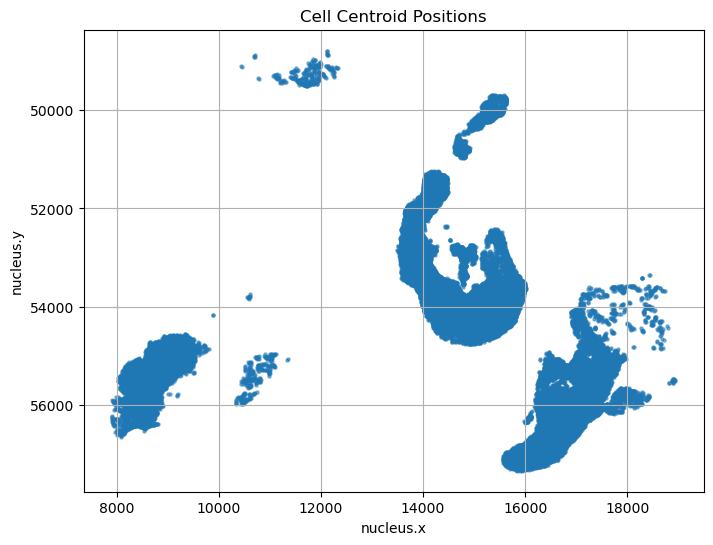

In [3]:
#Reading the tv file
df = pd.read_csv(tsv_path, sep="\t",compression='gzip')
print(df.head())
print(df.columns)
print(df.shape)
print("max:",df.max())
print("min",df.mean())

# Visualize cell positions using nucleus.x and nucleus.y
if 'nucleus.x' in df.columns and 'nucleus.y' in df.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df['nucleus.x'], df['nucleus.y'], s=5, alpha=0.5)
    plt.title("Cell Centroid Positions")
    plt.xlabel("nucleus.x")
    plt.ylabel("nucleus.y")
    plt.gca().invert_yaxis()  # Invert Y-axis to match image coordinates
    plt.grid(True)
    plt.show()


## Reading and Plotting TSV File BC1 IF3 149

   cell.ID  nucleus.x  nucleus.y  CD4.score   CK.score  FOXP3.score  \
0       33     9512.0    55216.8  20.474736   8.834579     2.436392   
1       34     9740.7    55086.8  17.222731   5.758353     2.088987   
2       35     9958.5    55219.3  21.189290   6.162959     1.402172   
3       36     9540.7    55123.0   6.059426   6.840149     2.320282   
4       37     9713.4    55233.2   7.956005  23.251307     5.649647   

   CD56.score  CD8.score  CD3.score  CD4.score.normalized  \
0    1.124018        0.0   1.991018                1.5934   
1    0.664837        0.0   1.500715                1.3403   
2    0.649933        0.0   1.507176                1.6490   
3    0.358289        0.0   1.468857                0.4716   
4    0.972082        0.0   7.251193                0.6191   

   CK.score.normalized  FOXP3.score.normalized  CD56.score.normalized  \
0               1.7669                  0.1180                 0.4478   
1               1.1517                  0.1012              

/tmp/ipykernel_9291/2313288997.py:7: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  print("min",df.mean())


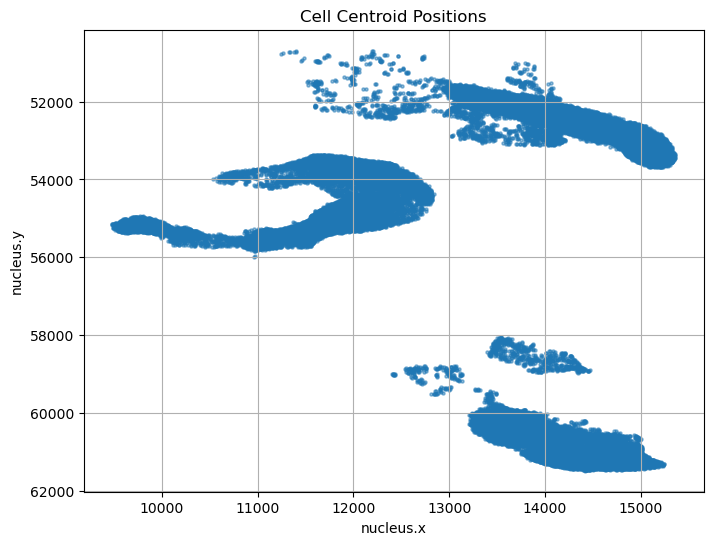

In [4]:
#Reading the tv file
df = pd.read_csv(tsv_path2, sep="\t",compression='gzip')
print(df.head())
print(df.columns)
print(df.shape)
print("max:",df.max())
print("min",df.mean())

# Visualize cell positions using nucleus.x and nucleus.y
if 'nucleus.x' in df.columns and 'nucleus.y' in df.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df['nucleus.x'], df['nucleus.y'], s=5, alpha=0.5)
    plt.title("Cell Centroid Positions")
    plt.xlabel("nucleus.x")
    plt.ylabel("nucleus.y")
    plt.gca().invert_yaxis()  # Invert Y-axis to match image coordinates
    plt.grid(True)
    plt.show()


In [5]:
df['phenotype'].value_counts()


CD4-CK+FOXP3-CD56-CD8-CD3-    18927
CD4+CK+FOXP3-CD56-CD8-CD3-     8772
CD4-CK-FOXP3-CD56-CD8-CD3-     1803
CD4+CK-FOXP3-CD56-CD8-CD3-      995
CD4-CK+FOXP3-CD56+CD8-CD3-      527
CD4+CK+FOXP3-CD56+CD8-CD3-      436
CD4-CK+FOXP3-CD56-CD8-CD3+      388
CD4+CK+FOXP3-CD56-CD8-CD3+      313
CD4+CK-FOXP3-CD56-CD8-CD3+       94
CD4-CK+FOXP3+CD56-CD8-CD3-       29
CD4+CK+FOXP3-CD56+CD8-CD3+       17
CD4-CK-FOXP3+CD56-CD8-CD3-       17
CD4-CK-FOXP3-CD56-CD8-CD3+       13
CD4-CK-FOXP3-CD56+CD8-CD3-       12
CD4-CK+FOXP3-CD56+CD8-CD3+       11
CD4+CK-FOXP3-CD56+CD8-CD3-        9
CD4+CK+FOXP3+CD56-CD8-CD3-        5
CD4+CK-FOXP3+CD56-CD8-CD3-        1
CD4-CK-FOXP3-CD56+CD8-CD3+        1
Name: phenotype, dtype: int64

In [ ]:
#Reading the tv file
df = pd.read_csv(tsv_path3, sep="\t",compression='gzip')
print(df.head())
print(df.columns)
print(df.shape)
print("max:",df.max())
print("min",df.mean())

# Visualize cell positions using nucleus.x and nucleus.y
if 'nucleus.x' in df.columns and 'nucleus.y' in df.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df['nucleus.x'], df['nucleus.y'], s=5, alpha=0.5)
    plt.title("Cell Centroid Positions")
    plt.xlabel("nucleus.x")
    plt.ylabel("nucleus.y")
    plt.gca().invert_yaxis()  # Invert Y-axis to match image coordinates
    plt.grid(True)
    plt.show()


   cell.ID  nucleus.x  nucleus.y  CD15.score  CK.score  CD3.score  \
0       29     7384.2    35592.2    0.539248  0.552555   4.641662   
1       30     7451.2    35336.1    0.353247  2.370034   3.194412   
2       31     7753.8    35234.9    3.872318  1.262634   2.450958   
3       32     7504.7    35511.8    0.891661  0.468967   2.158099   
4       33     7628.8    35738.5    0.378430  0.394962   3.288753   

   CD11c.score  CD20.score  CD163.score  CD15.score.normalized  ...  \
0     0.219289    0.145625     1.320323                 0.1257  ...   
1     0.286839    0.408582     1.256250                 0.0823  ...   
2     1.230235    0.259747    79.320935                 0.9026  ...   
3     0.508292    0.204084     2.232118                 0.2078  ...   
4     0.196775    0.161664     0.886713                 0.0882  ...   

   CD3.score.normalized  CD11c.score.normalized  CD20.score.normalized  \
0                0.7310                  0.0877                 0.0725   
1         

## Displaying all the channels from QPTIFF BC1 IF1 149

In [ ]:
import tifffile
import matplotlib.pyplot as plt



# Loading the QPTIFF file
with tifffile.TiffFile(qptiff_path) as tif:
    for channel_index in range(len(tif.pages)):
        image = tif.pages[channel_index].asarray()

        # Show the image
        plt.figure(figsize=(8, 6))
        plt.imshow(image, cmap='gray')
        plt.title(f"Intensity Image - Channel {channel_index}")
        plt.colorbar(label='Pixel Intensity')
        plt.axis('off')
        plt.show()

        # Print image size
        print(f"Image shape for channel {channel_index}: {image.shape}")

In [7]:
#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path3) as tif:
    print(len(tif.pages))
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    rgb = tif.pages[8].asarray(out='memmap')[::1,::1]
    #plt.imshow(image,cmap='gray')
    #plt.axis('off')
    #plt.show()
    print("image shape:",image.shape)
    print("image shape:",rgb.shape)

51
image shape: (51840, 46080)
image shape: (405, 360, 3)


## Displaying BC1 IF1 Qptiff DAPI

51


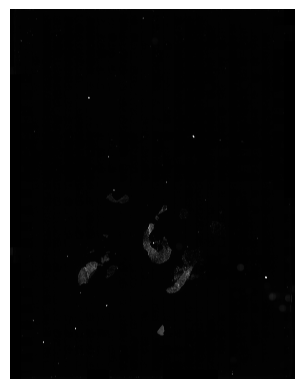

image shape: (64800, 49920)


In [6]:
#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path) as tif:
    print(len(tif.pages))
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    plt.imshow(image,cmap='gray')
    plt.axis('off')
    plt.show()
    print("image shape:",image.shape)
    

51


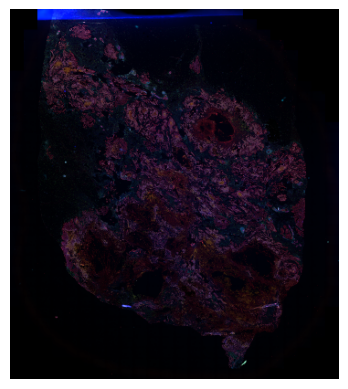

image shape: (405, 360, 3)


In [6]:
#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path3) as tif:
    print(len(tif.pages))
    image = tif.pages[8].asarray(out='memmap')[::1,::1]
    plt.imshow(image,cmap='gray')
    plt.axis('off')
    plt.show()
    print("image shape:",image.shape)
    

51


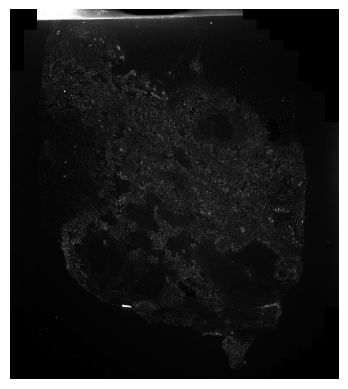

image shape: (51840, 46080)


In [7]:
#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path3) as tif:
    print(len(tif.pages))
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    plt.imshow(image,cmap='gray')
    plt.axis('off')
    plt.show()
    print("image shape:",image.shape)
    

## Converting and Displaying Qptiff to multi channel tiff BC1 IF1 149 

In [ ]:
import tifffile
import numpy as np


# Indices of the 8 marker channels 
marker_indices = [0, 1, 2, 3, 4, 5, 6, 7]  # DAPI, Opal dyes, Sample AF

# Load and normalize selected marker channels
selected_images = []
with tifffile.TiffFile(qptiff_path) as tif:
    for idx in marker_indices:
        page = tif.pages[idx]
        img = page.asarray().astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min()) * 255  # Normalize
        img = img.astype(np.uint8)
        selected_images.append(img)

# Stack into a multi-channel array (C, H, W)
multi_channel_array = np.stack(selected_images, axis=0)

# Save as multi-channel TIFF
output_path = "multi_channel_markers_BC1_IF1_149.tiff"
tifffile.imwrite(output_path, multi_channel_array, photometric='minisblack', bigtiff=True)

print(f"Saved multi-channel TIFF with {len(marker_indices)} channels to {output_path}")


Saved multi-channel TIFF with 8 channels to multi_channel_markers_BC1_IF1_149.tiff


: 

In [ ]:
import tifffile
import matplotlib.pyplot as plt

# Loading the multi-channel TIFF
tiff_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/multi_channel_markers_BC1_IF1_149.tiff"
with tifffile.TiffFile(tiff_path) as tif:
    image = tif.asarray()  # shape: (C, H, W)

# Display each channel
num_channels = image.shape[0]
fig, axes = plt.subplots(1, num_channels, figsize=(4 * num_channels, 4))

for i in range(num_channels):
    ax = axes[i]
    ax.imshow(image[i], cmap='gray')
    ax.set_title(f"Channel {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Displaying BC1 IF3 Qptiff DAPI

51


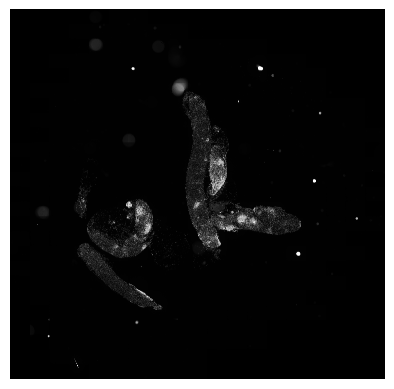

image shape: (36000, 36480)


In [10]:
#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path2) as tif:
    print(len(tif.pages))
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    plt.imshow(image,cmap='gray')
    plt.axis('off')
    plt.show()
    print("image shape:",image.shape)
    

## Converting Qptiff to Multi channel Tiff BC1 IF3 149

In [11]:
import tifffile
import numpy as np


# Indices of the 8 marker channels 
marker_indices = [0, 1, 2, 3, 4, 5, 6, 7]  # DAPI, Opal dyes, Sample AF

# Load and normalize selected marker channels
selected_images = []
with tifffile.TiffFile(qptiff_path2) as tif:
    for idx in marker_indices:
        page = tif.pages[idx]
        img = page.asarray().astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min()) * 255  # Normalize
        img = img.astype(np.uint8)
        selected_images.append(img)

# Stack into a multi-channel array (C, H, W)
multi_channel_array = np.stack(selected_images, axis=0)

# Save as multi-channel TIFF
output_path = "multi_channel_markers_BC1_IF3_149.tiff"
tifffile.imwrite(output_path, multi_channel_array, photometric='minisblack', bigtiff=True)

print(f"Saved multi-channel TIFF with {len(marker_indices)} channels to {output_path}")


Saved multi-channel TIFF with 8 channels to multi_channel_markers_BC1_IF3_149.tiff


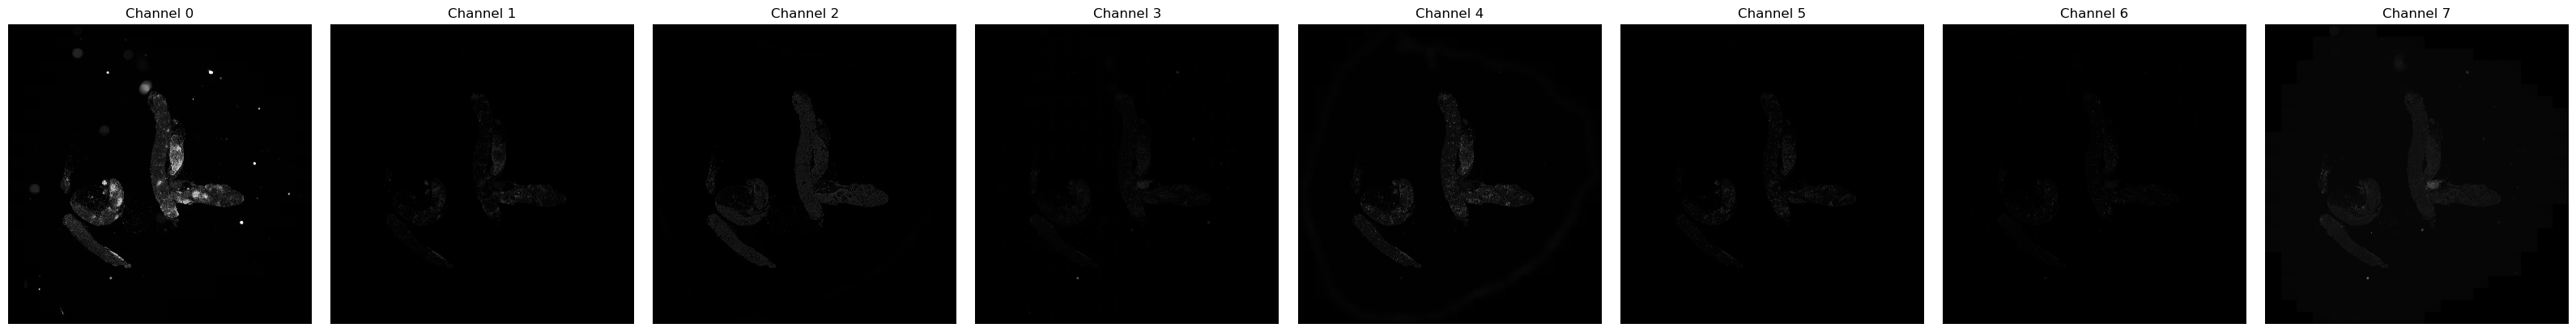

In [ ]:
import tifffile
import matplotlib.pyplot as plt

# Loading the multi-channel TIFF
tiff_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/multi_channel_markers_BC1_IF3_149.tiff"
with tifffile.TiffFile(tiff_path) as tif:
    image = tif.asarray()  # shape: (C, H, W)

# Display each channel
num_channels = image.shape[0]
fig, axes = plt.subplots(1, num_channels, figsize=(4 * num_channels, 4))

for i in range(num_channels):
    ax = axes[i]
    ax.imshow(image[i], cmap='gray')
    ax.set_title(f"Channel {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Using Cellpose to extract the segmentation and compare to the TSV File 
### So I am thinking to write a for loop to iterate for each  cell ,get the cell coordination and cell area and then goes to that location in each page of the qptiff from 0 to 8 and then make the sum of all the pixels in that cells and then devide by the number of the pixels to get the pixel level intensity of each cell for each page

In [13]:
imagearray = tifffile.imread(qptiff_path, key=0)

imagearray

imagearray.shape

(64800, 49920)

## Reading all the pages from QPTIFF and save them as a numpy array

In [14]:
img = []
for i in range(8):
    imagearray = tifffile.imread(qptiff_path, key =i)
    img.append(imagearray)
    print("Numpy Array for QpTiff images, Page Number:",i)
    print(img)
    print("Max:",img[i].max())
    print("Min:",img[i].min())
    print("Mean",img[i].mean())
    print("image shape",img[i].shape)

Numpy Array for QpTiff images, Page Number: 0
[array([[1, 1, 1, ..., 0, 0, 0],
       [2, 0, 1, ..., 0, 0, 0],
       [2, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 2, 3, 2],
       [0, 0, 0, ..., 1, 2, 3],
       [0, 0, 0, ..., 4, 1, 1]], dtype=uint8)]
Max: 255
Min: 0
Mean 2.577729785248991
image shape (64800, 49920)
Numpy Array for QpTiff images, Page Number: 1
[array([[1, 1, 1, ..., 0, 0, 0],
       [2, 0, 1, ..., 0, 0, 0],
       [2, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 2, 3, 2],
       [0, 0, 0, ..., 1, 2, 3],
       [0, 0, 0, ..., 4, 1, 1]], dtype=uint8), array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 1, 0, 0]], dtype=uint8)]
Max: 255
Min: 0
Mean 0.40994551467533236
image shape (64800, 49920)
Numpy Array for QpTiff images, Page Number: 2
[array([[1, 1, 1, ..., 0, 0, 0],
       [2, 0, 1, ..., 0, 0, 0],
    

## Extracting the Intensities

In [ ]:
import numpy as np
import pandas as pd
import math
import tifffile
class Extracting_Intensities:
    def __init__(self,qptiff_path,tsv_path):
        self.cx = 0
        self.cy = 0
        self.r = 0
        self.L = 0
        self.sum_pixels = 0
        self.count = 0
        self.mean_intensity = 0
        self.area = 0
        self.imc = 0
        self.imagearray = 0
        self.qptiff_path = qptiff_path
        self.tsv_path = tsv_path
        self.de = []
        self.img = []
        self.marker_names = []
    # Extracting each pixel values from each channel of the QPTIFF file and save them in a list of numpy arrays called img
    def extracting_pixel_values(self): 

        
    # Reading the tsv file and getting the coordinates of each cell and its radius    
    def getting_coordinations(self):
        self.df = pd.read_csv(self.tsv_path, sep="\t",compression='gzip') 
        self.marker_names = ['DAPI', 'CD15', 'CK', 'CD3', 'CD11c', 'CD20', 'CD163', 'AF']
        
       # Add new columns for each marker
        for marker in self.marker_names:
            self.df[marker + '_mean'] = np.nan

        self.L = self.df.shape[0]
        for i in range (self.L):
            self.cx = int(self.df['nucleus.x'][i])
            self.cy = int(self.df['nucleus.y'][i])
            self.area = int(self.df['cell.area'][i])
            self.r = int(math.sqrt(self.area / np.pi))
        return self.cx,self.cy,self.r    
    
       
    def calculate_intensities(self): 
        for i in range(8):
            self.imc = self.img[i]
            self.sum_pixels = 0 
            self.count = 0
            # Loop over a square region around the circle
            for x in range(self.cx - self.r, self.cx + self.r + 1):
                for y in range(self.cy - self.r, self.cy + self.r + 1):
                # Check if (x, y) is inside the circle and within image bounds
                    if (math.sqrt((x - self.cx)**2 + (y - self.cy)**2)) <= self.r:
                        if 0 <= x < self.imc.shape[1] and 0 <= y < self.imc.shape[0]:
                            self.sum_pixels += self.imc[y, x]  # image[y, x] because rows = y, cols = x
                            self.count += 1
                            self.mean_intensity = self.sum_pixels / self.count
                            self.df.at[i, self.marker_names[i] + '_mean'] = self.mean_intensity
        
        
    # Saving the updated TSV
    def save_updated_tsv(self, output_path):
        self.df.to_csv(output_path, sep='\t', index=False)
        print(self.df.head())               
   
                    
        return self.df

        

In [23]:
qptiff_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-0149-FIXT-01-IF1-01_#_bbd13dc7affec5fc3da9af1f6fb6d041.qptiff"
tsv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-0149-FIXT-01-IF1-01_#_cells_properties2_#_711e7cff23368f2d17837af40907d8d6.tsv.gz"
extractor = Extracting_Intensities(qptiff_path, tsv_path)
extractor.extracting_pixel_values()
extractor.getting_coordinations()
extractor.calculate_intensities()
extractor.save_updated_tsv("/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/intensities/tsv_cells_with_intensities.tsv")


   cell.ID  nucleus.x  nucleus.y  cell.area  TLS.ID  DAPI_mean  CD15_mean  \
0       94     7910.4    55897.6      437.2     NaN   2.222812        NaN   
1       96     7984.8    55828.7      648.6     NaN        NaN   0.429708   
2      100     7953.1    56387.8      618.8     NaN        NaN        NaN   
3      102     7954.6    55920.5      393.5     NaN        NaN        NaN   
4      103     7963.0    56273.2      630.3     NaN        NaN        NaN   

    CK_mean  CD3_mean  CD11c_mean  CD20_mean  CD163_mean  AF_mean  
0       NaN       NaN         NaN        NaN         NaN      NaN  
1       NaN       NaN         NaN        NaN         NaN      NaN  
2  0.506631       NaN         NaN        NaN         NaN      NaN  
3       NaN   3.02122         NaN        NaN         NaN      NaN  
4       NaN       NaN    1.103448        NaN         NaN      NaN  


,cell.ID,nucleus.x,nucleus.y,cell.area,TLS.ID,DAPI_mean,CD15_mean,CK_mean,CD3_mean,CD11c_mean,CD20_mean,CD163_mean,AF_mean
0,94,7910.4,55897.6,437.2,NaN,2.222812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,96,7984.8,55828.7,648.6,NaN,NaN,0.429708,NaN,NaN,NaN,NaN,NaN,NaN
2,100,7953.1,56387.8,618.8,NaN,NaN,NaN,0.506631,NaN,NaN,NaN,NaN,NaN
3,102,7954.6,55920.5,393.5,NaN,NaN,NaN,NaN,3.02122,NaN,NaN,NaN,NaN
4,103,7963.0,56273.2,630.3,NaN,NaN,NaN,NaN,NaN,1.103448,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35178,37071,18809.7,55540.4,444.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35179,37072,18885.6,55496.7,449.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35180,37073,18867.3,55504.2,504.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35181,37074,18944.2,55503.2,567.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
import numpy as np
import pandas as pd
import math
import tifffile

class Extracting_Intensities:
    def __init__(self, qptiff_path, tsv_path):
        self.qptiff_path = qptiff_path
        self.tsv_path = tsv_path
        self.img = []
        # Make sure this order matches the 8 pages in your QPTIFF
        self.marker_names = ['DAPI', 'CD15', 'CK', 'CD163', 'CD11c', 'CD20', 'CD3', 'AF']

    # Load the first 8 pages (highest resolution channels)
    def extracting_pixel_values(self):
        self.img = [tifffile.imread(self.qptiff_path, key=i) for i in range(8)]
        self.H, self.W = self.img[0].shape
        print(f"Loaded {len(self.img)} channels, image size: {self.H}x{self.W}")

    # Read TSV and prepare columns
    def getting_coordinations(self):
        self.df = pd.read_csv(self.tsv_path, sep="\t", compression='gzip')
        for marker in self.marker_names:
            self.df[marker + '_mean'] = np.nan
        print(f"Loaded {len(self.df)} cells from TSV")

    # Compute mean intensity for each cell and each channel
    def calculate_intensities(self):
        H, W = self.H, self.W
        for j in range(len(self.df)):
            cx = int(self.df.at[j, 'nucleus.x'])
            cy = int(self.df.at[j, 'nucleus.y'])
            area = float(self.df.at[j, 'cell.area'])
            r = int(max(1, round(math.sqrt(max(area, 1e-6) / math.pi))))

            # Skip if center is out of bounds
            if not (0 <= cx < W and 0 <= cy < H):
                continue

            # Define bounding box
            x_min = max(0, cx - r); x_max = min(W - 1, cx + r)
            y_min = max(0, cy - r); y_max = min(H - 1, cy + r)

            # Create circular mask
            xs = np.arange(x_min, x_max + 1)
            ys = np.arange(y_min, y_max + 1)
            xx, yy = np.meshgrid(xs, ys)
            mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r * r

            # Loop over channels
            for c, marker in enumerate(self.marker_names):
                tile = self.img[c][y_min:y_max + 1, x_min:x_max + 1]
                vals = tile[mask]
                if vals.size > 0:
                    self.df.at[j, f'{marker}_mean'] = float(vals.mean())

    # Save updated TSV
    def save_updated_tsv(self, output_path):
        self.df.to_csv(output_path, sep='\t', index=False)
        print(f"Saved updated TSV to {output_path}")
        print(self.df.head())
        return self.df






In [ ]:
qptiff_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-0149-FIXT-01-IF1-01_#_bbd13dc7affec5fc3da9af1f6fb6d041.qptiff"
tsv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-0149-FIXT-01-IF1-01_#_cells_properties2_#_711e7cff23368f2d17837af40907d8d6.tsv.gz"
output_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/intensities/tsv_cells_with_intensities.tsv"

extractor = Extracting_Intensities(qptiff_path, tsv_path)
extractor.extracting_pixel_values()
extractor.getting_coordinations()
extractor.calculate_intensities()
extractor.save_updated_tsv(output_path)

Loaded 8 channels, image size: 64800x49920
Loaded 35183 cells from TSV
Saved updated TSV to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/intensities/tsv_cells_with_intensities.tsv
   cell.ID  nucleus.x  nucleus.y  cell.area  TLS.ID  DAPI_mean  CD15_mean  \
0       94     7910.4    55897.6      437.2     NaN   2.070295   0.063492   
1       96     7984.8    55828.7      648.6     NaN   2.148450   0.063622   
2      100     7953.1    56387.8      618.8     NaN   1.969005   0.045677   
3      102     7954.6    55920.5      393.5     NaN   2.042440   0.031830   
4      103     7963.0    56273.2      630.3     NaN   1.967374   0.071778   

    CK_mean  CD163_mean  CD11c_mean  CD20_mean  CD3_mean   AF_mean  
0  0.113379    2.816327    0.993197   1.258503  0.671202  6.444444  
1  0.141925    2.957586    0.991843   1.239804  0.714519  6.641109  
2  0.076672    2.921697    0.931485   1.225122  0.458401  6.522023  
3  0.092838    2.798408    1.013263   1.209549  0.625995  6.39257

,cell.ID,nucleus.x,nucleus.y,cell.area,TLS.ID,DAPI_mean,CD15_mean,CK_mean,CD163_mean,CD11c_mean,CD20_mean,CD3_mean,AF_mean
0,94,7910.4,55897.6,437.2,NaN,2.070295,0.063492,0.113379,2.816327,0.993197,1.258503,0.671202,6.444444
1,96,7984.8,55828.7,648.6,NaN,2.148450,0.063622,0.141925,2.957586,0.991843,1.239804,0.714519,6.641109
2,100,7953.1,56387.8,618.8,NaN,1.969005,0.045677,0.076672,2.921697,0.931485,1.225122,0.458401,6.522023
3,102,7954.6,55920.5,393.5,NaN,2.042440,0.031830,0.092838,2.798408,1.013263,1.209549,0.625995,6.392573
4,103,7963.0,56273.2,630.3,NaN,1.967374,0.071778,0.101142,2.885808,0.893964,1.200653,0.500816,6.592170
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35178,37071,18809.7,55540.4,444.4,NaN,2.197279,0.215420,0.433107,2.984127,1.061224,1.108844,0.809524,6.843537
35179,37072,18885.6,55496.7,449.6,NaN,2.253968,0.278912,0.451247,3.004535,1.029478,1.136054,0.818594,6.972789
35180,37073,18867.3,55504.2,504.9,NaN,2.293006,0.179584,0.419660,3.024575,1.068053,1.134216,0.814745,7.022684
35181,37074,18944.2,55503.2,567.1,NaN,2.300567,0.221172,0.338374,3.079395,1.062382,1.179584,0.871456,6.960302


In [36]:
import numpy as np
import pandas as pd

# ---------------------------
# Utilities
# ---------------------------

def robust_zscore(x):
    """log1p transform, then robust z-score using median and MAD."""
    x = np.asarray(x, dtype=float)
    x_log = np.log1p(np.clip(x, a_min=0, a_max=None))
    med = np.nanmedian(x_log)
    mad = np.nanmedian(np.abs(x_log - med))
    # avoid division by 0
    scale = mad if mad > 1e-9 else (np.nanstd(x_log) if np.nanstd(x_log) > 1e-9 else 1.0)
    return (x_log - med) / scale, {'median_log': med, 'mad_log': mad, 'scale_used': scale}

def af_regress_out(y, af):
    """
    Simple linear regression y ~ a*af + b (OLS). Returns y_corrected = y - a*(af - median_af).
    Works at the vector level (per marker across all cells).
    """
    y = np.asarray(y, dtype=float)
    af = np.asarray(af, dtype=float)
    msk = np.isfinite(y) & np.isfinite(af)
    if msk.sum() < 20:
        return y, {'slope': np.nan, 'intercept': np.nan}
    A = np.vstack([af[msk], np.ones(msk.sum())]).T
    a, b = np.linalg.lstsq(A, y[msk], rcond=None)[0]
    af_med = np.nanmedian(af[msk])
    y_corr = y.copy()
    y_corr[msk] = y[msk] - a * (af[msk] - af_med)
    return y_corr, {'slope': float(a), 'intercept': float(b), 'af_median': float(af_med)}

def gmm_1d_em(x, max_iter=200, tol=1e-6, seed=0):
    """
    Two-component Gaussian Mixture in 1D with EM, returning params and posteriors.
    x should be 1D (e.g., normalized intensities for one marker).
    Returns:
      dict with means (mu0, mu1), stds (sigma0, sigma1), weights (w0, w1), posteriors (n x 2), and component order.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 50:
        # Too few points; return trivial split
        m = np.nanmean(x) if x.size else 0.0
        s = np.nanstd(x) if x.size else 1.0
        return {
            'mu0': m - 0.5*s, 'mu1': m + 0.5*s,
            'sigma0': max(s, 1e-3), 'sigma1': max(s, 1e-3),
            'w0': 0.5, 'w1': 0.5, 'post': None, 'order': (0,1)
        }

    # Init with quantiles
    q25, q75 = np.percentile(x, [25, 75])
    mu0, mu1 = q25, q75
    sigma0 = np.std(x[x <= mu0]) or np.std(x)/2 or 1.0
    sigma1 = np.std(x[x >= mu1]) or np.std(x)/2 or 1.0
    w0 = w1 = 0.5

    prev_ll = -np.inf
    for _ in range(max_iter):
        # E-step: responsibilities
        p0 = w0 * (1 / (np.sqrt(2*np.pi)*sigma0)) * np.exp(-0.5 * ((x - mu0)/sigma0)**2)
        p1 = w1 * (1 / (np.sqrt(2*np.pi)*sigma1)) * np.exp(-0.5 * ((x - mu1)/sigma1)**2)
        denom = p0 + p1 + 1e-12
        r0 = p0 / denom
        r1 = p1 / denom

        # M-step
        w0 = r0.mean()
        w1 = 1 - w0
        mu0 = (r0 * x).sum() / (r0.sum() + 1e-12)
        mu1 = (r1 * x).sum() / (r1.sum() + 1e-12)
        sigma0 = np.sqrt((r0 * (x - mu0)**2).sum() / (r0.sum() + 1e-12))
        sigma1 = np.sqrt((r1 * (x - mu1)**2).sum() / (r1.sum() + 1e-12))
        # avoid zeros
        sigma0 = float(max(sigma0, 1e-3))
        sigma1 = float(max(sigma1, 1e-3))
        w0 = float(np.clip(w0, 1e-4, 1-1e-4))
        w1 = float(1 - w0)

        # Log-likelihood
        ll = np.sum(np.log(denom))
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

    # Ensure comp1 is the "positive" (higher mean) component
    if mu0 <= mu1:
        order = (0,1)
    else:
        # swap
        mu0, mu1 = mu1, mu0
        sigma0, sigma1 = sigma1, sigma0
        w0, w1 = w1, w0
        r0, r1 = r1, r0
        order = (1,0)

    post = np.vstack([r0, r1]).T  # (n, 2)
    return {
        'mu0': float(mu0), 'mu1': float(mu1),
        'sigma0': float(sigma0), 'sigma1': float(sigma1),
        'w0': float(w0), 'w1': float(w1),
        'post': post, 'order': order
    }

def call_positive_from_post(post, p_thresh=0.5):
    """Return boolean calls (True = positive) from posterior of positive component."""
    # post is (n, 2) with [:,1] = prob(positive) by our convention
    return (post[:, 1] >= p_thresh)

# ---------------------------
# Main normalization/calling
# ---------------------------

def normalize_and_call(
    tsv_path_in: str,
    tsv_path_out: str,
    markers=('DAPI','CD15','CK','CD3','CD11c','CD20','CD163'),
    af_col='AF_mean',
    do_af_correction=True,
    p_thresh=0.5
):
    df = pd.read_csv(tsv_path_in, sep='\t')
    af = df[af_col].values if af_col in df.columns else None

    report = {}

    for m in markers:
        col = f'{m}_mean'
        if col not in df.columns:
            print(f"[WARN] Missing column: {col}. Skipping.")
            continue

        x = df[col].values

        # 1) Optional AF correction
        if do_af_correction and af is not None:
            x_corr, info_af = af_regress_out(x, af)
            df[f'{m}_afcorr'] = x_corr
            report[f'{m}_af_regression'] = info_af
            x_used = x_corr
        else:
            x_used = x.copy()

        # 2) Robust normalization
        z, info_norm = robust_zscore(x_used)
        df[f'{m}_norm'] = z
        report[f'{m}_norm'] = info_norm

        # 3) GMM for probability of positivity
        # Use only finite z values for model; keep index to reinsert NaNs
        msk = np.isfinite(z)
        model = gmm_1d_em(z[msk], seed=42)
        post = np.full((len(z), 2), np.nan)
        post[msk] = model['post']

        df[f'{m}_p_pos'] = post[:, 1]  # posterior prob of positive (high) component
        df[f'{m}_call'] = df[f'{m}_p_pos'] >= p_thresh

        # Save a short summary
        report[f'{m}_gmm'] = {
            'mu0': model['mu0'], 'mu1': model['mu1'],
            'sigma0': model['sigma0'], 'sigma1': model['sigma1'],
            'w0': model['w0'], 'w1': model['w1'],
            'positive_component_mean': model['mu1'],
            'p_thresh': p_thresh,
            'n': int(msk.sum()),
            'pos_frac@thr': float(np.nanmean(df[f'{m}_call']))
        }

    # 4) How many proteins per cell (excluding DAPI)
    pos_cols = [f'{m}_call' for m in markers if m != 'DAPI' and f'{m}_call' in df.columns]
    if pos_cols:
        df['n_markers_pos'] = df[pos_cols].sum(axis=1)

    # Save
    df.to_csv(tsv_path_out, sep='\t', index=False)

    # Print a compact QC summary
    print("Saved:", tsv_path_out)
    for m in markers:
        k1, k2, k3 = f'{m}_norm', f'{m}_p_pos', f'{m}_call'
        if k1 in df.columns:
            finite = np.isfinite(df[k1]).sum()
            pos_rate = float(df[k3].mean()) if k3 in df.columns else np.nan
            print(f"{m}: n finite={finite}, pos_rate={pos_rate:.3f}")
            if f'{m}_gmm' in report:
                g = report[f'{m}_gmm']
                print(f"  GMM: mu0={g['mu0']:.2f}, mu1={g['mu1']:.2f}, w1={g['w1']:.2f}, pos_frac={g['pos_frac@thr']:.2f}")

    return df, report




In [37]:
# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":
    in_tsv  = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/intensities/tsv_cells_with_intensities.tsv"
    out_tsv = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/intensities/tsv_cells_with_intensities_norm_calls.tsv"

    df_out, rpt = normalize_and_call(
        tsv_path_in=in_tsv,
        tsv_path_out=out_tsv,
        markers=('DAPI','CD15','CK','CD3','CD11c','CD20','CD163'),  # IF1 panel
        af_col='AF_mean',
        do_af_correction=True,   # set False if you want raw normalization without AF correction
        p_thresh=0.5             # try 0.7–0.8 for stricter positivity
    )

    # Quick look
    print(df_out.head(3)[[
        'cell.ID','nucleus.x','nucleus.y',
        'CK_mean','CK_afcorr','CK_norm','CK_p_pos','CK_call',
        'CD3_mean','CD3_afcorr','CD3_norm','CD3_p_pos','CD3_call',
        'n_markers_pos'
    ]].to_string(index=False))


Saved: /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/intensities/tsv_cells_with_intensities_norm_calls.tsv
DAPI: n finite=35183, pos_rate=0.999
  GMM: mu0=-0.26, mu1=0.06, w1=0.59, pos_frac=1.00
CD15: n finite=35183, pos_rate=0.173
  GMM: mu0=-0.23, mu1=2.40, w1=0.25, pos_frac=0.17
CK: n finite=35183, pos_rate=0.291
  GMM: mu0=-0.45, mu1=4.10, w1=0.32, pos_frac=0.29
CD3: n finite=35183, pos_rate=0.297
  GMM: mu0=-0.54, mu1=1.20, w1=0.25, pos_frac=0.30
CD11c: n finite=35183, pos_rate=0.349
  GMM: mu0=-0.44, mu1=1.04, w1=0.49, pos_frac=0.35
CD20: n finite=35183, pos_rate=0.571
  GMM: mu0=-0.85, mu1=0.78, w1=0.65, pos_frac=0.57
CD163: n finite=35183, pos_rate=0.228
  GMM: mu0=-0.31, mu1=0.74, w1=0.41, pos_frac=0.23
 cell.ID  nucleus.x  nucleus.y  CK_mean  CK_afcorr   CK_norm  CK_p_pos  CK_call  CD3_mean  CD3_afcorr  CD3_norm    CD3_p_pos  CD3_call  n_markers_pos
      94     7910.4    55897.6 0.113379   0.170267  1.068814  0.271718    False  0.671202    0.756098  0.358474 2

# Classification XGBOOST

## DataSet Handeling 

In [5]:
from pathlib import Path
import pandas as pd

# Directory and output path
directory = Path("/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF1")
output_path = directory / "combined_BC1_IF1.tsv.gz"

# Required columns
required_columns = [
    'cell.ID', 'nucleus.x', 'nucleus.y', 'CD4.score', 'CK.score',
    'FOXP3.score', 'CD56.score', 'CD8.score', 'CD3.score',
    'CD4.score.normalized', 'CK.score.normalized', 'FOXP3.score.normalized',
    'CD56.score.normalized', 'CD8.score.normalized', 'CD3.score.normalized',
    'tissue.type', 'phenotype', 'sample_id', 'cell.area',
    'in.ROI.adipose_tissue', 'in.ROI.necrosis',
    'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue'
]

valid_dfs = []
missing_by_file = {}  # {filename: [missing cols]}
errors = []

files = sorted(directory.glob("*.tsv.gz"))
print(f"Found {len(files)} files to check.")

for path in files:
    try:
        # Read only the header to inspect columns (fast)
        header = pd.read_csv(path, sep="\t", compression="gzip", nrows=0, low_memory=False)
        cols = header.columns.tolist()

        missing = [c for c in required_columns if c not in cols]
        if missing:
            missing_by_file[path.name] = missing
            continue

        # Read only the columns we need (saves memory/time)
        df = pd.read_csv(
            path,
            sep="\t",
            compression="gzip",
            usecols=required_columns,
            low_memory=False
        )
        valid_dfs.append(df)

    except Exception as e:
        errors.append((path.name, str(e)))

# Concatenate and save only if we have valid data
if valid_dfs:
    combined_df = pd.concat(valid_dfs, ignore_index=True)
    combined_df.to_csv(output_path, sep="\t", index=False, compression="gzip")
    print(f"\nConcatenation complete. Final shape: {combined_df.shape}")
    print(f"Saved to: {output_path}")
else:
    print("\nNo valid files found. Nothing saved.")

# Report skipped files (missing columns)
if missing_by_file:
    print("\nFiles skipped due to missing required columns:")
    for fname, missing in missing_by_file.items():
        preview = ", ".join(missing[:6]) + (" ..." if len(missing) > 6 else "")
        print(f" - {fname}: missing {len(missing)} → {preview}")

# Report read errors
if errors:
    print("\nFiles that failed to read:")
    for fname, msg in errors:
        print(f" - {fname}: {msg}")


Found 75 files to check.

Concatenation complete. Final shape: (51389568, 23)
Saved to: /cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF1/combined_BC1_IF1.tsv.gz

Files skipped due to missing required columns:
 - IMMU-BC1-0149-FIXT-01-IF3-01_#_cells_properties_#_3aa432eb9e33c821a4941157b41d23eb.tsv.gz: missing 6 → sample_id, cell.area, in.ROI.adipose_tissue, in.ROI.necrosis, in.ROI.next_to_tumor_tissue, in.ROI.tumor_tissue
 - IMMU-BC1-0164-FIXT-01-IF3-01_#_cells_properties2_#_cd6657d9fde946fee0d64552e45c0144.tsv.gz: missing 19 → CD4.score, CK.score, FOXP3.score, CD56.score, CD8.score, CD3.score ...
 - IMMU-BC1-0164-FIXT-01-IF3-01_#_cells_properties_#_b01beb25830609827bac701a6d21dd7f.tsv.gz: missing 2 → sample_id, cell.area
 - IMMU-BC1-0164-FIXT-01-IF3-01_#_cells_properties_#_b196f630b87b2918945827f799e98c03.tsv.gz: missing 3 → sample_id, cell.area, in.ROI.next_to_tumor_tissue
 - IMMU-BC1-0191-FIXT-03-IF3-01_#_cells_properties2_#_28ac7801769fe77a3db074e809ccd1fe.

In [6]:
print(df['sample_id'].isna().mean(), df['sample_id'].nunique(dropna=True))
df.head()



1.0 0


,cell.ID,nucleus.x,nucleus.y,CD4.score,CK.score,FOXP3.score,CD56.score,CD8.score,CD3.score,CD4.score.normalized,...,CD8.score.normalized,CD3.score.normalized,tissue.type,phenotype,cell.area,in.ROI.adipose_tissue,in.ROI.necrosis,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,sample_id
0,33,9512.0,55216.8,20.474736,8.834579,2.436392,1.124018,0.0,1.991018,1.5934,...,0.0,0.1583,tumor,CD4+CK+FOXP3-CD56-CD8-CD3-,NaN,NaN,NaN,NaN,NaN,NaN
1,34,9740.7,55086.8,17.222731,5.758353,2.088987,0.664837,0.0,1.500715,1.3403,...,0.0,0.1193,tumor,CD4+CK+FOXP3-CD56-CD8-CD3-,NaN,NaN,NaN,NaN,NaN,NaN
2,35,9958.5,55219.3,21.189290,6.162959,1.402172,0.649933,0.0,1.507176,1.6490,...,0.0,0.1198,tumor,CD4+CK+FOXP3-CD56-CD8-CD3-,NaN,NaN,NaN,NaN,NaN,NaN
3,36,9540.7,55123.0,6.059426,6.840149,2.320282,0.358289,0.0,1.468857,0.4716,...,0.0,0.1168,tumor,CD4-CK+FOXP3-CD56-CD8-CD3-,NaN,NaN,NaN,NaN,NaN,NaN
4,37,9713.4,55233.2,7.956005,23.251307,5.649647,0.972082,0.0,7.251193,0.6191,...,0.0,0.5764,tumor,CD4-CK+FOXP3-CD56-CD8-CD3-,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#combined_df = "/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF1/combined_BC1_IF1.tsv.gz"
#Reading the tv file
print(combined_df.head())
print(combined_df.columns)
print(combined_df.shape)
print("max:",combined_df.max())
print("min",combined_df.mean())

NameError: name 'combined_df' is not defined

In [10]:
print(combined_df.columns)

Index(['cell.ID', 'nucleus.x', 'nucleus.y', 'CD4.score', 'CK.score',
       'FOXP3.score', 'CD56.score', 'CD8.score', 'CD3.score',
       'CD4.score.normalized', 'CK.score.normalized', 'FOXP3.score.normalized',
       'CD56.score.normalized', 'CD8.score.normalized', 'CD3.score.normalized',
       'tissue.type', 'phenotype', 'sample_id', 'cell.area',
       'in.ROI.adipose_tissue', 'in.ROI.necrosis',
       'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue'],
      dtype='object')


## %NaN per column (counts & percentages)

## XGBOOST Methode

In [14]:
df['tissue.type']

0            tumor
1            tumor
2            tumor
3            tumor
4            tumor
             ...  
17129851    stroma
17129852    stroma
17129853    stroma
17129854    stroma
17129855    stroma
Name: tissue.type, Length: 17129856, dtype: object

In [15]:
print(df['tissue.type'].value_counts(dropna=False))


NaN       8486008
tumor     4372895
stroma    4270953
Name: tissue.type, dtype: int64


In [17]:
from sklearn.preprocessing import LabelEncoder

# Drop rows with NaN in the target column
df_clean = df.dropna(subset=['tissue.type'])

# Encode the target labels
label_encoder = LabelEncoder()
df_clean['tissue_encoded'] = label_encoder.fit_transform(df_clean['tissue.type'])

# Define your feature columns
feature_cols = [
    'CD4.score.normalized', 'CK.score.normalized', 'FOXP3.score.normalized',
    'CD56.score.normalized', 'CD8.score.normalized', 'CD3.score.normalized'
]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    df_clean[feature_cols],
    df_clean['tissue_encoded'],
    test_size=0.2,
    random_state=42
)

# Train the model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Optional: decode predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred)


/tmp/ipykernel_22790/1863636923.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['tissue_encoded'] = label_encoder.fit_transform(df_clean['tissue.type'])


Accuracy: 0.9563747635602191


/tmp/ipykernel_22790/3154912090.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['tissue_encoded'] = label_encoder.fit_transform(df_clean['tissue.type'])


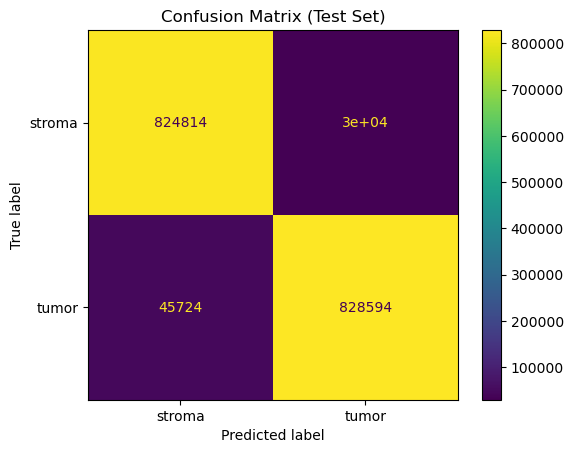

Classification Report (Test Set):
               precision    recall  f1-score   support

      stroma       0.95      0.97      0.96    854452
       tumor       0.97      0.95      0.96    874318

    accuracy                           0.96   1728770
   macro avg       0.96      0.96      0.96   1728770
weighted avg       0.96      0.96      0.96   1728770



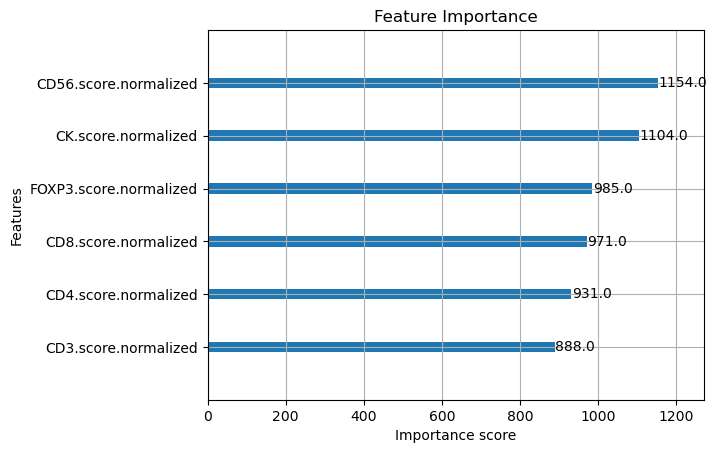

Initial row count: 17129856
Dropped due to NaN in tissue.type: 8486008
Used for training: 5186308
Used for validation: 1728770
Used for testing: 1728770
Tumor samples: 4372895
Non-tumor samples: 4270953
Train Accuracy: 0.956683636991864
Validation Accuracy: 0.9565436697767777
Test Accuracy: 0.9564071565332577


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder

# Load your DataFrame (replace with actual path if needed)
# df = pd.read_csv("your_data.csv")

# Drop rows with NaN in the target column
initial_count = len(df)
df_clean = df.dropna(subset=['tissue.type'])
dropped_count = initial_count - len(df_clean)

# Encode the target labels
label_encoder = LabelEncoder()
df_clean['tissue_encoded'] = label_encoder.fit_transform(df_clean['tissue.type'])

# Count tumor vs non-tumor
tumor_count = (df_clean['tissue.type'] == 'tumor').sum()
non_tumor_count = (df_clean['tissue.type'] != 'tumor').sum()

# Define feature columns
feature_cols = [
    'CD4.score.normalized', 'CK.score.normalized', 'FOXP3.score.normalized',
    'CD56.score.normalized', 'CD8.score.normalized', 'CD3.score.normalized'
]

# Prepare data
X = df_clean[feature_cols]
y = df_clean['tissue_encoded']

# Split into train, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Train the model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

# Predict and evaluate
train_pred = xgb_model.predict(X_train)
val_pred = xgb_model.predict(X_val)
test_pred = xgb_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Classification Report
report = classification_report(y_test, test_pred, target_names=label_encoder.classes_)
print("Classification Report (Test Set):\n", report)

# Feature Importance
xgb.plot_importance(xgb_model)
plt.title("Feature Importance")
plt.show()

# Summary
print("Initial row count:", initial_count)
print("Dropped due to NaN in tissue.type:", dropped_count)
print("Used for training:", len(X_train))
print("Used for validation:", len(X_val))
print("Used for testing:", len(X_test))
print("Tumor samples:", tumor_count)
print("Non-tumor samples:", non_tumor_count)
print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)


In [ ]:
# xgb_tumor_vs_not.py
# Predict in.ROI.tumor_tissue using normalized marker scores + cell.area (no coordinates, no ROI flags as features).

import json
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    f1_score, classification_report, confusion_matrix, log_loss
)
from xgboost import XGBClassifier

# =========================
# ========= CONFIG ========
# =========================
DATA_PATH = Path("/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF1/combined_BC1_IF1.tsv.gz")
SAVE_DIR = DATA_PATH.parent / "xgb_tumor_outputs"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COL = "in.ROI.tumor_tissue"   # binary target

# Features: normalized markers + cell.area (drop coords to avoid scale issues)
NORM_SCORE_COLS = [
    'CD4.score.normalized', 'CK.score.normalized', 'FOXP3.score.normalized',
    'CD56.score.normalized', 'CD8.score.normalized', 'CD3.score.normalized'
]
BASE_NUM = ['cell.area']

# Performance / resources
USE_GPU = False          # set True if you have a CUDA GPU
N_JOBS = 32              # CPU threads
N_SPLITS = 5             # GroupKFold splits
RANDOM_STATE = 42
MAX_ROWS = None          # e.g., 2_000_000 to prototype; None = all rows
DOWNSAMPLE_PER_CLASS = None  # e.g., 1_000_000 per class; None disables

# =========================
# ===== LOAD & PREP =======
# =========================
print("Loading data...")
usecols = list(set(['sample_id', LABEL_COL] + NORM_SCORE_COLS + BASE_NUM))
df = pd.read_csv(DATA_PATH, sep="\t", compression="gzip", usecols=usecols, low_memory=False, nrows=MAX_ROWS)

# Cast dtypes to shrink memory; keep NaN
for c in NORM_SCORE_COLS + BASE_NUM:
    if c in df.columns:
        df[c] = df[c].astype('float32')
if 'sample_id' in df.columns:
    df['sample_id'] = df['sample_id'].astype('category')

# Drop rows with missing label
before = len(df)
df = df[~df[LABEL_COL].isna()].copy()
print(f"Dropped rows with missing label: {before - len(df):,}")

# Encode label robustly to 0/1
y_raw = df[LABEL_COL]
if y_raw.dtype.name in ('boolean', 'bool'):
    y = y_raw.astype('int8').values
else:
    # Map common truthy/falsey representations
    true_set = set(['true','TRUE','True','1',1,True])
    false_set = set(['false','FALSE','False','0',0,False])
    def to01(v):
        if pd.isna(v):
            return np.nan
        if v in true_set:
            return 1
        if v in false_set:
            return 0
        # fallback: try numeric
        try:
            return 1 if float(v) != 0 else 0
        except Exception:
            return np.nan
    y = np.array([to01(v) for v in y_raw], dtype='float32')
    keep_mask = ~np.isnan(y)
    if not np.all(keep_mask):
        dropped = int((~keep_mask).sum())
        df = df.iloc[keep_mask]
        y = y[keep_mask]
        print(f"Dropped {dropped:,} rows due to ambiguous label values after mapping.")
    y = y.astype('int8')

# Build feature matrix
features = [c for c in (NORM_SCORE_COLS + BASE_NUM) if c in df.columns]
X = df[features].copy()

print(f"Final dataset: {len(df):,} rows, {len(features)} features.")
print("Features:", features)

# Class counts
unique, counts = np.unique(y, return_counts=True)
class_counts = dict(zip(unique.tolist(), counts.tolist()))
print("Class distribution:", class_counts)

# Define a helper to compute scale_pos_weight
def compute_scale_pos_weight(y_vec):
    # XGBoost uses neg/pos
    n_pos = int((y_vec == 1).sum())
    n_neg = int((y_vec == 0).sum())
    # Avoid division by zero
    n_pos = max(n_pos, 1)
    n_neg = max(n_neg, 1)
    return n_neg / n_pos


# Optional downsampling to speed up training
if DOWNSAMPLE_PER_CLASS is not None:
    rng = np.random.default_rng(RANDOM_STATE)
    keep_idxs = []
    for cls, cnt in class_counts.items():
        idx = np.where(y == cls)[0]
        if len(idx) > DOWNSAMPLE_PER_CLASS:
            idx = rng.choice(idx, size=DOWNSAMPLE_PER_CLASS, replace=False)
        keep_idxs.append(idx)
    keep_idxs = np.concatenate(keep_idxs)
    X = X.iloc[keep_idxs]
    y = y[keep_idxs]
    df = df.iloc[keep_idxs]
    print(f"Downsampled to {len(df):,} rows with cap {DOWNSAMPLE_PER_CLASS:,} per class.")

# =========================
# ==== GROUPED SPLIT ======
# =========================
# =========================
# ==== GROUPED SPLIT ======
# =========================

def build_groups(sample_id_series, n_splits):
    # Convert to string dtype; do not use 'category' here because NaNs remain NaN
    g = sample_id_series.astype('string')
    # Unique singleton groups for missing sample_id rows to avoid NaNs in groups
    missing = g.isna()
    if missing.any():
        g.loc[missing] = "__MISSING__" + sample_id_series.index[missing].astype(str)
        print(f"Assigned unique singleton groups to {int(missing.sum()):,} rows with missing sample_id.")
    # Ensure enough groups for n_splits
    n_groups = g.nunique(dropna=False)
    if n_groups < n_splits:
        print(f"Adjusting n_splits from {n_splits} to {n_groups} (only {n_groups} unique groups).")
        n_splits = int(n_groups)
    return g.to_numpy(), n_splits

groups, N_SPLITS = build_groups(df['sample_id'], N_SPLITS)

# Prefer stratified grouping if available; otherwise GroupKFold
try:
    from sklearn.model_selection import StratifiedGroupKFold
    splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    split_iter = splitter.split(X, y, groups=groups)
    strategy_used = "StratifiedGroupKFold"
except Exception:
    from sklearn.model_selection import GroupKFold
    splitter = GroupKFold(n_splits=N_SPLITS)
    split_iter = splitter.split(X, y, groups=groups)
    strategy_used = "GroupKFold"

train_idx, valid_idx = next(split_iter)
print(f"Using {strategy_used}: train={len(train_idx):,}, valid={len(valid_idx):,}")

# Build train/valid matrices
X_train = X.iloc[train_idx].reset_index(drop=True)
y_train = y[train_idx]
X_valid = X.iloc[valid_idx].reset_index(drop=True)
y_valid = y[valid_idx]

# Compute class weight from training fold
scale_pos_weight = compute_scale_pos_weight(y_train)
print(f"Training fold size: {len(y_train):,} "
      f"(pos={int((y_train==1).sum()):,}, neg={int((y_train==0).sum()):,}), "
      f"scale_pos_weight={scale_pos_weight:.3f}")
print(f"Validation fold size: {len(y_valid):,} "
      f"(pos={int((y_valid==1).sum()):,}, neg={int((y_valid==0).sum()):,})")



# =========================
# ====== TRAIN MODEL ======
# =========================
params = dict(
    tree_method="gpu_hist" if USE_GPU else "hist",
    max_depth=7,
    learning_rate=0.08,
    n_estimators=2000,        # early stopping will cut earlier
    subsample=0.7,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_jobs=N_JOBS,
    objective="binary:logistic",
    eval_metric=["auc", "aucpr"],  # track ROC AUC & PR AUC
    scale_pos_weight=scale_pos_weight,  # <-- now defined
)

model = XGBClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100,
    early_stopping_rounds=100
)


best_iter = getattr(model, "best_iteration", None)
print("Best iteration:", best_iter)

# =========================
# ===== EVALUATION ========
# =========================
y_prob = model.predict_proba(X_valid)[:, 1]
y_pred = (y_prob >= 0.5).astype('int8')

metrics = {
    "auc": float(roc_auc_score(y_valid, y_prob)),
    "avg_precision": float(average_precision_score(y_valid, y_prob)),
    "accuracy": float(accuracy_score(y_valid, y_pred)),
    "f1": float(f1_score(y_valid, y_pred)),
}
print("\nValidation metrics:")
for k, v in metrics.items():
    print(f" - {k}: {v:.4f}")

print("\nClassification report (validation):")
print(classification_report(y_valid, y_pred, target_names=["not_tumor", "tumor"]))

cm = confusion_matrix(y_valid, y_pred, labels=[0,1])
cm_df = pd.DataFrame(cm, index=["true_not_tumor","true_tumor"], columns=["pred_not_tumor","pred_tumor"])
print("\nConfusion matrix:\n", cm_df)

# =========================
# == SAMPLE PREDICTIONS ===
# =========================
sample_view_cols = ['sample_id', LABEL_COL] + features
val_df = df.iloc[valid_idx][sample_view_cols].copy()
val_df["y_true"] = y_valid
val_df["y_prob_tumor"] = y_prob
val_df["y_pred"] = y_pred

# Show top-5 most confident tumor and not_tumor predictions
top_tumor = val_df.sort_values("y_prob_tumor", ascending=False).head(5)
top_not = val_df.sort_values("y_prob_tumor", ascending=True).head(5)

print("\nTop-5 predicted TUMOR (highest probabilities):")
print(top_tumor[["sample_id","y_true","y_pred","y_prob_tumor"] + NORM_SCORE_COLS].to_string(index=False, max_cols=999))

print("\nTop-5 predicted NOT TUMOR (lowest probabilities):")
print(top_not[["sample_id","y_true","y_pred","y_prob_tumor"] + NORM_SCORE_COLS].to_string(index=False, max_cols=999))

# Also save a random 1,000 validation predictions for inspection
rng = np.random.default_rng(RANDOM_STATE)
take = min(1000, len(val_df))
rows = rng.choice(len(val_df), size=take, replace=False)
pred_sample = val_df.iloc[rows]
pred_path = SAVE_DIR / "validation_pred_sample.tsv"
pred_sample.to_csv(pred_path, sep="\t", index=False)
print(f"\nSaved a random sample of validation predictions to: {pred_path}")

# =========================
# == FEATURE IMPORTANCE ===
# =========================
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 15 features by importance:")
print(fi.head(15))

fi_path = SAVE_DIR / "feature_importance.tsv"
fi.reset_index().rename(columns={"index":"feature", 0:"importance"}).to_csv(fi_path, sep="\t", index=False)
print("Saved feature importances to:", fi_path)

# =========================
# ======= SAVE MODEL ======
# =========================
model_path = SAVE_DIR / f"xgb_tumor_vs_not{'_gpu' if USE_GPU else ''}.json"
model.save_model(model_path.as_posix())
print("Saved model to:", model_path)

# Save run meta
meta = {
    "data_path": DATA_PATH.as_posix(),
    "label_col": LABEL_COL,
    "features": features,
    "n_splits": N_SPLITS,
    "best_iteration": int(best_iter) if best_iter is not None else None,
    "valid_metrics": metrics,
    "params": params,
    "class_distribution": class_counts,
}
with open(SAVE_DIR / "run_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved run meta to:", SAVE_DIR / "run_meta.json")


Loading data...
Dropped rows with missing label: 19,811,284
Final dataset: 14,448,428 rows, 7 features.
Features: ['CD4.score.normalized', 'CK.score.normalized', 'FOXP3.score.normalized', 'CD56.score.normalized', 'CD8.score.normalized', 'CD3.score.normalized', 'cell.area']
Class distribution: {0: 907654, 1: 13540774}
Assigned unique singleton groups to 14,448,428 rows with missing sample_id.
Using StratifiedGroupKFold: train=11,558,743, valid=2,889,685


NameError: name 'scale_pos_weight' is not defined

## GPU XgBoost

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import gc
from xgboost.callback import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    f1_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier
import xgboost as xgb

# =========================
# ========= CONFIG ========
# =========================
DATA_PATH = Path("/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF1/combined_BC1_IF1.tsv.gz")
SAVE_DIR = DATA_PATH.parent / "xgb_tumor_outputs_gpu"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COL = "in.ROI.tumor_tissue"   # binary target

# Features: normalized markers + cell.area (no coords)
NORM_SCORE_COLS = [
    'CD4.score.normalized', 'CK.score.normalized', 'FOXP3.score.normalized',
    'CD56.score.normalized', 'CD8.score.normalized', 'CD3.score.normalized'
]
BASE_NUM = ['cell.area']
features_all = NORM_SCORE_COLS + BASE_NUM

# Performance / resources
USE_GPU = True            # <— GPU mode
GPU_ID = 0                # select which GPU to use
N_JOBS = 32               # CPU threads (parser / some host ops)
N_SPLITS = 5              # CV splits
RANDOM_STATE = 42
MAX_ROWS = None           # e.g., 2_000_000 to prototype; None = all rows
DOWNSAMPLE_PER_CLASS = None  # e.g., 2_000_000 per class; None disables

# =========================
# ===== LOAD & PREP =======
# =========================
print("Loading data...")
usecols = ['sample_id', LABEL_COL] + [c for c in features_all if c not in ('sample_id', LABEL_COL)]
df = pd.read_csv(DATA_PATH, sep="\t", compression="gzip", usecols=usecols,
                 low_memory=False, nrows=MAX_ROWS)

# Cast numeric to float32 for GPU efficiency
for c in features_all:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').astype('float32')

# sample_id as string (used only for grouping, not as a feature)
if 'sample_id' in df.columns:
    df['sample_id'] = df['sample_id'].astype('string')

# Drop rows with missing label
before = len(df)
df = df[~df[LABEL_COL].isna()].copy()
print(f"Dropped rows with missing label: {before - len(df):,}")

# Encode label robustly to 0/1
y_raw = df[LABEL_COL]
if str(y_raw.dtype) in ('boolean', 'bool'):
    y = y_raw.astype('int8').to_numpy()
else:
    true_set = {'true','TRUE','True','1',1,True}
    false_set = {'false','FALSE','False','0',0,False}
    def to01(v):
        if pd.isna(v):
            return np.nan
        if v in true_set:
            return 1
        if v in false_set:
            return 0
        try:
            return 1 if float(v) != 0 else 0
        except Exception:
            return np.nan
    y_tmp = np.array([to01(v) for v in y_raw], dtype='float32')
    keep_mask = ~np.isnan(y_tmp)
    if not np.all(keep_mask):
        dropped = int((~keep_mask).sum())
        df = df.loc[keep_mask].copy()
        y_tmp = y_tmp[keep_mask]
        print(f"Dropped {dropped:,} rows due to ambiguous label values after mapping.")
    y = y_tmp.astype('int8')

# Build feature matrix
features = [c for c in features_all if c in df.columns]
X = df[features].copy()

print(f"Final dataset: {len(df):,} rows, {len(features)} features.")
print("Features:", features)

# Class counts
unique, counts = np.unique(y, return_counts=True)
class_counts = dict(zip(unique.tolist(), counts.tolist()))
print("Class distribution:", class_counts)

# Optional downsampling to speed up iteration
if DOWNSAMPLE_PER_CLASS is not None:
    rng = np.random.default_rng(RANDOM_STATE)
    keep_idxs = []
    for cls in unique:
        idx = np.where(y == cls)[0]
        if len(idx) > DOWNSAMPLE_PER_CLASS:
            idx = rng.choice(idx, size=DOWNSAMPLE_PER_CLASS, replace=False)
        keep_idxs.append(idx)
    keep_idxs = np.concatenate(keep_idxs)
    X = X.iloc[keep_idxs].reset_index(drop=True)
    y = y[keep_idxs]
    df = df.iloc[keep_idxs].reset_index(drop=True)
    print(f"Downsampled to {len(df):,} rows with cap {DOWNSAMPLE_PER_CLASS:,} per class.")

gc.collect()

# =========================
# ==== CV STRATEGY ========
# =========================
def compute_scale_pos_weight(y_vec):
    n_pos = int((y_vec == 1).sum())
    n_neg = int((y_vec == 0).sum())
    n_pos = max(n_pos, 1); n_neg = max(n_neg, 1)
    return n_neg / n_pos

# Choose grouped CV if sample_id is informative; else stratified KFold
strategy_used = None
has_sample_id = ('sample_id' in df.columns) and (df['sample_id'].notna().sum() > 0)

if has_sample_id:
    g_codes, g_uniques = pd.factorize(df['sample_id'].astype('string').fillna("__MISSING__"))
    if len(g_uniques) > 1 or (len(g_uniques) == 1 and g_uniques[0] != "__MISSING__"):
        try:
            from sklearn.model_selection import StratifiedGroupKFold
            splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            split_iter = splitter.split(X, y, groups=g_codes)
            strategy_used = "StratifiedGroupKFold"
            train_idx, valid_idx = next(split_iter)
        except Exception as e:
            print("StratifiedGroupKFold unavailable/failure, falling back to StratifiedKFold:", e)
            splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            train_idx, valid_idx = next(splitter.split(X, y))
            strategy_used = "StratifiedKFold"
    else:
        print("sample_id present but not informative -> using StratifiedKFold.")
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        train_idx, valid_idx = next(splitter.split(X, y))
        strategy_used = "StratifiedKFold"
else:
    print("No usable sample_id -> using StratifiedKFold.")
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    train_idx, valid_idx = next(splitter.split(X, y))
    strategy_used = "StratifiedKFold"

print(f"Using {strategy_used}: train={len(train_idx):,}, valid={len(valid_idx):,}")

# =========================
# ====== TRAIN MODEL ======
# =========================
X_train = X.iloc[train_idx].reset_index(drop=True)
y_train = y[train_idx]
X_valid = X.iloc[valid_idx].reset_index(drop=True)
y_valid = y[valid_idx]

scale_pos_weight = compute_scale_pos_weight(y_train)
print(f"Training fold: {len(y_train):,} rows "
      f"(pos={(y_train==1).sum():,}, neg={(y_train==0).sum():,}), "
      f"scale_pos_weight={scale_pos_weight:.3f}")
print(f"Validation fold: {len(y_valid):,} rows "
      f"(pos={(y_valid==1).sum():,}, neg={(y_valid==0).sum():,})")

# --- GPU params ---
# Works across XGBoost 1.6+ and 2.x
params = dict(
    tree_method="gpu_hist",          # <— GPU training
    predictor="gpu_predictor",       # <— GPU inference
    gpu_id=GPU_ID,                   # <— pick your device
    max_depth=7,
    learning_rate=0.08,
    n_estimators=3000,               # early stopping will cut earlier
    subsample=0.7,
    colsample_bytree=0.8,
    max_bin=256,                     # good speed/memory tradeoff on GPU
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_jobs=N_JOBS,                   # host-side parallelism
    objective="binary:logistic",
    eval_metric=["auc", "aucpr"],    # track both ROC AUC and PR AUC
    scale_pos_weight=scale_pos_weight,
    # Optional: increase stability on skewed data
    # max_delta_step=1,
)

print(f"XGBoost version: {xgb.__version__}")
model = XGBClassifier(**params)

# Fit with early stopping

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100,
    callbacks=[EarlyStopping(rounds=200, save_best=True)]
)


best_iter = getattr(model, "best_iteration", getattr(model, "best_iteration_", None))
print("Best iteration:", best_iter)

# =========================
# ===== EVALUATION ========
# =========================
y_prob = model.predict_proba(X_valid)[:, 1]
y_pred = (y_prob >= 0.5).astype('int8')

metrics = {
    "auc": float(roc_auc_score(y_valid, y_prob)),
    "avg_precision": float(average_precision_score(y_valid, y_prob)),
    "accuracy": float(accuracy_score(y_valid, y_pred)),
    "f1": float(f1_score(y_valid, y_pred)),
}
print("\nValidation metrics:")
for k, v in metrics.items():
    print(f" - {k}: {v:.4f}")

print("\nClassification report (validation):")
print(classification_report(y_valid, y_pred, target_names=["not_tumor", "tumor"]))

cm = confusion_matrix(y_valid, y_pred, labels=[0,1])
cm_df = pd.DataFrame(cm, index=["true_not_tumor","true_tumor"], columns=["pred_not_tumor","pred_tumor"])
print("\nConfusion matrix:\n", cm_df)

# =========================
# == SAMPLE PREDICTIONS ===
# =========================
sample_view_cols = ['sample_id', LABEL_COL] + features
val_df = df.iloc[valid_idx][sample_view_cols].copy()
val_df["y_true"] = y_valid
val_df["y_prob_tumor"] = y_prob
val_df["y_pred"] = y_pred

top_tumor = val_df.sort_values("y_prob_tumor", ascending=False).head(5)
top_not = val_df.sort_values("y_prob_tumor", ascending=True).head(5)

print("\nTop-5 predicted TUMOR (highest probabilities):")
print(top_tumor[["sample_id","y_true","y_pred","y_prob_tumor"] + NORM_SCORE_COLS].to_string(index=False, max_cols=999))

print("\nTop-5 predicted NOT TUMOR (lowest probabilities):")
print(top_not[["sample_id","y_true","y_pred","y_prob_tumor"] + NORM_SCORE_COLS].to_string(index=False, max_cols=999))

# Save a random sample of validation predictions for inspection
rng = np.random.default_rng(RANDOM_STATE)
take = min(1000, len(val_df))
rows = rng.choice(len(val_df), size=take, replace=False)
pred_sample = val_df.iloc[rows]
pred_path = SAVE_DIR / "validation_pred_sample.tsv"
pred_sample.to_csv(pred_path, sep="\t", index=False)
print(f"\nSaved a random sample of validation predictions to: {pred_path}")

# =========================
# == FEATURE IMPORTANCE ===
# =========================
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop 15 features by importance:")
print(fi.head(15))

fi_path = SAVE_DIR / "feature_importance.tsv"
fi.reset_index().rename(columns={"index":"feature", 0:"importance"}).to_csv(fi_path, sep="\t", index=False)
print("Saved feature importances to:", fi_path)

# =========================
# ======= SAVE MODEL ======
# =========================
model_path = SAVE_DIR / f"xgb_tumor_vs_not_gpu.json"
model.save_model(model_path.as_posix())
print("Saved model to:", model_path)

# Save run meta
meta = {
    "data_path": DATA_PATH.as_posix(),
    "label_col": LABEL_COL,
    "features": features,
    "n_splits": N_SPLITS,
    "best_iteration": int(best_iter) if best_iter is not None else None,
    "valid_metrics": metrics,
    "params": params,
    "class_distribution": class_counts,
    "cv_strategy": strategy_used,
    "use_gpu": USE_GPU,
    "gpu_id": GPU_ID,
}
with open(SAVE_DIR / "run_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved run meta to:", SAVE_DIR / "run_meta.json")


Loading data...
Dropped rows with missing label: 19,811,284
Final dataset: 14,448,428 rows, 7 features.
Features: ['CD4.score.normalized', 'CK.score.normalized', 'FOXP3.score.normalized', 'CD56.score.normalized', 'CD8.score.normalized', 'CD3.score.normalized', 'cell.area']
Class distribution: {0: 907654, 1: 13540774}
No usable sample_id -> using StratifiedKFold.
Using StratifiedKFold: train=11,558,742, valid=2,889,686
Training fold: 11,558,742 rows (pos=10,832,619, neg=726,123), scale_pos_weight=0.067
Validation fold: 2,889,686 rows (pos=2,708,155, neg=181,531)
XGBoost version: 3.0.4


TypeError: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'

In [ ]:
import os
import gzip
import pandas as pd

# Set your folder path here
folder_path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1"

# Prepare a list to store results
summary = []

# Loop through all files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".tsv.gz"):
        file_path = os.path.join(folder_path, filename)
        try:
            with gzip.open(file_path, 'rt') as f:
                df = pd.read_csv(f, sep='\t', nrows=0)  # Read only header
                columns = list(df.columns)
                summary.append((filename, columns))
        except Exception as e:
            summary.append((filename, [f"Error reading file: {e}"]))

# Save to text file
with open("summary.txt", "w") as txt_file:
    for filename, columns in summary:
        txt_file.write(f"{filename}: {', '.join(columns)}\n")

# Save to Excel file
df_summary = pd.DataFrame(summary, columns=["Filename", "Columns"])
df_summary["Columns"] = df_summary["Columns"].apply(lambda cols: ", ".join(cols))
df_summary.to_excel("summary.xlsx", index=False)

# Print to console
for filename, columns in summary:
    print(f"{filename}: {', '.join(columns)}")


# checking data heterogeneousity

In [2]:
import os
import gzip
import pandas as pd
from collections import Counter


# Set your folder path here
folder_path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1"

# Prepare a list to store results
summary = []
filenames_seen = []

# Loop through all files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".tsv.gz"):
        filenames_seen.append(filename)
        file_path = os.path.join(folder_path, filename)
        try:
            with gzip.open(file_path, 'rt') as f:
                df = pd.read_csv(f, sep='\t', nrows=0)  # Read only header
                columns = list(df.columns)
                summary.append((filename, columns))
        except Exception as e:
            summary.append((filename, [f"Error reading file: {e}"]))

# Detect duplicates
duplicates = [item for item, count in Counter(filenames_seen).items() if count > 1]

# Save to text file
with open("/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/data_heteregenousity/summary.txt", "w") as txt_file:
    for filename, columns in summary:
        txt_file.write(f"{filename}: {', '.join(columns)}\n")
    if duplicates:
        txt_file.write("\nDuplicate filenames detected:\n")
        for dup in duplicates:
            txt_file.write(f"- {dup}\n")

# Save to Excel file
df_summary = pd.DataFrame(summary, columns=["Filename", "Columns"])
df_summary["Columns"] = df_summary["Columns"].apply(lambda cols: ", ".join(cols))
df_summary.to_excel("/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/data_heteregenousity/summary.xlsx", index=False)

# Print to console
for filename, columns in summary:
    print(f"{filename}: {', '.join(columns)}")

if duplicates:
    print("\n Duplicate filenames detected:")
    for dup in duplicates:
        print(f"- {dup}")


In [4]:
import os
import gzip
import pandas as pd
from collections import Counter

# Set your folder path here
folder_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files"

# Prepare a list to store results
summary = []
filenames_seen = []

# Loop through all files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".tsv.gz"):
        filenames_seen.append(filename)
        file_path = os.path.join(folder_path, filename)
        try:
            with gzip.open(file_path, 'rt') as f:
                # Try reading just the header
                header_line = f.readline()
                if header_line.strip():  # Check if header is not empty
                    columns = header_line.strip().split('\t')
                    summary.append((filename, columns))
                else:
                    summary.append((filename, ["Empty file or no header"]))
        except Exception as e:
            summary.append((filename, [f"Error reading file: {e}"]))

# Detect duplicates
duplicates = [item for item, count in Counter(filenames_seen).items() if count > 1]

# Save to text file
with open("/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/data_heteregenousity/summary.txt", "w") as txt_file:
    for filename, columns in summary:
        txt_file.write(f"{filename}: {', '.join(columns)}\n")
    if duplicates:
        txt_file.write("\nDuplicate filenames detected:\n")
        for dup in duplicates:
            txt_file.write(f"- {dup}\n")

# Save to Excel file
df_summary = pd.DataFrame(summary, columns=["Filename", "Columns"])
df_summary["Columns"] = df_summary["Columns"].apply(lambda cols: ", ".join(cols))
df_summary.to_excel("/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/data_heteregenousity/summary.xlsx", index=False)

# Print to console
for filename, columns in summary:
    print(f"{filename}: {', '.join(columns)}")

if duplicates:
    print("\n⚠️ Duplicate filenames detected:")
    for dup in duplicates:
        print(f"- {dup}")


In [5]:
# audit_tsv_gz.py
import os
import re
from difflib import SequenceMatcher
import math
import pandas as pd
from datetime import datetime
from typing import List, Dict, Tuple

# -------------------- Configuration --------------------
SOURCE_DIR = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files"
OUT_DIR = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/data_heteregenousity"

# Tune if needed
CHUNKSIZE = 200_000               # rows per chunk when computing NaN %
SIMILARITY_THRESHOLD = 0.86       # 0..1; higher = stricter
COMPUTE_NAN_PERCENT = True        # set False to quickly get only columns

# NA tokens commonly used in TSV exports
NA_TOKENS = ["", "NA", "N/A", "na", "null", "None", "NaN"]

# -------------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)

def human_mb(num_bytes: int) -> float:
    return round(num_bytes / (1024 * 1024), 3)

def normalize_name(name: str) -> str:
    """
    Normalize filename (without extensions) to improve 'similar name' detection.
    - Lowercase
    - Remove long numerics (dates, hashes)
    - Collapse separators
    - Remove common replicate suffixes
    """
    base = name
    if base.endswith(".gz"):
        base = base[:-3]
    if base.endswith(".tsv"):
        base = base[:-4]

    s = base.lower()
    s = re.sub(r'\d{8,}', ' ', s)                # long numbers (e.g., dates 20240101)
    s = re.sub(r'[_\-\.\s]+', ' ', s)            # unify separators
    s = re.sub(r'\b(rep|repeat|r)\d+\b', ' ', s) # replicate patterns
    s = re.sub(r'\b(v|ver|version)\d+\b', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def similar_name_groups(filenames: List[str], threshold: float) -> List[List[str]]:
    """
    Group filenames by similarity using a greedy union approach on normalized names.
    """
    norms = [normalize_name(f) for f in filenames]
    n = len(filenames)
    used = [False] * n
    groups: List[List[str]] = []

    for i in range(n):
        if used[i]: 
            continue
        group = [filenames[i]]
        used[i] = True
        for j in range(i + 1, n):
            if used[j]:
                continue
            ratio = SequenceMatcher(None, norms[i], norms[j]).ratio()
            if ratio >= threshold:
                group.append(filenames[j])
                used[j] = True
        if len(group) > 1:
            groups.append(group)
    return groups

def get_columns(file_path: str) -> List[str]:
    df0 = pd.read_csv(
        file_path,
        sep="\t",
        compression="infer",
        nrows=0,
        dtype=str,
        na_values=NA_TOKENS,
        keep_default_na=True,
        on_bad_lines="skip",
        encoding="utf-8",
    )
    return list(df0.columns)

def compute_nan_percentages(file_path: str, columns: List[str], chunksize: int) -> Tuple[int, pd.Series]:
    """
    Returns total_rows and a Series indexed by columns with NaN percentage (0..100).
    """
    total_rows = 0
    nonnull_counts = pd.Series(0, index=pd.Index(columns, name="column"), dtype="int64")

    reader = pd.read_csv(
        file_path,
        sep="\t",
        compression="infer",
        dtype=str,  # keep strings as is; NA detection still applies via na_values
        na_values=NA_TOKENS,
        keep_default_na=True,
        chunksize=chunksize,
        on_bad_lines="skip",
        encoding="utf-8",
    )

    for chunk in reader:
        # Align in case chunk columns differ slightly
        chunk = chunk.reindex(columns=columns)
        total_rows += len(chunk)
        nonnull_counts += chunk.notna().sum()

    if total_rows == 0:
        nan_pct = pd.Series(float("nan"), index=columns)
    else:
        nan_pct = (1 - (nonnull_counts / total_rows)) * 100.0
    return total_rows, nan_pct.round(6)

def main():
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Scanning: {SOURCE_DIR}")
    all_files = sorted([
        f for f in os.listdir(SOURCE_DIR)
        if f.lower().endswith(".tsv.gz")
    ])
    if not all_files:
        print("No .tsv.gz files found.")
        return

    # Storage for outputs
    rows_columns = []  # for Columns_By_File
    rows_nan = []      # for NaN_Percentages
    rows_summary = []  # for File_Summary

    # Process each file
    for idx, fname in enumerate(all_files, start=1):
        fpath = os.path.join(SOURCE_DIR, fname)
        print(f"[{idx}/{len(all_files)}] Processing {fname} ...")
        size_mb = human_mb(os.path.getsize(fpath))
        status = "OK"
        err_msg = None

        try:
            columns = get_columns(fpath)
            cols_joined = " | ".join(columns)
            rows_columns.append({
                "File": fname,
                "Num_Columns": len(columns),
                "Columns": cols_joined
            })

            total_rows = None
            if COMPUTE_NAN_PERCENT and len(columns) > 0:
                total_rows, nan_pct = compute_nan_percentages(fpath, columns, CHUNKSIZE)
                # Expand to long format
                for col, pct in nan_pct.items():
                    rows_nan.append({
                        "File": fname,
                        "Column": col,
                        "Total_Rows": total_rows,
                        "NonNull_Count": None if math.isnan(pct) else int(round((1 - pct/100.0) * (total_rows or 0))),
                        "NaN_Percent": pct
                    })

            rows_summary.append({
                "File": fname,
                "Size_MB": size_mb,
                "Total_Rows": total_rows,
                "Num_Columns": len(columns),
                "Parse_Status": status,
                "Error": err_msg
            })
        except Exception as e:
            status = "ERROR"
            err_msg = str(e)
            print(f"  -> ERROR parsing {fname}: {err_msg}")

            rows_summary.append({
                "File": fname,
                "Size_MB": size_mb,
                "Total_Rows": None,
                "Num_Columns": None,
                "Parse_Status": status,
                "Error": err_msg
            })

    # Similar name grouping
    groups = similar_name_groups(all_files, SIMILARITY_THRESHOLD)
    rows_similar = []
    for gid, group in enumerate(groups, start=1):
        for member in group:
            rows_similar.append({"Group_ID": gid, "File": member})
    if not rows_similar:
        rows_similar.append({"Group_ID": None, "File": "(No similar name groups found at this threshold)"})

    # Build DataFrames
    df_cols = pd.DataFrame(rows_columns).sort_values(["File"]).reset_index(drop=True)
    df_nan = pd.DataFrame(rows_nan).sort_values(["File", "Column"]).reset_index(drop=True) if rows_nan else pd.DataFrame(columns=["File","Column","Total_Rows","NonNull_Count","NaN_Percent"])
    df_sim = pd.DataFrame(rows_similar).sort_values(["Group_ID","File"], na_position="last").reset_index(drop=True)
    df_sum = pd.DataFrame(rows_summary).sort_values(["Parse_Status", "File"]).reset_index(drop=True)

    # Save Excel
    excel_path = os.path.join(OUT_DIR, "tsv_audit.xlsx")
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        df_cols.to_excel(writer, index=False, sheet_name="Columns_By_File")
        df_nan.to_excel(writer, index=False, sheet_name="NaN_Percentages")
        df_sim.to_excel(writer, index=False, sheet_name="Similar_Names")
        df_sum.to_excel(writer, index=False, sheet_name="File_Summary")

    # Save TXT mapping
    txt_path = os.path.join(OUT_DIR, "columns_by_file.txt")
    with open(txt_path, "w", encoding="utf-8") as fh:
        fh.write(f"TSV Audit Summary ({datetime.now().strftime('%Y-%m-%d %H:%M:%S')})\n")
        fh.write(f"Source directory: {SOURCE_DIR}\n")
        fh.write(f"Output directory: {OUT_DIR}\n")
        fh.write(f"Files scanned: {len(all_files)}\n\n")
        fh.write("=== Columns by File ===\n\n")
        for _, r in df_cols.iterrows():
            fh.write(f"- {r['File']}  [#cols={r['Num_Columns']}]\n")
            fh.write(f"  Columns: {r['Columns']}\n\n")
        fh.write("\n=== Similar Name Groups ===\n")
        if groups:
            for gid, group in enumerate(groups, start=1):
                fh.write(f"Group {gid}:\n")
                for member in group:
                    fh.write(f"  - {member}\n")
                fh.write("\n")
        else:
            fh.write("(No similar name groups found at the current threshold)\n")

    print(f"\nDone ✅")
    print(f"Excel saved to: {excel_path}")
    print(f"TXT saved to:   {txt_path}")

if __name__ == "__main__":
    main()


[2025-09-04 08:59:28] Scanning: /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files
No .tsv.gz files found.


# Sorting Tsv and QPTIFF for IF Immucan

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import csv
import gzip
import json
import argparse
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from difflib import SequenceMatcher
from collections import defaultdict, Counter

# ----------------------------
# Utilities: filenames & paths
# ----------------------------

IMAGE_EXTS_DEFAULT = {".qptiff", ".qptif", ".tif", ".tiff", ".svs"}
TSV_EXTS_DEFAULT = {
    ".tsv", ".csv", ".txt",
    ".tsv.gz", ".csv.gz", ".txt.gz"
}

def is_gz(p: Path) -> bool:
    return "".join(p.suffixes[-2:]) in {".tsv.gz", ".csv.gz", ".txt.gz"} or p.suffix == ".gz"

def normalized_suffixes(p: Path) -> str:
    """Return suffix combo like '.tsv.gz' if present, else final suffix."""
    sfx = "".join(p.suffixes[-2:]) if len(p.suffixes) >= 2 else p.suffix
    return sfx
def strip_multi_ext(name: str) -> str:
    """
    Remove one of: .tsv(.gz) | .csv(.gz) | .txt(.gz) | .qptiff | .tif(f) | .svs
    Return the base without extensions.
    """
    # handle common double extensions
    for double in (".tsv.gz", ".csv.gz", ".txt.gz"):
        if name.lower().endswith(double):
            return name[: -len(double)]
    # handle common single
    for single in (".tsv", ".csv", ".txt", ".qptiff", ".qptif", ".tiff", ".tif", ".svs"):
        if name.lower().endswith(single):
            return name[: -len(single)]
    # default: strip last extension if any
    return re.sub(r"\.[^.]+$", "", name)

def get_base_id_from_name(name: str) -> str:
    """
    Base ID defined as the part before the first '_#_'.
    E.g., 'IMMU-BC1-0297-FIXT-02-IF3-01_#_hash' -> 'IMMU-BC1-0297-FIXT-02-IF3-01'
    """
    core = strip_multi_ext(name)
    return core.split("_#_", 1)[0]

def find_files(root: Path, exts: set) -> List[Path]:
    found = []
    for p in root.rglob("*"):
        if not p.is_file():
            continue
        sfx_combo = normalized_suffixes(p).lower()
        sfx_single = p.suffix.lower()
        if sfx_combo in exts or sfx_single in exts:
            found.append(p)
    return found

# ----------------------------
# Matching helpers
# ----------------------------

def seq_ratio(a: str, b: str) -> float:
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

def token_set(s: str) -> set:
    toks = re.split(r"[^\w]+", s.lower())
    return {t for t in toks if t}

def jaccard(a: set, b: set) -> float:
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def combined_similarity(a: str, b: str) -> Tuple[float, float, float]:
    r = seq_ratio(a, b)
    jac = jaccard(token_set(a), token_set(b))
    return r, jac, 0.6 * r + 0.4 * jac

# ----------------------------
# TSV header extraction
# ----------------------------

def detect_header_and_delimiter(sample: str) -> Tuple[Optional[str], Optional[str]]:
    """
    From a text sample, find the first non-empty, non-comment line and guess delimiter.
    Returns (header_line, delimiter) or (None, None).
    """
    lines = sample.splitlines()
    header_line = None
    for line in lines:
        if not line.strip():
            continue
        if line.lstrip().startswith("#"):
            continue
        # Strip BOM if present
        line = line.lstrip("\ufeff")
        header_line = line
        break
    if header_line is None:
        return None, None

    # Heuristic delimiter detection: prefer tab if present
    if "\t" in header_line:
        delim = "\t"
    elif "," in header_line:
        delim = ","
    else:
        # try csv.Sniffer as last resort
        try:
            dialect = csv.Sniffer().sniff(header_line)
            delim = dialect.delimiter
        except Exception:
            # fallback: split on whitespace
            delim = "\t" if "\t" in sample else ","
    return header_line, delim

def parse_header_columns_from_stream(stream) -> Tuple[List[str], str]:
    """
    Read up to ~128 KB, detect header and delimiter, return (columns, delimiter).
    """
    sample = stream.read(131072)
    header_line, delim = detect_header_and_delimiter(sample)
    if header_line is None or delim is None:
        return [], ""
    # Split columns, remove quotes and trim
    cols = [c.strip().strip('"').strip("'") for c in header_line.split(delim)]
    # Remove empty trailing column if any weird split
    cols = [c for c in cols if c != ""]
    return cols, delim

def read_tsv_columns(tsv_path: Path) -> Tuple[List[str], str, bool, str]:
    """
    Returns (columns, delimiter, is_gzip, status)
    status: 'ok' | 'no_header' | 'error:<msg>'
    """
    try:
        gz = is_gz(tsv_path)
        if gz:
            with gzip.open(tsv_path, mode="rt", encoding="utf-8", errors="replace") as f:
                cols, delim = parse_header_columns_from_stream(f)
        else:
            with open(tsv_path, "rt", encoding="utf-8", errors="replace") as f:
                cols, delim = parse_header_columns_from_stream(f)
        if cols:
            return cols, (delim or ""), gz, "ok"
        else:
            return [], (delim or ""), gz, "no_header"
    except Exception as e:
        return [], "", False, f"error:{type(e).__name__}:{e}"

# ----------------------------
# Core mapping logic
# ----------------------------

def build_index_by_base_id(paths: List[Path]) -> Dict[str, List[Path]]:
    idx = defaultdict(list)
    for p in paths:
        base = get_base_id_from_name(p.name)
        idx[base].append(p)
    return idx

def map_images_to_tsvs(
    image_paths: List[Path],
    tsv_paths: List[Path],
    enable_fuzzy: bool = True,
    fuzzy_threshold: float = 0.80
) -> List[Dict]:
    """
    Produce rows mapping each image to 0..N TSVs. If none via base-id, optionally fuzzy.
    Returns list of dict rows (without TSV columns yet).
    """
    img_idx = build_index_by_base_id(image_paths)
    tsv_idx = build_index_by_base_id(tsv_paths)

    # Precompute base lists for fuzzy
    img_bases = sorted(img_idx.keys())
    tsv_bases = sorted(tsv_idx.keys())

    rows = []
    for img_base in img_bases:
        imgs = img_idx[img_base]
        matched_tsvs = tsv_idx.get(img_base, [])
        if matched_tsvs:
            for ip in imgs:
                for tp in matched_tsvs:
                    rows.append({
                        "match_type": "base_id",
                        "image_base_id": img_base,
                        "tsv_base_id": img_base,
                        "image_name": ip.name,
                        "image_path": str(ip.resolve()),
                        "tsv_name": tp.name,
                        "tsv_path": str(tp.resolve()),
                        "seq_ratio": "",
                        "token_jaccard": "",
                        "combined_score": ""
                    })
            continue

        # Fuzzy fallback per image_base (if requested)
        if enable_fuzzy and tsv_bases:
            # score all tsv_bases vs img_base
            scored = []
            for tb in tsv_bases:
                r, jac, combo = combined_similarity(img_base, tb)
                if combo >= fuzzy_threshold:
                    scored.append((combo, r, jac, tb))
            scored.sort(key=lambda x: x[0], reverse=True)

            if scored:
                # link to top match only (to avoid spurious many-to-one fuzzies)
                best_combo, r, jac, tb = scored[0]
                for ip in imgs:
                    for tp in tsv_idx[tb]:
                        rows.append({
                            "match_type": "fuzzy",
                            "image_base_id": img_base,
                            "tsv_base_id": tb,
                            "image_name": ip.name,
                            "image_path": str(ip.resolve()),
                            "tsv_name": tp.name,
                            "tsv_path": str(tp.resolve()),
                            "seq_ratio": f"{r:.4f}",
                            "token_jaccard": f"{jac:.4f}",
                            "combined_score": f"{best_combo:.4f}"
                        })
            else:
                # no matches found (unmatched image placeholder)
                for ip in imgs:
                    rows.append({
                        "match_type": "unmatched_image",
                        "image_base_id": img_base,
                        "tsv_base_id": "",
                        "image_name": ip.name,
                        "image_path": str(ip.resolve()),
                        "tsv_name": "",
                        "tsv_path": "",
                        "seq_ratio": "",
                        "token_jaccard": "",
                        "combined_score": ""
                    })
        else:
            # no fuzzy, unmatched
            for ip in imgs:
                rows.append({
                    "match_type": "unmatched_image",
                    "image_base_id": img_base,
                    "tsv_base_id": "",
                    "image_name": ip.name,
                    "image_path": str(ip.resolve()),
                    "tsv_name": "",
                    "tsv_path": "",
                    "seq_ratio": "",
                    "token_jaccard": "",
                    "combined_score": ""
                })

    return rows

def enrich_rows_with_tsv_columns(rows: List[Dict]) -> Tuple[List[Dict], Dict[str, Dict]]:
    """
    For each distinct TSV path in rows, read columns and append:
      - tsv_columns_json (JSON array of strings)
      - tsv_n_columns
      - tsv_delimiter
      - tsv_is_gzip
      - tsv_read_status
    Returns (updated_rows, per_tsv_info_dict)
    """
    # Collect unique TSVs present (ignore empty)
    unique_tsvs = sorted({r["tsv_path"] for r in rows if r.get("tsv_path")})
    per_tsv = {}

    for tsv in unique_tsvs:
        p = Path(tsv)
        cols, delim, isgz, status = read_tsv_columns(p)
        per_tsv[tsv] = {
            "tsv_columns_json": json.dumps(cols, ensure_ascii=False),
            "tsv_n_columns": len(cols),
            "tsv_delimiter": "\\t" if delim == "\t" else delim,
            "tsv_is_gzip": str(isgz),
            "tsv_read_status": status
        }

    out_rows = []
    for r in rows:
        r2 = dict(r)
        info = per_tsv.get(r.get("tsv_path", ""), None)
        if info:
            r2.update(info)
        else:
            # fill blanks for unmatched/no tsv
            r2.update({
                "tsv_columns_json": "[]",
                "tsv_n_columns": 0,
                "tsv_delimiter": "",
                "tsv_is_gzip": "",
                "tsv_read_status": "no_tsv"
            })
        out_rows.append(r2)

    return out_rows, per_tsv

def write_csv(path: Path, rows: List[Dict]):
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        with open(path, "w", newline="", encoding="utf-8") as f:
            f.write("")  # empty file
        return
    header = list(rows[0].keys())
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=header)
        w.writeheader()
        for r in rows:
            w.writerow(r)

def write_images_manifest(path: Path, rows: List[Dict]):
    # Summarize matches per image
    counter = Counter([r["image_path"] for r in rows if r.get("image_path")])
    seen = set()
    out = []
    for r in rows:
        ip = r.get("image_path")
        if not ip or ip in seen:
            continue
        seen.add(ip)
        out.append({
            "image_name": r.get("image_name", ""),
            "image_path": ip,
            "image_base_id": r.get("image_base_id", ""),
            "n_matched_tsv": counter.get(ip, 0)
        })
    write_csv(path, out)

def write_tsv_columns_catalog(path: Path, per_tsv: Dict[str, Dict]):
    # One row per TSV with its columns metadata
    out = []
    for tsv_path, info in per_tsv.items():
        p = Path(tsv_path)
        base_id = get_base_id_from_name(p.name)
        row = {
            "tsv_name": p.name,
            "tsv_path": str(p),
            "tsv_base_id": base_id,
            **info
        }
        out.append(row)
    write_csv(path, out)

# ----------------------------
# CLI
# ----------------------------

def main():
    ap = argparse.ArgumentParser(
        description="Map QPTIFF images to TSVs by base ID or fuzzy fallback, and record TSV columns."
    )
    ap.add_argument("--images", required=True, type=Path, help="Folder containing images (.qptiff/.tif/.tiff/.svs)")
    ap.add_argument("--tsvs", required=True, type=Path, help="Folder containing TSV-like files (.tsv[.gz], .csv[.gz], .txt[.gz])")
    ap.add_argument("--out-mapping", required=True, type=Path, help="Output CSV: one row per (image, TSV) with TSV columns")
    ap.add_argument("--out-images-manifest", type=Path, default=None, help="Optional: summary per image")
    ap.add_argument("--out-tsv-catalog", type=Path, default=None, help="Optional: per-TSV columns catalog")
    ap.add_argument("--no-fuzzy", action="store_true", help="Disable fuzzy fallback (use only exact base-id)")
    ap.add_argument("--fuzzy-threshold", type=float, default=0.80, help="Fuzzy combined score threshold (0-1)")
    ap.add_argument("--image-exts", nargs="*", default=list(IMAGE_EXTS_DEFAULT), help="Allowed image extensions")
    ap.add_argument("--tsv-exts", nargs="*", default=list(TSV_EXTS_DEFAULT), help="Allowed TSV-like extensions")

    args = ap.parse_args()

    image_paths = find_files(args.images, set(e.lower() for e in args.image_exts))
    tsv_paths = find_files(args.tsvs, set(e.lower() for e in args.tsv_exts))

    if not image_paths:
        raise SystemExit(f"[ERROR] No images found under {args.images} with exts {args.image_exts}")
    if not tsv_paths:
        raise SystemExit(f"[ERROR] No TSV-like files found under {args.tsvs} with exts {args.tsv_exts}")

    print(f"[INFO] Found {len(image_paths)} images and {len(tsv_paths)} TSV-like files.")
    rows = map_images_to_tsvs(
        image_paths=image_paths,
        tsv_paths=tsv_paths,
        enable_fuzzy=not args.no_fuzzy,
        fuzzy_threshold=args.fuzzy_threshold
    )

    print(f"[INFO] Built {len(rows)} mapping rows. Reading TSV headers...")
    rows_with_cols, per_tsv = enrich_rows_with_tsv_columns(rows)

    print(f"[INFO] Writing mapping to {args.out_mapping}")
    write_csv(args.out_mapping, rows_with_cols)

    if args.out_images_manifest:
        print(f"[INFO] Writing images manifest to {args.out_images_manifest}")
        write_images_manifest(args.out_images_manifest, rows_with_cols)

    if args.out_tsv_catalog:
        print(f"[INFO] Writing TSV columns catalog to {args.out_tsv_catalog}")
        write_tsv_columns_catalog(args.out_tsv_catalog, per_tsv)

    # Quick summary
    n_unmatched = sum(1 for r in rows_with_cols if r["match_type"] == "unmatched_image")
    n_base = sum(1 for r in rows_with_cols if r["match_type"] == "base_id")
    n_fuzzy = sum(1 for r in rows_with_cols if r["match_type"] == "fuzzy")
    print(f"[SUMMARY] base_id matches: {n_base}, fuzzy matches: {n_fuzzy}, unmatched images: {n_unmatched}")
    print("[DONE]")

if __name__ == "__main__":
    main()


In [ ]:
python map_images_tsvs_and_columns.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/images" \
  --tsvs    "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv" \
  --out-mapping "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/mapping_image_tsv_with_columns.csv" \
  --out-images-manifest "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/images_manifest.csv" \
  --out-tsv-catalog "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv_columns_catalog.csv"


In [ ]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv" \
  --out-mapping "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/mapping_image_tsv_with_columns.csv" \
  --out-images-manifest "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/images_manifest.csv" \
  --out-tsv-catalog "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/tsv_columns_catalog.csv"


[INFO] Found 41 images and 96 TSV-like files.
[INFO] Built 100 mapping rows. Reading TSV headers...
[INFO] Writing mapping to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/mapping_image_tsv_with_columns.csv
[INFO] Writing images manifest to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/images_manifest.csv
[INFO] Writing TSV columns catalog to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/tsv_columns_catalog.csv
[SUMMARY] base_id matches: 94, fuzzy matches: 6, unmatched images: 0
[DONE]


In [ ]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/all_in_one_compact.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \


[INFO] Images: 41 | TSVs: 96
[INFO] Writing CSV with 37 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/all_in_one_compact_fuzzy.csv
[SUMMARY] match rows: 93, unmatched images: 0, unmatched TSVs: 7, unique TSV columns kept: 37
[DONE]


## Sorting all

## Exact Version

In [18]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF1_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 41 | TSVs: 96
[INFO] Writing CSV with 37 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF1_excat.csv.csv
[SUMMARY] match rows: 89, unmatched images: 2, unmatched TSVs: 7, unique TSV columns kept: 37
[DONE]


In [19]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF2/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF2/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF2_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 38 | TSVs: 72
[INFO] Writing CSV with 36 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF2_excat.csv.csv
[SUMMARY] match rows: 69, unmatched images: 4, unmatched TSVs: 3, unique TSV columns kept: 36
[DONE]


In [20]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF3/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF3/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF3_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 39 | TSVs: 74
[INFO] Writing CSV with 36 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF3_excat.csv.csv
[SUMMARY] match rows: 67, unmatched images: 5, unmatched TSVs: 7, unique TSV columns kept: 36
[DONE]


In [21]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF1/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF1/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF1_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 341 | TSVs: 901
[INFO] Writing CSV with 39 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF1_excat.csv.csv
[SUMMARY] match rows: 858, unmatched images: 31, unmatched TSVs: 43, unique TSV columns kept: 39
[DONE]


In [22]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF2/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF2/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF2_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 338 | TSVs: 615
[INFO] Writing CSV with 37 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF2_excat.csv.csv
[SUMMARY] match rows: 589, unmatched images: 31, unmatched TSVs: 26, unique TSV columns kept: 37
[DONE]


In [23]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF3/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF3/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF3_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 337 | TSVs: 616
[INFO] Writing CSV with 37 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF3_excat.csv.csv
[SUMMARY] match rows: 594, unmatched images: 38, unmatched TSVs: 22, unique TSV columns kept: 37
[DONE]


In [24]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF1/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF1/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF1_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 285 | TSVs: 758
[INFO] Writing CSV with 42 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF1_excat.csv.csv
[SUMMARY] match rows: 704, unmatched images: 25, unmatched TSVs: 54, unique TSV columns kept: 42
[DONE]


In [25]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF2/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF2/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF2_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 286 | TSVs: 549
[INFO] Writing CSV with 38 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF2_excat.csv.csv
[SUMMARY] match rows: 522, unmatched images: 25, unmatched TSVs: 27, unique TSV columns kept: 38
[DONE]


In [26]:


!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF3/qptiff" \
  --tsvs "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF3/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF3_excat.csv.csv" \
  --no-fuzzy \
  --presence-format yesno \
  --top-n-columns 0 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 278 | TSVs: 521
[INFO] Writing CSV with 38 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF3_excat.csv.csv
[SUMMARY] match rows: 498, unmatched images: 25, unmatched TSVs: 23, unique TSV columns kept: 38
[DONE]


## Fuzzy Version 

In [36]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF1_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 41 | TSVs: 96
[INFO] Writing CSV with 37 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF1_fuzzy.csv.csv
[SUMMARY] match rows: 93, unmatched images: 0, unmatched TSVs: 7, unique TSV columns kept: 37
[DONE]


In [37]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF2/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF2/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF2_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 38 | TSVs: 72


[INFO] Writing CSV with 36 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF2_fuzzy.csv.csv
[SUMMARY] match rows: 69, unmatched images: 4, unmatched TSVs: 3, unique TSV columns kept: 36
[DONE]


In [38]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF3/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF3/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF3_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 39 | TSVs: 74


[INFO] Writing CSV with 36 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC1_IF3_fuzzy.csv.csv
[SUMMARY] match rows: 70, unmatched images: 3, unmatched TSVs: 7, unique TSV columns kept: 36
[DONE]


In [39]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF1/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF1/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF1_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 341 | TSVs: 901
[INFO] Writing CSV with 39 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF1_fuzzy.csv.csv
[SUMMARY] match rows: 862, unmatched images: 29, unmatched TSVs: 43, unique TSV columns kept: 39
[DONE]


In [40]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF2/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF2/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF2_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 338 | TSVs: 615
[INFO] Writing CSV with 37 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF2_fuzzy.csv.csv
[SUMMARY] match rows: 593, unmatched images: 29, unmatched TSVs: 26, unique TSV columns kept: 37
[DONE]


In [41]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF3/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC2/IF3/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF3_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 337 | TSVs: 616
[INFO] Writing CSV with 37 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC2_IF3_fuzzy.csv.csv
[SUMMARY] match rows: 598, unmatched images: 36, unmatched TSVs: 22, unique TSV columns kept: 37
[DONE]


In [42]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF1/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF1/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF1_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 285 | TSVs: 758
[INFO] Writing CSV with 42 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF1_fuzzy.csv.csv
[SUMMARY] match rows: 721, unmatched images: 21, unmatched TSVs: 54, unique TSV columns kept: 42
[DONE]


In [43]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF2/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF2/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF2_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 286 | TSVs: 549
[INFO] Writing CSV with 38 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF2_fuzzy.csv.csv
[SUMMARY] match rows: 526, unmatched images: 23, unmatched TSVs: 27, unique TSV columns kept: 38
[DONE]


In [44]:
!python sort_tsv.py \
  --images "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF3/qptiff" \
  --tsvs   "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC3/IF3/tsv" \
  --out-csv "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF3_fuzzy.csv.csv" \
  --presence-format yesno \
  --fuzzy-threshold 0.88 \
  --drop-tsv-name \
  --drop-tsv-delimiter \
  --drop-tsv-is-gzip \
  --drop-tsv-read-status


[INFO] Images: 278 | TSVs: 521
[INFO] Writing CSV with 38 presence columns to /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/sort_tsv/final_results/exact/tsv_results_BC3_IF3_fuzzy.csv.csv
[SUMMARY] match rows: 508, unmatched images: 20, unmatched TSVs: 23, unique TSV columns kept: 38
[DONE]


# Identifying Cell Types Based on their Phenotypes 

# BC1 IF3

### There is a mistake here , inside BC1_IF1 , there are BC1_IF3 , there was a mistake , check for potential mistakes regarding exact and fuzzy files and also fix below code because it process withBC1_IF3 but probably save them in the folder with name BC1_IF1 , also in the 

In [1]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF1"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


📁 Total files found: 95
✅ Processed 1/95: IMMU-BC2-0744-FIXT-01-IF1-01_#_cells_properties_#_0aae58cbf27472dd901efdd6df4ea91f.tsv.gz
✅ Processed and saved: IMMU-BC2-0744-FIXT-01-IF1-01_#_cells_properties_#_0aae58cbf27472dd901efdd6df4ea91f.tsv.gz
✅ Processed 2/95: IMMU-BC1-0327-FIXT-02-IF1-01_#_cells_properties_#_51f1d354f1a0abfc20489446c452fec4.tsv.gz
✅ Processed and saved: IMMU-BC1-0327-FIXT-02-IF1-01_#_cells_properties_#_51f1d354f1a0abfc20489446c452fec4.tsv.gz
✅ Processed 3/95: IMMU-BC1-1326-FIXT-01-IF1-01_#_cells_properties_#_f221ad36a930fd11bdc57bc74faa629f.tsv.gz
✅ Processed and saved: IMMU-BC1-1326-FIXT-01-IF1-01_#_cells_properties_#_f221ad36a930fd11bdc57bc74faa629f.tsv.gz
✅ Processed 4/95: IMMU-BC1-0370-FIXT-01-IF1-01_#_cells_properties_#_021116005a00b8559269d870fb8ae084.tsv.gz
✅ Processed and saved: IMMU-BC1-0370-FIXT-01-IF1-01_#_cells_properties_#_021116005a00b8559269d870fb8ae084.tsv.gz
✅ Processed 5/95: IMMU-BC1-0822-FIXT-01-IF1-01_#_cells_properties2_#_c03f0d389b8d05818ee9a51

## BC1_IF2

In [2]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF2"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF2_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


📁 Total files found: 71
✅ Processed 1/71: IMMU-BC1-1732-FIXT-02-IF2-01_#_cells_properties_#_62530faf42e714939e884dda45e1e461.tsv.gz
✅ Processed and saved: IMMU-BC1-1732-FIXT-02-IF2-01_#_cells_properties_#_62530faf42e714939e884dda45e1e461.tsv.gz
✅ Processed 2/71: IMMU-BC1-1140-FIXT-01-IF2-01_#_cells_properties2_#_33f762ef1f33c55e9f8880e3a26f956c.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC1-1140-FIXT-01-IF2-01_#_cells_properties2_#_33f762ef1f33c55e9f8880e3a26f956c.tsv.gz
✅ Processed 3/71: IMMU-BC1-0213-FIXT-01-IF2-01_#_cells_properties2_#_6989049d645b4b33e958e5b011649a9d.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC1-0213-FIXT-01-IF2-01_#_cells_properties2_#_6989049d645b4b33e958e5b011649a9d.tsv.gz
✅ Processed 4/71: IMMU-BC1-0297-FIXT-01-IF2-01_#_cells_properties2_#_a7c6942b98bd2175a5ff3c881aeeb369.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC1-0297-FIXT-01-IF2-01_#_cells_properties2_#_a7c6942b98bd2175a5ff3c881aeeb369.tsv.gz
✅ Processed 5/71: IMMU-BC1-1363-

# BC1 _ IF3

In [3]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF3"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


📁 Total files found: 75
✅ Processed 1/75: IMMU-BC1-1731-FIXT-01-IF3-01_#_cells_properties2_#_8f16943300a3fee52ab89f1fe426bf2e.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC1-1731-FIXT-01-IF3-01_#_cells_properties2_#_8f16943300a3fee52ab89f1fe426bf2e.tsv.gz
✅ Processed 2/75: IMMU-BC1-0882-FIXT-01-IF3-01_#_cells_properties_#_5aefe34c606eda7ea898147f8d8ae250.tsv.gz
✅ Processed and saved: IMMU-BC1-0882-FIXT-01-IF3-01_#_cells_properties_#_5aefe34c606eda7ea898147f8d8ae250.tsv.gz
✅ Processed 3/75: IMMU-BC1-0149-FIXT-01-IF3-01_#_cells_properties_#_3aa432eb9e33c821a4941157b41d23eb.tsv.gz
✅ Processed and saved: IMMU-BC1-0149-FIXT-01-IF3-01_#_cells_properties_#_3aa432eb9e33c821a4941157b41d23eb.tsv.gz
✅ Processed 4/75: IMMU-BC1-0875-FIXT-01-IF3-01_#_cells_properties_#_4fc9884c1aca5ba1ad050ef37abce768.tsv.gz
✅ Processed and saved: IMMU-BC1-0875-FIXT-01-IF3-01_#_cells_properties_#_4fc9884c1aca5ba1ad050ef37abce768.tsv.gz
✅ Processed 5/75: IMMU-BC1-1709-FIXT-01-IF3-01_#_cells_properties_#_cfe9

/tmp/ipykernel_11055/2138081989.py:67: DtypeWarning: Columns (15,16,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep='\t')


✅ Processed 21/75: concatenated_cells.tsv.gz
✅ Processed and saved: concatenated_cells.tsv.gz
✅ Processed 22/75: IMMU-BC1-0213-FIXT-01-IF3-01_#_cells_properties2_#_4aa8f639d4fb06ce0a2b732a78b270be.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC1-0213-FIXT-01-IF3-01_#_cells_properties2_#_4aa8f639d4fb06ce0a2b732a78b270be.tsv.gz
✅ Processed 23/75: IMMU-BC1-0164-FIXT-01-IF3-01_#_cells_properties_#_b196f630b87b2918945827f799e98c03.tsv.gz
✅ Processed and saved: IMMU-BC1-0164-FIXT-01-IF3-01_#_cells_properties_#_b196f630b87b2918945827f799e98c03.tsv.gz
✅ Processed 24/75: IMMU-BC1-0327-FIXT-02-IF3-01_#_cells_properties2_#_f18cabf05101d5545984a36909f4ed0c.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC1-0327-FIXT-02-IF3-01_#_cells_properties2_#_f18cabf05101d5545984a36909f4ed0c.tsv.gz
✅ Processed 25/75: IMMU-BC1-0319-FIXT-01-IF3-01_#_cells_properties_#_7030aca214336101e09c7c0e371da0a5.tsv.gz
✅ Processed and saved: IMMU-BC1-0319-FIXT-01-IF3-01_#_cells_properties_#_7030aca214336101e0

/tmp/ipykernel_11055/2138081989.py:67: DtypeWarning: Columns (15,16,19,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep='\t')


✅ Processed 64/75: combined_BC1_IF1.tsv.gz
✅ Processed and saved: combined_BC1_IF1.tsv.gz
✅ Processed 65/75: IMMU-BC1-1130-FIXT-01-IF3-01_#_cells_properties_#_78e8667a81c6d1ed9f08bc82c793c0d3.tsv.gz
✅ Processed and saved: IMMU-BC1-1130-FIXT-01-IF3-01_#_cells_properties_#_78e8667a81c6d1ed9f08bc82c793c0d3.tsv.gz
✅ Processed 66/75: IMMU-BC1-0422-FIXT-01-IF3-01_#_cells_properties_#_95ede03b3c7a687e3ce18019744f2610.tsv.gz
✅ Processed and saved: IMMU-BC1-0422-FIXT-01-IF3-01_#_cells_properties_#_95ede03b3c7a687e3ce18019744f2610.tsv.gz
✅ Processed 67/75: IMMU-BC1-0422-FIXT-02-IF3-01_#_cells_properties2_#_c4dd02c6d25ef79384abaf0013f0117a.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC1-0422-FIXT-02-IF3-01_#_cells_properties2_#_c4dd02c6d25ef79384abaf0013f0117a.tsv.gz
✅ Processed 68/75: IMMU-BC1-0744-FIXT-01-IF3-01_#_cells_properties2_#_b433368173cbf92d10e2f489e3e1bfb6.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC1-0744-FIXT-01-IF3-01_#_cells_properties2_#_b433368173cbf92d10e2f4

In [4]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC2_IF1"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF1_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


📁 Total files found: 900
✅ Processed 1/900: IMMU-BC2-1722-FIXT-01-IF1-01_#_cells_properties_#_cba8baf2ead82e78bb64a578a5f1d4b2.tsv.gz
✅ Processed and saved: IMMU-BC2-1722-FIXT-01-IF1-01_#_cells_properties_#_cba8baf2ead82e78bb64a578a5f1d4b2.tsv.gz
✅ Processed 2/900: IMMU-BC2-0777-FIXT-01-IF1-01_#_cells_properties_#_d337ed5cf3fe9d7192c5108b22a0fac8.tsv.gz
✅ Processed and saved: IMMU-BC2-0777-FIXT-01-IF1-01_#_cells_properties_#_d337ed5cf3fe9d7192c5108b22a0fac8.tsv.gz
✅ Processed 3/900: IMMU-BC2-0834-FIXT-01-IF1-01_#_cells_properties2_#_e0df7810ca092f3eb35f50a7e7773af7.tsv.gz
 Skipped (no valid 'phenotypes' column): IMMU-BC2-0834-FIXT-01-IF1-01_#_cells_properties2_#_e0df7810ca092f3eb35f50a7e7773af7.tsv.gz
✅ Processed 4/900: IMMU-BC2-1076-FIXT-02-IF1-01_#_cells_properties_#_a1298d657bb17e2747136de801d6f308.tsv.gz
✅ Processed and saved: IMMU-BC2-1076-FIXT-02-IF1-01_#_cells_properties_#_a1298d657bb17e2747136de801d6f308.tsv.gz
✅ Processed 5/900: IMMU-BC2-0145-FIXT-01-IF1-01_#_cells_properties_

BadGzipFile: Not a gzipped file (b'ce')

In [ ]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC2_IF2"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF2_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


In [ ]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC2_IF3"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF3_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


In [ ]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC3_IF1"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC3_IF1_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


In [ ]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC3_IF2"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC3_IF2_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


In [ ]:

import os
import pandas as pd
import gzip

# Rule-based classification function
def classify_cell(phenotype):
    phenotype = phenotype.upper()
    markers = phenotype.split('-')

    def has(marker):
        return any(m.startswith(marker) and m.endswith('+') for m in markers)

    if has('CK') and has('KI67') and has('PDL1'):
        return "Tumor"
    elif has('PDGFR') or has('SMA'):
        return "Stroma"
    elif has('CD3'):
        if has('CD4') and not has('FOXP3'):
            return "T_CD4_conv"
        elif has('CD8'):
            return "T_CD8"
        elif has('FOXP3'):
            return "Treg"
        else:
            return "T_cell_unspecified"
    elif has('CD20'):
        if has('CD38'):
            return "Plasma_cell"
        else:
            return "B_cell"
    elif has('CD14'):
        return "Monocyte"
    elif has('CD68') or has('CD163') or has('CD33'):
        return "Macrophage"
    elif has('CD11C'):
        return "Dendritic_cell"
    elif has('CD303'):
        return "Plasmacytoid_DC"
    elif has('MPO') or has('CD15') or has('CD16'):
        return "Granulocyte"
    elif has('CD56') or has('CD16'):
        return "NK_cell"
    else:
        return "Unknown"

# Folder paths
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC3_IF3"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC3_IF3_celltype"


# Count all .tsv.gz files
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process each .tsv.gz file
for filename in os.listdir(input_folder):
    if filename.endswith(".tsv.gz"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        with gzip.open(input_path, 'rt') as f:
            df = pd.read_csv(f, sep='\t')
            processed_files += 1
            print(f"✅ Processed {processed_files}/{total_files}: {filename}")

        if 'phenotype' in df.columns and df['phenotype'].notna().any():
            df['cell_type'] = df['phenotype'].apply(lambda x: classify_cell(x) if pd.notna(x) else 'Unknown')

            with gzip.open(output_path, 'wt') as f_out:
                df.to_csv(f_out, sep='\t', index=False)

            print(f"✅ Processed and saved: {filename}")
        else:
            print(f" Skipped (no valid 'phenotypes' column): {filename}")
            
            
            
print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


## Updated Algorithm based on the CSV phenotype

In [5]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put the full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF1"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype_updated"

# The marker order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
_token_re = re.compile(r"([A-Za-z0-9]+)([+\-])")

def parse_phenotype(raw: str):
    """
    Parse strings like 'CD15-CK-CD3-CD11c-CD20-CD163+' into a dict:
      {'CD15':'-', 'CK':'-', 'CD3':'-', 'CD11C':'-', 'CD20':'-', 'CD163':'+'}
    Works even if there are spaces/underscores or inconsistent cases.
    """
    if pd.isna(raw):
        return {}
    s = str(raw).strip()
    # Tolerate spaces and underscores
    s = s.replace(" ", "").replace("_", "")
    # Make case-insensitive and unify 'CD11c' -> 'CD11C'
    pairs = _token_re.findall(s.upper())
    # pairs is list of (MARKER, SIGN)
    d = {}
    for m, sign in pairs:
        # normalize known aliases if needed (e.g., CD11c vs CD11C already uppercased)
        d[m] = sign
    return d

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Convert any phenotype string to a canonical form with a fixed marker order:
        'CD15-CK-CD3-CD11C-CD20-CD163+' (no spaces, all upper-case).
    Missing markers are omitted (rare). For matching, we require all markers that
    the mapping expects; if any are missing, we still build from what's present.
    """
    d = parse_phenotype(raw)
    if not d:
        return None
    parts = []
    for m in marker_order:
        if m in d:
            parts.append(f"{m}{d[m]}")
        else:
            # If you *require* all markers, you could return None here.
            # return None
            # Otherwise, just skip missing markers.
            pass
    return "-".join(parts) if parts else None

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
map_df = pd.read_csv(mapping_csv_path)  # columns: phenotype, celltype
# Normalize column names and values
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
# Drop any rows that couldn't be canonicalized
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()

# Build dictionary: canonical phenotype -> celltype
phenotype_to_celltype = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f"🔑 Loaded {len(phenotype_to_celltype)} phenotype→celltype rules from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV from gzip
    with gzip.open(input_path, "rt") as f:
        df = pd.read_csv(f, sep="\t")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")

    if "phenotype" not in df.columns:
        print(f"  ⚠️ Skipped (no 'phenotype' column): {filename}")
        continue

    # Canonicalize TSV phenotypes and map to cell types
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)
    df["cell_type"] = df["phenotype_norm"].map(phenotype_to_celltype)

    # Fallback for unmatched phenotypes
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # If you want to fallback to your old rule-based function for unknowns, uncomment:
    # unknown_mask = df["cell_type"].eq("Unknown") & df["phenotype"].notna()
    # df.loc[unknown_mask, "cell_type"] = df.loc[unknown_mask, "phenotype"].apply(classify_cell)

    # Write back to gzip TSV
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type → {output_path}")

print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


🔑 Loaded 64 phenotype→celltype rules from CSV.
📁 Total files found: 95
🔄 [1/95] IMMU-BC1-0370-FIXT-01-IF1-01_#_cells_properties_#_021116005a00b8559269d870fb8ae084.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype_updated/IMMU-BC1-0370-FIXT-01-IF1-01_#_cells_properties_#_021116005a00b8559269d870fb8ae084.tsv.gz
🔄 [2/95] IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype_updated/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz
🔄 [3/95] IMMU-BC1-0191-FIXT-03-IF1-02_#_cells_properties_#_cad259c6ac787564830ef6a74732104c.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype_updated/IMMU-BC1-0191-FIXT-0

In [7]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put the full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF2"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF2_celltype_updated"

# The marker order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
_token_re = re.compile(r"([A-Za-z0-9]+)([+\-])")

def parse_phenotype(raw: str):
    """
    Parse strings like 'CD15-CK-CD3-CD11c-CD20-CD163+' into a dict:
      {'CD15':'-', 'CK':'-', 'CD3':'-', 'CD11C':'-', 'CD20':'-', 'CD163':'+'}
    Works even if there are spaces/underscores or inconsistent cases.
    """
    if pd.isna(raw):
        return {}
    s = str(raw).strip()
    # Tolerate spaces and underscores
    s = s.replace(" ", "").replace("_", "")
    # Make case-insensitive and unify 'CD11c' -> 'CD11C'
    pairs = _token_re.findall(s.upper())
    # pairs is list of (MARKER, SIGN)
    d = {}
    for m, sign in pairs:
        # normalize known aliases if needed (e.g., CD11c vs CD11C already uppercased)
        d[m] = sign
    return d

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Convert any phenotype string to a canonical form with a fixed marker order:
        'CD15-CK-CD3-CD11C-CD20-CD163+' (no spaces, all upper-case).
    Missing markers are omitted (rare). For matching, we require all markers that
    the mapping expects; if any are missing, we still build from what's present.
    """
    d = parse_phenotype(raw)
    if not d:
        return None
    parts = []
    for m in marker_order:
        if m in d:
            parts.append(f"{m}{d[m]}")
        else:
            # If you *require* all markers, you could return None here.
            # return None
            # Otherwise, just skip missing markers.
            pass
    return "-".join(parts) if parts else None

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
map_df = pd.read_csv(mapping_csv_path)  # columns: phenotype, celltype
# Normalize column names and values
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
# Drop any rows that couldn't be canonicalized
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()

# Build dictionary: canonical phenotype -> celltype
phenotype_to_celltype = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f"🔑 Loaded {len(phenotype_to_celltype)} phenotype→celltype rules from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV from gzip
    with gzip.open(input_path, "rt") as f:
        df = pd.read_csv(f, sep="\t")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")

    if "phenotype" not in df.columns:
        print(f"  ⚠️ Skipped (no 'phenotype' column): {filename}")
        continue

    # Canonicalize TSV phenotypes and map to cell types
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)
    df["cell_type"] = df["phenotype_norm"].map(phenotype_to_celltype)

    # Fallback for unmatched phenotypes
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # If you want to fallback to your old rule-based function for unknowns, uncomment:
    # unknown_mask = df["cell_type"].eq("Unknown") & df["phenotype"].notna()
    # df.loc[unknown_mask, "cell_type"] = df.loc[unknown_mask, "phenotype"].apply(classify_cell)

    # Write back to gzip TSV
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type → {output_path}")

print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


🔑 Loaded 64 phenotype→celltype rules from CSV.
📁 Total files found: 71
🔄 [1/71] IMMU-BC1-1732-FIXT-02-IF2-01_#_cells_properties_#_62530faf42e714939e884dda45e1e461.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF2_celltype_updated/IMMU-BC1-1732-FIXT-02-IF2-01_#_cells_properties_#_62530faf42e714939e884dda45e1e461.tsv.gz
🔄 [2/71] IMMU-BC1-1140-FIXT-01-IF2-01_#_cells_properties2_#_33f762ef1f33c55e9f8880e3a26f956c.tsv.gz
  ⚠️ Skipped (no 'phenotype' column): IMMU-BC1-1140-FIXT-01-IF2-01_#_cells_properties2_#_33f762ef1f33c55e9f8880e3a26f956c.tsv.gz
🔄 [3/71] IMMU-BC1-0213-FIXT-01-IF2-01_#_cells_properties2_#_6989049d645b4b33e958e5b011649a9d.tsv.gz
  ⚠️ Skipped (no 'phenotype' column): IMMU-BC1-0213-FIXT-01-IF2-01_#_cells_properties2_#_6989049d645b4b33e958e5b011649a9d.tsv.gz
🔄 [4/71] IMMU-BC1-0327-FIXT-01-IF2-01_#_cells_properties2_#_115458da0ca923e60b5e6a08717bcd04.tsv.gz
  ⚠️ Skipped (no 'phenotype' column): 

In [8]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put the full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC1_IF3"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype_updated"

# The marker order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
_token_re = re.compile(r"([A-Za-z0-9]+)([+\-])")

def parse_phenotype(raw: str):
    """
    Parse strings like 'CD15-CK-CD3-CD11c-CD20-CD163+' into a dict:
      {'CD15':'-', 'CK':'-', 'CD3':'-', 'CD11C':'-', 'CD20':'-', 'CD163':'+'}
    Works even if there are spaces/underscores or inconsistent cases.
    """
    if pd.isna(raw):
        return {}
    s = str(raw).strip()
    # Tolerate spaces and underscores
    s = s.replace(" ", "").replace("_", "")
    # Make case-insensitive and unify 'CD11c' -> 'CD11C'
    pairs = _token_re.findall(s.upper())
    # pairs is list of (MARKER, SIGN)
    d = {}
    for m, sign in pairs:
        # normalize known aliases if needed (e.g., CD11c vs CD11C already uppercased)
        d[m] = sign
    return d

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Convert any phenotype string to a canonical form with a fixed marker order:
        'CD15-CK-CD3-CD11C-CD20-CD163+' (no spaces, all upper-case).
    Missing markers are omitted (rare). For matching, we require all markers that
    the mapping expects; if any are missing, we still build from what's present.
    """
    d = parse_phenotype(raw)
    if not d:
        return None
    parts = []
    for m in marker_order:
        if m in d:
            parts.append(f"{m}{d[m]}")
        else:
            # If you *require* all markers, you could return None here.
            # return None
            # Otherwise, just skip missing markers.
            pass
    return "-".join(parts) if parts else None

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
map_df = pd.read_csv(mapping_csv_path)  # columns: phenotype, celltype
# Normalize column names and values
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
# Drop any rows that couldn't be canonicalized
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()

# Build dictionary: canonical phenotype -> celltype
phenotype_to_celltype = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f"🔑 Loaded {len(phenotype_to_celltype)} phenotype→celltype rules from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV from gzip
    with gzip.open(input_path, "rt") as f:
        df = pd.read_csv(f, sep="\t")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")

    if "phenotype" not in df.columns:
        print(f"  ⚠️ Skipped (no 'phenotype' column): {filename}")
        continue

    # Canonicalize TSV phenotypes and map to cell types
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)
    df["cell_type"] = df["phenotype_norm"].map(phenotype_to_celltype)

    # Fallback for unmatched phenotypes
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # If you want to fallback to your old rule-based function for unknowns, uncomment:
    # unknown_mask = df["cell_type"].eq("Unknown") & df["phenotype"].notna()
    # df.loc[unknown_mask, "cell_type"] = df.loc[unknown_mask, "phenotype"].apply(classify_cell)

    # Write back to gzip TSV
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type → {output_path}")

print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


🔑 Loaded 64 phenotype→celltype rules from CSV.
📁 Total files found: 75
🔄 [1/75] IMMU-BC1-0882-FIXT-01-IF3-01_#_cells_properties_#_5aefe34c606eda7ea898147f8d8ae250.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype_updated/IMMU-BC1-0882-FIXT-01-IF3-01_#_cells_properties_#_5aefe34c606eda7ea898147f8d8ae250.tsv.gz
🔄 [2/75] IMMU-BC1-0149-FIXT-01-IF3-01_#_cells_properties_#_3aa432eb9e33c821a4941157b41d23eb.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype_updated/IMMU-BC1-0149-FIXT-01-IF3-01_#_cells_properties_#_3aa432eb9e33c821a4941157b41d23eb.tsv.gz
🔄 [3/75] IMMU-BC1-1709-FIXT-01-IF3-01_#_cells_properties_#_cfe90a18a9080932e46a176d42732be5.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype_updated/IMMU-BC1-1709-FIXT-0

/tmp/ipykernel_11055/1000917865.py:96: DtypeWarning: Columns (15,16,19,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep="\t")


🔄 [32/75] combined_BC1_IF1.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype_updated/combined_BC1_IF1.tsv.gz
🔄 [33/75] IMMU-BC1-0822-FIXT-01-IF3-01_#_cells_properties_#_e57b7299bef9d824c4bdd5cdd3016d28.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype_updated/IMMU-BC1-0822-FIXT-01-IF3-01_#_cells_properties_#_e57b7299bef9d824c4bdd5cdd3016d28.tsv.gz
🔄 [34/75] IMMU-BC1-0744-FIXT-01-IF3-01_#_cells_properties2_#_b433368173cbf92d10e2f489e3e1bfb6.tsv.gz
  ⚠️ Skipped (no 'phenotype' column): IMMU-BC1-0744-FIXT-01-IF3-01_#_cells_properties2_#_b433368173cbf92d10e2f489e3e1bfb6.tsv.gz
🔄 [35/75] IMMU-BC1-1363-FIXT-01-IF3-01_#_cells_properties2_#_b36627482bdabce813a6aac8524f43f6.tsv.gz
  ⚠️ Skipped (no 'phenotype' column): IMMU-BC1-1363-FIXT-01-IF3-01_#_cells_properties2_#_b36627482bdabce813a6aac8524f43f6.tsv.gz
🔄 [3

/tmp/ipykernel_11055/1000917865.py:96: DtypeWarning: Columns (15,16,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep="\t")


🔄 [49/75] concatenated_cells.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype_updated/concatenated_cells.tsv.gz
🔄 [50/75] IMMU-BC1-0164-FIXT-01-IF3-01_#_cells_properties_#_b196f630b87b2918945827f799e98c03.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_celltype_updated/IMMU-BC1-0164-FIXT-01-IF3-01_#_cells_properties_#_b196f630b87b2918945827f799e98c03.tsv.gz
🔄 [51/75] IMMU-BC1-0327-FIXT-02-IF3-01_#_cells_properties2_#_f18cabf05101d5545984a36909f4ed0c.tsv.gz
  ⚠️ Skipped (no 'phenotype' column): IMMU-BC1-0327-FIXT-02-IF3-01_#_cells_properties2_#_f18cabf05101d5545984a36909f4ed0c.tsv.gz
🔄 [52/75] IMMU-BC1-1130-FIXT-01-IF3-01_#_cells_properties_#_78e8667a81c6d1ed9f08bc82c793c0d3.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF3_cel

In [1]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC2_IF1"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF1_celltype_updated"

# The canonical order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
# Match tokens like "CD11c+" or "CD20-" regardless of case
TOKEN_RE = re.compile(r"([A-Za-z0-9]+)([+\-])")

def has_spacing_or_backslashes(raw: str) -> bool:
    if pd.isna(raw): 
        return False
    s = str(raw)
    return any(ch in s for ch in [" ", "_", "\\"])

def parse_tokens(raw: str):
    """
    Return list of (marker_raw, sign) in raw order; marker_raw keeps original case
    """
    if pd.isna(raw):
        return []
    s = str(raw).strip()
    # DO NOT alter case or remove chars here; we want to assess diffs from the raw
    # We only use regex to pick (marker, sign) pairs
    return TOKEN_RE.findall(s)

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Build canonical phenotype string:
      - Remove spaces/underscores/backslashes
      - Uppercase markers
      - Keep only known markers
      - Order as MARKER_ORDER
      - Join as 'M1+/M1- - M2+/M2- ...' with hyphens (no spaces)
    """
    if pd.isna(raw):
        return None

    # 1) Strip spacing-ish chars for robust parsing
    cleaned = str(raw).replace(" ", "").replace("_", "").replace("\\", "")

    # 2) Parse tokens from cleaned, then uppercase markers
    tokens = TOKEN_RE.findall(cleaned)
    if not tokens:
        return None

    # Build dict of sign by marker (last occurrence wins if duplicated)
    sign_by_marker = {}
    for marker_raw, sign in tokens:
        marker_up = marker_raw.upper()
        sign_by_marker[marker_up] = sign

    # 3) Canonical order; include only markers present
    parts = []
    for m in marker_order:
        if m in sign_by_marker:
            parts.append(f"{m}{sign_by_marker[m]}")
    if not parts:
        return None
    return "-".join(parts)

def diag_differences(raw: str, marker_order=MARKER_ORDER):
    """
    Compute diagnostic differences between raw and canonical representation.
    Returns dict of boolean flags and lists.
    """
    d = {
        "diff_case": False,
        "diff_spacing": False,
        "diff_order": False,
        "diff_markerset": False,
        "missing_markers": "",
        "unknown_markers": "",
    }
    if pd.isna(raw):
        # keep defaults; nothing else to do
        return d

    s = str(raw)

    # spacing/backslashes check
    d["diff_spacing"] = has_spacing_or_backslashes(s)

    # parse raw tokens (keeping original case)
    raw_tokens = parse_tokens(s)
    if not raw_tokens:
        # unable to parse -> likely format issue; treat as marker set diff
        d["diff_markerset"] = True
        return d

    # compute sets/sequences from raw
    raw_markers_rawcase = [m for (m, sign) in raw_tokens]
    raw_markers_upper = [m.upper() for (m, sign) in raw_tokens]

    # case difference if any marker isn't all upper-case
    d["diff_case"] = any(m != m.upper() for m in raw_markers_rawcase)

    # classify markers as known vs unknown
    known_set = set(marker_order)
    present_set = set(raw_markers_upper)
    unknown = sorted([m for m in present_set if m not in known_set])
    missing = sorted([m for m in known_set if m not in present_set])

    d["unknown_markers"] = ",".join(unknown)
    d["missing_markers"] = ",".join(missing)
    d["diff_markerset"] = bool(unknown or missing)

    # order difference: compare raw order of known markers vs expected restricted order
    raw_known_seq = [m for m in raw_markers_upper if m in known_set]
    expected_seq = [m for m in marker_order if m in present_set and m in known_set]
    d["diff_order"] = (raw_known_seq != expected_seq)

    return d

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
# Read mapping; expect columns: phenotype, celltype
map_df = pd.read_csv(mapping_csv_path)
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

# Build two dictionaries:
# (a) literal map (exact string match, after strip only)
map_df["phenotype_literal"] = map_df["phenotype"].astype(str).str.strip()
literal_map = dict(zip(map_df["phenotype_literal"], map_df["celltype"]))

# (b) normalized/canonical map
map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()
canonical_map = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f" Loaded {len(literal_map)} literal keys and {len(canonical_map)} canonical keys from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f" Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV (auto-detect gzip or plain)
    df = pd.read_csv(input_path, sep="\t", compression="infer")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")


    if "phenotype" not in df.columns:
        print(f"   Skipped (no 'phenotype' column): {filename}")
        continue

    # --- diagnostics & mapping ---
    # 1) Canonical string per row (used for normalized matching)
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)

    # 2) Diagnostics columns
    diag_df = df["phenotype"].apply(diag_differences).apply(pd.Series)
    df = pd.concat([df, diag_df], axis=1)

    # 3) Try literal match first (exact string, after strip)
    literal_hits = df["phenotype"].astype(str).str.strip().map(literal_map)

    # 4) For rows not matched literally, try normalized match
    need_norm = literal_hits.isna()
    norm_hits = pd.Series(index=df.index, dtype=object)
    norm_hits.loc[need_norm] = df.loc[need_norm, "phenotype_norm"].map(canonical_map)

    # 5) Combine results & annotate match mode / key used
    df["cell_type"] = literal_hits
    df.loc[need_norm & df["cell_type"].isna(), "cell_type"] = norm_hits

    # match_mode
    df["match_mode"] = "none"
    df.loc[literal_hits.notna(), "match_mode"] = "literal"
    df.loc[need_norm & norm_hits.notna(), "match_mode"] = "normalized"

    # mapping_key_used (for transparency)
    df["mapping_key_used"] = pd.NA
    df.loc[df["match_mode"] == "literal", "mapping_key_used"] = df.loc[df["match_mode"] == "literal", "phenotype"].astype(str).str.strip()
    df.loc[df["match_mode"] == "normalized", "mapping_key_used"] = df.loc[df["match_mode"] == "normalized", "phenotype_norm"]

    # 6) Unknown fallback
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # --- write output ---
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type and diagnostics → {output_path}")

print(f"\n Summary: {processed_files}/{total_files} files processed.")


 Loaded 64 literal keys and 64 canonical keys from CSV.
 Total files found: 900
🔄 [1/900] IMMU-BC2-1722-FIXT-01-IF1-01_#_cells_properties_#_cba8baf2ead82e78bb64a578a5f1d4b2.tsv.gz
  ✅ Saved with cell_type and diagnostics → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF1_celltype_updated/IMMU-BC2-1722-FIXT-01-IF1-01_#_cells_properties_#_cba8baf2ead82e78bb64a578a5f1d4b2.tsv.gz
🔄 [2/900] IMMU-BC2-0777-FIXT-01-IF1-01_#_cells_properties_#_d337ed5cf3fe9d7192c5108b22a0fac8.tsv.gz
  ✅ Saved with cell_type and diagnostics → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF1_celltype_updated/IMMU-BC2-0777-FIXT-01-IF1-01_#_cells_properties_#_d337ed5cf3fe9d7192c5108b22a0fac8.tsv.gz
🔄 [3/900] IMMU-BC2-0834-FIXT-01-IF1-01_#_cells_properties2_#_e0df7810ca092f3eb35f50a7e7773af7.tsv.gz
   Skipped (no 'phenotype' column): IMMU-BC2-0834-FIXT-01-IF1-01_#_cells_properties2_#_e0df7810ca092f3eb35f50a7e7773af7

BadGzipFile: Not a gzipped file (b'ce')

In [2]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put the full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC2_IF2"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF2_celltype_updated"

# The marker order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
_token_re = re.compile(r"([A-Za-z0-9]+)([+\-])")

def parse_phenotype(raw: str):
    """
    Parse strings like 'CD15-CK-CD3-CD11c-CD20-CD163+' into a dict:
      {'CD15':'-', 'CK':'-', 'CD3':'-', 'CD11C':'-', 'CD20':'-', 'CD163':'+'}
    Works even if there are spaces/underscores or inconsistent cases.
    """
    if pd.isna(raw):
        return {}
    s = str(raw).strip()
    # Tolerate spaces and underscores
    s = s.replace(" ", "").replace("_", "")
    # Make case-insensitive and unify 'CD11c' -> 'CD11C'
    pairs = _token_re.findall(s.upper())
    # pairs is list of (MARKER, SIGN)
    d = {}
    for m, sign in pairs:
        # normalize known aliases if needed (e.g., CD11c vs CD11C already uppercased)
        d[m] = sign
    return d

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Convert any phenotype string to a canonical form with a fixed marker order:
        'CD15-CK-CD3-CD11C-CD20-CD163+' (no spaces, all upper-case).
    Missing markers are omitted (rare). For matching, we require all markers that
    the mapping expects; if any are missing, we still build from what's present.
    """
    d = parse_phenotype(raw)
    if not d:
        return None
    parts = []
    for m in marker_order:
        if m in d:
            parts.append(f"{m}{d[m]}")
        else:
            # If you *require* all markers, you could return None here.
            # return None
            # Otherwise, just skip missing markers.
            pass
    return "-".join(parts) if parts else None

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
map_df = pd.read_csv(mapping_csv_path)  # columns: phenotype, celltype
# Normalize column names and values
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
# Drop any rows that couldn't be canonicalized
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()

# Build dictionary: canonical phenotype -> celltype
phenotype_to_celltype = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f"🔑 Loaded {len(phenotype_to_celltype)} phenotype→celltype rules from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV (auto-detect gzip or plain)
    df = pd.read_csv(input_path, sep="\t", compression="infer")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")


    if "phenotype" not in df.columns:
        print(f"  ⚠️ Skipped (no 'phenotype' column): {filename}")
        continue

    # Canonicalize TSV phenotypes and map to cell types
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)
    df["cell_type"] = df["phenotype_norm"].map(phenotype_to_celltype)

    # Fallback for unmatched phenotypes
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # If you want to fallback to your old rule-based function for unknowns, uncomment:
    # unknown_mask = df["cell_type"].eq("Unknown") & df["phenotype"].notna()
    # df.loc[unknown_mask, "cell_type"] = df.loc[unknown_mask, "phenotype"].apply(classify_cell)

    # Write back to gzip TSV
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type → {output_path}")

print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


🔑 Loaded 64 phenotype→celltype rules from CSV.
📁 Total files found: 614
🔄 [1/614] IMMU-BC2-1942-FIXT-01-IF2-01_#_cells_properties_#_1cca9d003610d44c099b31088b8f5d34.tsv.gz
  ✅ Saved with cell_type → /root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF2_celltype_updated/IMMU-BC2-1942-FIXT-01-IF2-01_#_cells_properties_#_1cca9d003610d44c099b31088b8f5d34.tsv.gz
🔄 [2/614] IMMU-BC2-1752-FIXT-01-IF2-01_#_cells_properties2_#_ec83bc8fcac5d2c118ffe416ed551b2b.tsv.gz
  ⚠️ Skipped (no 'phenotype' column): IMMU-BC2-1752-FIXT-01-IF2-01_#_cells_properties2_#_ec83bc8fcac5d2c118ffe416ed551b2b.tsv.gz
🔄 [3/614] IMMU-BC2-1070-FIXT-01-IF2-01_#_cells_properties2_#_aa3f95fbe7ef7e22f12175c448e66402.tsv.gz
  ⚠️ Skipped (no 'phenotype' column): IMMU-BC2-1070-FIXT-01-IF2-01_#_cells_properties2_#_aa3f95fbe7ef7e22f12175c448e66402.tsv.gz
🔄 [4/614] IMMU-BC2-0781-FIXT-01-IF2-01_#_cells_properties_#_756468bc7c2dc549a29e64c140a9cc1b.tsv.gz
  ✅ Saved with cell_type → /root/c

In [ ]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put the full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC2_IF3"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC2_IF3_celltype_updated"

# The marker order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
_token_re = re.compile(r"([A-Za-z0-9]+)([+\-])")

def parse_phenotype(raw: str):
    """
    Parse strings like 'CD15-CK-CD3-CD11c-CD20-CD163+' into a dict:
      {'CD15':'-', 'CK':'-', 'CD3':'-', 'CD11C':'-', 'CD20':'-', 'CD163':'+'}
    Works even if there are spaces/underscores or inconsistent cases.
    """
    if pd.isna(raw):
        return {}
    s = str(raw).strip()
    # Tolerate spaces and underscores
    s = s.replace(" ", "").replace("_", "")
    # Make case-insensitive and unify 'CD11c' -> 'CD11C'
    pairs = _token_re.findall(s.upper())
    # pairs is list of (MARKER, SIGN)
    d = {}
    for m, sign in pairs:
        # normalize known aliases if needed (e.g., CD11c vs CD11C already uppercased)
        d[m] = sign
    return d

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Convert any phenotype string to a canonical form with a fixed marker order:
        'CD15-CK-CD3-CD11C-CD20-CD163+' (no spaces, all upper-case).
    Missing markers are omitted (rare). For matching, we require all markers that
    the mapping expects; if any are missing, we still build from what's present.
    """
    d = parse_phenotype(raw)
    if not d:
        return None
    parts = []
    for m in marker_order:
        if m in d:
            parts.append(f"{m}{d[m]}")
        else:
            # If you *require* all markers, you could return None here.
            # return None
            # Otherwise, just skip missing markers.
            pass
    return "-".join(parts) if parts else None

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
map_df = pd.read_csv(mapping_csv_path)  # columns: phenotype, celltype
# Normalize column names and values
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
# Drop any rows that couldn't be canonicalized
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()

# Build dictionary: canonical phenotype -> celltype
phenotype_to_celltype = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f"🔑 Loaded {len(phenotype_to_celltype)} phenotype→celltype rules from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV from gzip
    with gzip.open(input_path, "rt") as f:
        df = pd.read_csv(f, sep="\t")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")

    if "phenotype" not in df.columns:
        print(f"  ⚠️ Skipped (no 'phenotype' column): {filename}")
        continue

    # Canonicalize TSV phenotypes and map to cell types
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)
    df["cell_type"] = df["phenotype_norm"].map(phenotype_to_celltype)

    # Fallback for unmatched phenotypes
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # If you want to fallback to your old rule-based function for unknowns, uncomment:
    # unknown_mask = df["cell_type"].eq("Unknown") & df["phenotype"].notna()
    # df.loc[unknown_mask, "cell_type"] = df.loc[unknown_mask, "phenotype"].apply(classify_cell)

    # Write back to gzip TSV
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type → {output_path}")

print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


In [ ]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put the full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC3_IF1"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC3_IF1_celltype_updated"

# The marker order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
_token_re = re.compile(r"([A-Za-z0-9]+)([+\-])")

def parse_phenotype(raw: str):
    """
    Parse strings like 'CD15-CK-CD3-CD11c-CD20-CD163+' into a dict:
      {'CD15':'-', 'CK':'-', 'CD3':'-', 'CD11C':'-', 'CD20':'-', 'CD163':'+'}
    Works even if there are spaces/underscores or inconsistent cases.
    """
    if pd.isna(raw):
        return {}
    s = str(raw).strip()
    # Tolerate spaces and underscores
    s = s.replace(" ", "").replace("_", "")
    # Make case-insensitive and unify 'CD11c' -> 'CD11C'
    pairs = _token_re.findall(s.upper())
    # pairs is list of (MARKER, SIGN)
    d = {}
    for m, sign in pairs:
        # normalize known aliases if needed (e.g., CD11c vs CD11C already uppercased)
        d[m] = sign
    return d

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Convert any phenotype string to a canonical form with a fixed marker order:
        'CD15-CK-CD3-CD11C-CD20-CD163+' (no spaces, all upper-case).
    Missing markers are omitted (rare). For matching, we require all markers that
    the mapping expects; if any are missing, we still build from what's present.
    """
    d = parse_phenotype(raw)
    if not d:
        return None
    parts = []
    for m in marker_order:
        if m in d:
            parts.append(f"{m}{d[m]}")
        else:
            # If you *require* all markers, you could return None here.
            # return None
            # Otherwise, just skip missing markers.
            pass
    return "-".join(parts) if parts else None

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
map_df = pd.read_csv(mapping_csv_path)  # columns: phenotype, celltype
# Normalize column names and values
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
# Drop any rows that couldn't be canonicalized
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()

# Build dictionary: canonical phenotype -> celltype
phenotype_to_celltype = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f"🔑 Loaded {len(phenotype_to_celltype)} phenotype→celltype rules from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV from gzip
    with gzip.open(input_path, "rt") as f:
        df = pd.read_csv(f, sep="\t")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")

    if "phenotype" not in df.columns:
        print(f"  ⚠️ Skipped (no 'phenotype' column): {filename}")
        continue

    # Canonicalize TSV phenotypes and map to cell types
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)
    df["cell_type"] = df["phenotype_norm"].map(phenotype_to_celltype)

    # Fallback for unmatched phenotypes
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # If you want to fallback to your old rule-based function for unknowns, uncomment:
    # unknown_mask = df["cell_type"].eq("Unknown") & df["phenotype"].notna()
    # df.loc[unknown_mask, "cell_type"] = df.loc[unknown_mask, "phenotype"].apply(classify_cell)

    # Write back to gzip TSV
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type → {output_path}")

print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


In [ ]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC3_IF2"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC3_IF2_celltype_updated"

# The canonical order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
# Match tokens like "CD11c+" or "CD20-" regardless of case
TOKEN_RE = re.compile(r"([A-Za-z0-9]+)([+\-])")

def has_spacing_or_backslashes(raw: str) -> bool:
    if pd.isna(raw): 
        return False
    s = str(raw)
    return any(ch in s for ch in [" ", "_", "\\"])

def parse_tokens(raw: str):
    """
    Return list of (marker_raw, sign) in raw order; marker_raw keeps original case
    """
    if pd.isna(raw):
        return []
    s = str(raw).strip()
    # DO NOT alter case or remove chars here; we want to assess diffs from the raw
    # We only use regex to pick (marker, sign) pairs
    return TOKEN_RE.findall(s)

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Build canonical phenotype string:
      - Remove spaces/underscores/backslashes
      - Uppercase markers
      - Keep only known markers
      - Order as MARKER_ORDER
      - Join as 'M1+/M1- - M2+/M2- ...' with hyphens (no spaces)
    """
    if pd.isna(raw):
        return None

    # 1) Strip spacing-ish chars for robust parsing
    cleaned = str(raw).replace(" ", "").replace("_", "").replace("\\", "")

    # 2) Parse tokens from cleaned, then uppercase markers
    tokens = TOKEN_RE.findall(cleaned)
    if not tokens:
        return None

    # Build dict of sign by marker (last occurrence wins if duplicated)
    sign_by_marker = {}
    for marker_raw, sign in tokens:
        marker_up = marker_raw.upper()
        sign_by_marker[marker_up] = sign

    # 3) Canonical order; include only markers present
    parts = []
    for m in marker_order:
        if m in sign_by_marker:
            parts.append(f"{m}{sign_by_marker[m]}")
    if not parts:
        return None
    return "-".join(parts)

def diag_differences(raw: str, marker_order=MARKER_ORDER):
    """
    Compute diagnostic differences between raw and canonical representation.
    Returns dict of boolean flags and lists.
    """
    d = {
        "diff_case": False,
        "diff_spacing": False,
        "diff_order": False,
        "diff_markerset": False,
        "missing_markers": "",
        "unknown_markers": "",
    }
    if pd.isna(raw):
        # keep defaults; nothing else to do
        return d

    s = str(raw)

    # spacing/backslashes check
    d["diff_spacing"] = has_spacing_or_backslashes(s)

    # parse raw tokens (keeping original case)
    raw_tokens = parse_tokens(s)
    if not raw_tokens:
        # unable to parse -> likely format issue; treat as marker set diff
        d["diff_markerset"] = True
        return d

    # compute sets/sequences from raw
    raw_markers_rawcase = [m for (m, sign) in raw_tokens]
    raw_markers_upper = [m.upper() for (m, sign) in raw_tokens]

    # case difference if any marker isn't all upper-case
    d["diff_case"] = any(m != m.upper() for m in raw_markers_rawcase)

    # classify markers as known vs unknown
    known_set = set(marker_order)
    present_set = set(raw_markers_upper)
    unknown = sorted([m for m in present_set if m not in known_set])
    missing = sorted([m for m in known_set if m not in present_set])

    d["unknown_markers"] = ",".join(unknown)
    d["missing_markers"] = ",".join(missing)
    d["diff_markerset"] = bool(unknown or missing)

    # order difference: compare raw order of known markers vs expected restricted order
    raw_known_seq = [m for m in raw_markers_upper if m in known_set]
    expected_seq = [m for m in marker_order if m in present_set and m in known_set]
    d["diff_order"] = (raw_known_seq != expected_seq)

    return d

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
# Read mapping; expect columns: phenotype, celltype
map_df = pd.read_csv(mapping_csv_path)
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

# Build two dictionaries:
# (a) literal map (exact string match, after strip only)
map_df["phenotype_literal"] = map_df["phenotype"].astype(str).str.strip()
literal_map = dict(zip(map_df["phenotype_literal"], map_df["celltype"]))

# (b) normalized/canonical map
map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()
canonical_map = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f" Loaded {len(literal_map)} literal keys and {len(canonical_map)} canonical keys from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f" Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV from gzip
    with gzip.open(input_path, "rt") as f:
        df = pd.read_csv(f, sep="\t")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")

    if "phenotype" not in df.columns:
        print(f"   Skipped (no 'phenotype' column): {filename}")
        continue

    # --- diagnostics & mapping ---
    # 1) Canonical string per row (used for normalized matching)
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)

    # 2) Diagnostics columns
    diag_df = df["phenotype"].apply(diag_differences).apply(pd.Series)
    df = pd.concat([df, diag_df], axis=1)

    # 3) Try literal match first (exact string, after strip)
    literal_hits = df["phenotype"].astype(str).str.strip().map(literal_map)

    # 4) For rows not matched literally, try normalized match
    need_norm = literal_hits.isna()
    norm_hits = pd.Series(index=df.index, dtype=object)
    norm_hits.loc[need_norm] = df.loc[need_norm, "phenotype_norm"].map(canonical_map)

    # 5) Combine results & annotate match mode / key used
    df["cell_type"] = literal_hits
    df.loc[need_norm & df["cell_type"].isna(), "cell_type"] = norm_hits

    # match_mode
    df["match_mode"] = "none"
    df.loc[literal_hits.notna(), "match_mode"] = "literal"
    df.loc[need_norm & norm_hits.notna(), "match_mode"] = "normalized"

    # mapping_key_used (for transparency)
    df["mapping_key_used"] = pd.NA
    df.loc[df["match_mode"] == "literal", "mapping_key_used"] = df.loc[df["match_mode"] == "literal", "phenotype"].astype(str).str.strip()
    df.loc[df["match_mode"] == "normalized", "mapping_key_used"] = df.loc[df["match_mode"] == "normalized", "phenotype_norm"]

    # 6) Unknown fallback
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # --- write output ---
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type and diagnostics → {output_path}")

print(f"\n Summary: {processed_files}/{total_files} files processed.")


In [ ]:
import os
import re
import pandas as pd
import gzip

# ----------------------------
# 1) CONFIG
# ----------------------------
mapping_csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/Supplementary_Table_2.csv"  # <- put the full path if needed
input_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/BC3_IF3"
output_folder = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC3_IF3_celltype_updated"

# The marker order expected by the CSV mapping (based on your file)
MARKER_ORDER = ["CD15", "CK", "CD3", "CD11C", "CD20", "CD163"]

# ----------------------------
# 2) HELPERS
# ----------------------------
_token_re = re.compile(r"([A-Za-z0-9]+)([+\-])")

def parse_phenotype(raw: str):
    """
    Parse strings like 'CD15-CK-CD3-CD11c-CD20-CD163+' into a dict:
      {'CD15':'-', 'CK':'-', 'CD3':'-', 'CD11C':'-', 'CD20':'-', 'CD163':'+'}
    Works even if there are spaces/underscores or inconsistent cases.
    """
    if pd.isna(raw):
        return {}
    s = str(raw).strip()
    # Tolerate spaces and underscores
    s = s.replace(" ", "").replace("_", "")
    # Make case-insensitive and unify 'CD11c' -> 'CD11C'
    pairs = _token_re.findall(s.upper())
    # pairs is list of (MARKER, SIGN)
    d = {}
    for m, sign in pairs:
        # normalize known aliases if needed (e.g., CD11c vs CD11C already uppercased)
        d[m] = sign
    return d

def canonicalize(raw: str, marker_order=MARKER_ORDER):
    """
    Convert any phenotype string to a canonical form with a fixed marker order:
        'CD15-CK-CD3-CD11C-CD20-CD163+' (no spaces, all upper-case).
    Missing markers are omitted (rare). For matching, we require all markers that
    the mapping expects; if any are missing, we still build from what's present.
    """
    d = parse_phenotype(raw)
    if not d:
        return None
    parts = []
    for m in marker_order:
        if m in d:
            parts.append(f"{m}{d[m]}")
        else:
            # If you *require* all markers, you could return None here.
            # return None
            # Otherwise, just skip missing markers.
            pass
    return "-".join(parts) if parts else None

# ----------------------------
# 3) LOAD MAPPING (CSV)
# ----------------------------
map_df = pd.read_csv(mapping_csv_path)  # columns: phenotype, celltype
# Normalize column names and values
map_df.columns = map_df.columns.str.strip().str.lower()
if not {"phenotype", "celltype"}.issubset(set(map_df.columns)):
    raise ValueError("Mapping CSV must have 'phenotype' and 'celltype' columns.")

map_df["canonical"] = map_df["phenotype"].apply(canonicalize)
# Drop any rows that couldn't be canonicalized
map_df = map_df.dropna(subset=["canonical", "celltype"]).copy()

# Build dictionary: canonical phenotype -> celltype
phenotype_to_celltype = dict(zip(map_df["canonical"], map_df["celltype"]))

print(f"🔑 Loaded {len(phenotype_to_celltype)} phenotype→celltype rules from CSV.")

# ----------------------------
# 4) PROCESS TSV.GZ FILES
# ----------------------------
all_files = [f for f in os.listdir(input_folder) if f.endswith(".tsv.gz")]
total_files = len(all_files)
processed_files = 0
print(f"📁 Total files found: {total_files}")

os.makedirs(output_folder, exist_ok=True)

for filename in all_files:
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    # Read TSV from gzip
    with gzip.open(input_path, "rt") as f:
        df = pd.read_csv(f, sep="\t")
    processed_files += 1
    print(f"🔄 [{processed_files}/{total_files}] {filename}")

    if "phenotype" not in df.columns:
        print(f"  ⚠️ Skipped (no 'phenotype' column): {filename}")
        continue

    # Canonicalize TSV phenotypes and map to cell types
    df["phenotype_norm"] = df["phenotype"].apply(canonicalize)
    df["cell_type"] = df["phenotype_norm"].map(phenotype_to_celltype)

    # Fallback for unmatched phenotypes
    df["cell_type"] = df["cell_type"].fillna("Unknown")

    # If you want to fallback to your old rule-based function for unknowns, uncomment:
    # unknown_mask = df["cell_type"].eq("Unknown") & df["phenotype"].notna()
    # df.loc[unknown_mask, "cell_type"] = df.loc[unknown_mask, "phenotype"].apply(classify_cell)

    # Write back to gzip TSV
    with gzip.open(output_path, "wt") as f_out:
        df.to_csv(f_out, sep="\t", index=False)

    print(f"  ✅ Saved with cell_type → {output_path}")

print(f"\n📊 Summary: {processed_files}/{total_files} files processed.")


# Qptiff to Multi channel TIF

In [5]:
import tifffile
import numpy as np


# Indices of the 8 marker channels 
marker_indices = [0, 1, 2, 3, 4, 5, 6, 7]  # DAPI, Opal dyes, Sample AF

# Load and normalize selected marker channels
selected_images = []
with tifffile.TiffFile(qptiff_path3) as tif:
    for idx in marker_indices:
        page = tif.pages[idx]
        img = page.asarray().astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min()) * 255  # Normalize
        img = img.astype(np.uint8)
        selected_images.append(img)

# Stack into a multi-channel array (C, H, W)
multi_channel_array = np.stack(selected_images, axis=0)

# Save as multi-channel TIFF
output_path = "multi_channel_markers_BC1_IF1_1140.tiff"
tifffile.imwrite(output_path, multi_channel_array, photometric='minisblack', bigtiff=True)

print(f"Saved multi-channel TIFF with {len(marker_indices)} channels to {output_path}")


Saved multi-channel TIFF with 8 channels to multi_channel_markers_BC1_IF1_1140.tiff


# Display Multichannel TIF

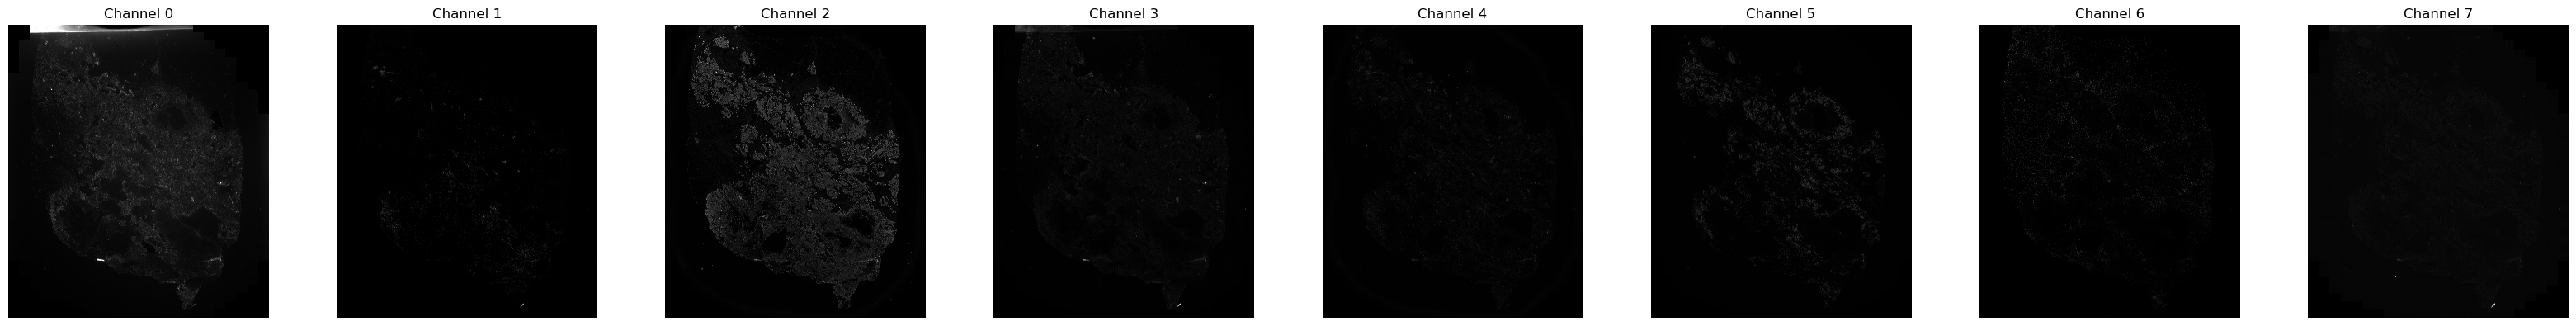

In [ ]:
import tifffile
import matplotlib.pyplot as plt

# Loading the multi-channel TIFF

with tifffile.TiffFile(tiff_path) as tif:tiff_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/multi_channel_markers_BC1_IF1_1140.tiff"
    image = tif.asarray()  # shape: (C, H, W)

# Display each channel
num_channels = image.shape[0]
fig, axes = plt.subplots(1, num_channels, figsize=(4 * num_channels, 4))

for i in range(num_channels):
    ax = axes[i]
    ax.imshow(image[i], cmap='gray')
    ax.set_title(f"Channel {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Creating Mask

In [ ]:
So as a summary of the next steps,I suggest :
 
Creating the tissue-masks for each slides taking :
patch_coordinates located at :
- patch_save_dir = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"1_pre_processing","tissue_extraction_and_patching","patches",f"patch_size_{patch_size}_step_size_{step_size}",f"{slide_id}.h5")
 
- info_image_path = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"0_images_info",f"{slide_id}.csv") -> usefull to immediately get the image height and width to reconstruct the mask.
 
To use a path :
cancer_type = "Breast"
cohort = "BC1" #(should be in ["BC1", "BC2", "BC3", BC1_SYNERGY"])
modality = "IF"
pannel = "IF1" #(should be in ["IF1,"IF2","IF3"])
patch_size = 256
step_size = 256
info_image_path = info_image_path_template
slide_id = "IMMU-BC1-0149-FIXT-01-IF1-01_#_bbd13dc7affec5fc3da9af1f6fb6d041" #Slide_of_your_choice
 
#Example of use : 
path_img_info ='/Users/U1029063/Documents/ts-eu/Theo_Perochon/outputs/processed_data/Breast/BC1/IF/IF1/0_images_info/IMMU-BC1-0149-FIXT-01-IF1-01_#_bbd13dc7affec5fc3da9af1f6fb6d041.csv'
 
image_info = pd.read_csv(path_img_info)
 
coordinate_tissue_patches = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"1_pre_processing","tissue_extraction_and_patching","patches",f"patch_size_{patch_size}_step_size_{step_size}",f"{slide_id}.h5")
 
with h5py.File(coordinate_tissue_patches, "r") as f_coords:
    coords = f_coords['coords'][:] #contains [x,y] coordinates of top-left corner of each tissue patch of size 256
 
 
#Example to create the mask for 1 image :
mask = np.zeros((original_height, original_width), dtype=np.uint8)
for i in range(len(coords)):
    x_beginning = coords[i][0]
    y_beginning = coords[i][1]
    mask[y_beginning:y_beginning+patch_size, x_beginning:x_beginning+patch_size] = 1

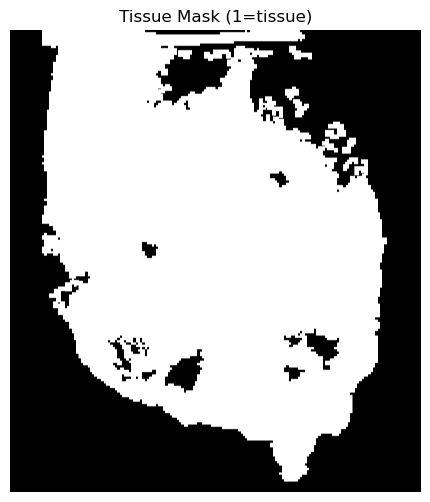

In [2]:
import h5py
import pandas as pd
import os
import numpy as np

cancer_type = "Breast"
cohort = "BC1" #(should be in ["BC1", "BC2", "BC3", BC1_SYNERGY"])
modality = "IF"
pannel = "IF1" #(should be in ["IF1,"IF2","IF3"])
patch_size = 256
step_size = 256
#info_image_path = ""
slide_id = "IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98" #Slide_of_your_choice




patch_save_dir = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"1_pre_processing","tissue_extraction_and_patching","patches",f"patch_size_{patch_size}_step_size_{step_size}",f"{slide_id}.h5")
 
info_image_path = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"0_images_info",f"{slide_id}.csv") # usefull to immediately get the image height and width to reconstruct the mask.

path_img_info ='/root/cloud-data/ts-eu/Theo_Perochon/outputs/processed_data/Breast/BC1/IF/IF1/0_images_info/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.csv'
 
image_info = pd.read_csv(path_img_info)

original_height = int(image_info.loc[0, "original_height"])
original_width  = int(image_info.loc[0, "original_width"])
coordinate_tissue_patches = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"1_pre_processing","tissue_extraction_and_patching","patches",f"patch_size_{patch_size}_step_size_{step_size}",f"{slide_id}.h5")
 
with h5py.File(coordinate_tissue_patches, "r") as f_coords:
    coords = f_coords['coords'][:] #contains [x,y] coordinates of top-left corner of each tissue patch of size 256
    
#Example to create the mask for 1 image :
mask = np.zeros((original_height, original_width), dtype=np.uint8)
for i in range(len(coords)):
    x_beginning = coords[i][0]
    y_beginning = coords[i][1]
    mask[y_beginning:y_beginning+patch_size, x_beginning:x_beginning+patch_size] = 1
    
    
    
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Tissue Mask (1=tissue)")
plt.axis("off")
plt.show()    

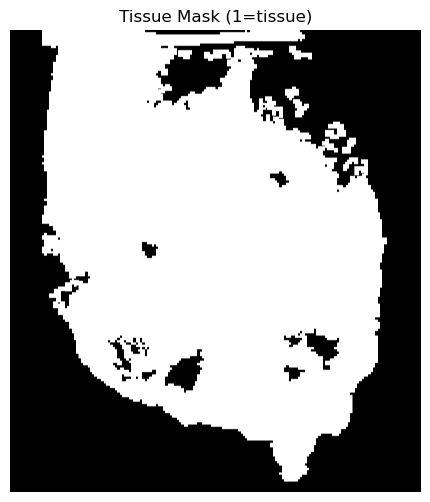

[OK] Mask saved at: /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98_mask.png


In [1]:
from PIL import Image
import os
import h5py
import pandas as pd
import os
import numpy as np

cancer_type = "Breast"
cohort = "BC1" #(should be in ["BC1", "BC2", "BC3", BC1_SYNERGY"])
modality = "IF"
pannel = "IF1" #(should be in ["IF1,"IF2","IF3"])
patch_size = 256
step_size = 256
#info_image_path = ""
slide_id = "IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98" #Slide_of_your_choice


patch_save_dir = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"1_pre_processing","tissue_extraction_and_patching","patches",f"patch_size_{patch_size}_step_size_{step_size}",f"{slide_id}.h5")
 
info_image_path = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"0_images_info",f"{slide_id}.csv") # usefull to immediately get the image height and width to reconstruct the mask.

path_img_info ='/root/cloud-data/ts-eu/Theo_Perochon/outputs/processed_data/Breast/BC1/IF/IF1/0_images_info/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.csv'
 
image_info = pd.read_csv(path_img_info)
original_height = int(image_info.loc[0, "original_height"])
original_width  = int(image_info.loc[0, "original_width"])
coordinate_tissue_patches = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"1_pre_processing","tissue_extraction_and_patching","patches",f"patch_size_{patch_size}_step_size_{step_size}",f"{slide_id}.h5")
 
with h5py.File(coordinate_tissue_patches, "r") as f_coords:
    coords = f_coords['coords'][:] #contains [x,y] coordinates of top-left corner of each tissue patch of size 256
    
#Example to create the mask for 1 image :
mask = np.zeros((original_height, original_width), dtype=np.uint8)
for i in range(len(coords)):
    x_beginning = coords[i][0]
    y_beginning = coords[i][1]
    mask[y_beginning:y_beginning+patch_size, x_beginning:x_beginning+patch_size] = 1
    
    
    
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Tissue Mask (1=tissue)")
plt.axis("off")
plt.show()    
# Path where DeepCellMap expects masks (adjust to your dataset)
out_dir = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks"
os.makedirs(out_dir, exist_ok=True)

# Save as PNG (0/1 mask)
out_path = os.path.join(out_dir, f"{slide_id}_mask.png")
Image.fromarray((mask * 255).astype("uint8")).save(out_path)

print(f"[OK] Mask saved at: {out_path}")

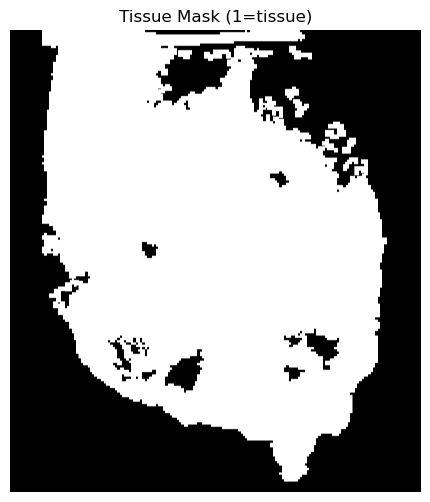

[OK] Saved TIFF at: /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/slide_mask.tif


In [5]:
import tifffile as tiff
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import os
import numpy as np

cancer_type = "Breast"
cohort = "BC1" #(should be in ["BC1", "BC2", "BC3", BC1_SYNERGY"])
modality = "IF"
pannel = "IF1" #(should be in ["IF1,"IF2","IF3"])
patch_size = 256
step_size = 256
#info_image_path = ""
slide_id = "IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98" #Slide_of_your_choice




patch_save_dir = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"1_pre_processing","tissue_extraction_and_patching","patches",f"patch_size_{patch_size}_step_size_{step_size}",f"{slide_id}.h5")
 
info_image_path = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"0_images_info",f"{slide_id}.csv") # usefull to immediately get the image height and width to reconstruct the mask.

path_img_info ='/root/cloud-data/ts-eu/Theo_Perochon/outputs/processed_data/Breast/BC1/IF/IF1/0_images_info/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.csv'
 
image_info = pd.read_csv(path_img_info)

original_height = int(image_info.loc[0, "original_height"])
original_width  = int(image_info.loc[0, "original_width"])
coordinate_tissue_patches = os.path.join("/root/cloud-data/ts-eu/Theo_Perochon/outputs","processed_data",cancer_type,cohort,modality,pannel,"1_pre_processing","tissue_extraction_and_patching","patches",f"patch_size_{patch_size}_step_size_{step_size}",f"{slide_id}.h5")
 
with h5py.File(coordinate_tissue_patches, "r") as f_coords:
    coords = f_coords['coords'][:] #contains [x,y] coordinates of top-left corner of each tissue patch of size 256
    
#Example to create the mask for 1 image :
mask = np.zeros((original_height, original_width), dtype=np.uint8)
for i in range(len(coords)):
    x_beginning = coords[i][0]
    y_beginning = coords[i][1]
    mask[y_beginning:y_beginning+patch_size, x_beginning:x_beginning+patch_size] = 1
    
    
    

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Tissue Mask (1=tissue)")
plt.axis("off")
plt.show()    
# Assume `mask` is your NumPy array (0/1 or labels)
# Example: mask.shape = (original_height, original_width)

# Path where you want to save the TIFF
out_path = Path("/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks") / "slide_mask.tif"

# Save as tiled, compressed TIFF (good for huge images)
tiff.imwrite(
    str(out_path),
    mask.astype(np.uint8),    # or np.uint16 if you have labels >255
    compression="zlib",       # lossless compression
    bigtiff=True,             # required for very large files (>4GB)
    tile=(512, 512),          # enables fast tile-wise reading later
    photometric="minisblack", # grayscale
    metadata=None             # no extra metadata
)

print(f"[OK] Saved TIFF at: {out_path}")

## Creating the mask of the cells

NameError: name 'qptiff_path3' is not defined

## making tile with opencv

In [ ]:
import cv2
import math
# Load the image
image = cv2.imread("path/to/image.jpg") # Replace with your image path
tile_size = (256, 256) # Tile dimensions (width, height)
offset = (256, 256) # Step size for tiling
# Get image dimensions
img_height, img_width = image.shape[:2]
# Loop through the image and create tiles
for i in range(math.ceil(img_height / offset[1])):
   for j in range(math.ceil(img_width / offset[0])):
       # Calculate tile boundaries
       y_start = i * offset[1]
       y_end = min(y_start + tile_size[1], img_height)
       x_start = j * offset[0]
       x_end = min(x_start + tile_size[0], img_width)
       # Extract and save the tile
       tile = image[y_start:y_end, x_start:x_end]
       cv2.imwrite(f"tile_{i}_{j}.jpg", tile)

In [ ]:
#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path) as tif:
    print(len(tif.pages))
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    plt.imshow(image,cmap='gray')
    plt.axis('off')
    plt.show()
    print("image shape:",image.shape)

In [ ]:
#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path2) as tif:
    print(len(tif.pages))
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    plt.imshow(image,cmap='gray')
    plt.axis('off')
    plt.show()
    print("image shape:",image.shape)
    

In [4]:
import cv2
import math

qptiff_path3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.qptiff"
#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path3) as tif:
    print(len(tif.pages))
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    tile_size = (256, 256) # Tile dimensions (width, height)
    offset = (256, 256) # Step size for tiling
    # Get image dimensions
    img_height, img_width = image.shape[:2]
    # Loop through the image and create tiles
    for i in range(math.ceil(img_height / offset[1])):
        for j in range(math.ceil(img_width / offset[0])):
            # Calculate tile boundaries
            y_start = i * offset[1]
            y_end = min(y_start + tile_size[1], img_height)
            x_start = j * offset[0]
            x_end = min(x_start + tile_size[0], img_width)
            # Extract and save the tile
            tile = image[y_start:y_end, x_start:x_end]
            cv2.imwrite(f"tile_{i}_{j}.jpg", tile)   

ModuleNotFoundError: No module named 'cv2'

## Generating CSV 

In [2]:
!python export_tile_grid_csv.py

Traceback (most recent call last):
  File "/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/export_tile_grid_csv.py", line 201, in <module>
    export_tile_grid_csv(
  File "/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/export_tile_grid_csv.py", line 85, in export_tile_grid_csv
    dapi_small = _downscale_dapi(slide_path, dapi_page, scale_factor)
  File "/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/export_tile_grid_csv.py", line 37, in _downscale_dapi
    a = da.from_zarr(z).astype(np.float32)
  File "/cloud-home/U1086086/.magellan/conda/envs/Atlas15/lib/python3.10/site-packages/dask/array/core.py", line 3587, in from_zarr
    import zarr
ModuleNotFoundError: No module named 'zarr'


## Generating Mask of each tiles based on csv and mask of the full image

In [8]:
import os
from pathlib import Path
import re
import numpy as np
import pandas as pd
from PIL import Image
import tifffile as tiff

# Optional speed-ups for huge images
try:
    import dask.array as da
    _HAS_DASK = True
except Exception:
    _HAS_DASK = False

# -----------------------------
# Config (EDIT THESE 3 PATHS)
# -----------------------------
CSV_PATH        = Path("/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/data/NewDataset3/info_data.csv")
FULL_MASK_PATH  = Path("/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/slide_mask.tif")  # or .png
OUT_MASK_DIR    = Path("/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks")

SLIDE_NAME          = "001"   # for naming
ONLY_TISSUE_TILES   = True    # skip NONE tiles
OUTPUT_FORMAT       = "png"   # "png" or "tiff"
MASK_IS_BINARY      = False   # set True if your mask is 0/1; the code will instance-label per tile
RELABEL_PER_TILE    = False   # set True if you want tile labels compacted to 1..N (uses connected components)

# -----------------------------
# Helpers
# -----------------------------
def _read_tile_table(csv_path: Path) -> pd.DataFrame:
    """
    Your CSV has a preamble then a header row 'Tile Num,...'.
    This function finds that header line and reads the table from there.
    """
    with open(csv_path, "r") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("Tile Num,Row,Column,"):
            header_idx = i
            break
    if header_idx is None:
        raise RuntimeError("Could not find data header line starting with 'Tile Num,Row,Column,'")

    from io import StringIO
    data = "".join(lines[header_idx:])
    df = pd.read_csv(StringIO(data))

    # Expected columns (subset):
    # Tile Num, Row, Column, Tissue %, Tissue Quantity,
    # Original Col Start,Original Row Start,Original Col End,Original Row End,Original Col Size,Original Row Size
    needed = ["Row", "Column", "Tissue Quantity",
              "Original Col Start","Original Row Start","Original Col End","Original Row End",
              "Original Col Size","Original Row Size"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in CSV: {missing}")
    return df

def _lazy_open_mask(mask_path: Path):
    """
    Returns an object with .shape and supports numpy-style slicing [y0:y1, x0:x1] without
    forcing full read when possible (TIFF + zarr). Falls back to full read otherwise.
    """
    ext = mask_path.suffix.lower()
    if ext in [".tif", ".tiff"]:
        tf = tiff.TiffFile(str(mask_path))
        page = tf.pages[0]
        try:
            z = page.aszarr()
            if _HAS_DASK:
                arr = da.from_zarr(z)  # dask array (lazy)
            else:
                arr = z  # zarr array (lazy reads via tifffile/imagecodecs)
            return tf, arr, True  # keep file handle open
        except Exception:
            # Fallback: full read to numpy
            arr = page.asarray()
            tf.close()
            return None, arr, False
    else:
        # PNG or others: full read with PIL to numpy (PNG reader usually loads entire image)
        im = Image.open(str(mask_path))
        arr = np.array(im)
        return None, arr, False

def _save_tile(path: Path, tile_arr: np.ndarray, fmt: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    if fmt.lower() == "png":
        # Ensure uint16 for label masks (PNG supports 16-bit gray)
        a = tile_arr.astype(np.uint16, copy=False)
        Image.fromarray(a, mode=None if a.dtype != np.uint16 else "I;16").save(str(path))
    elif fmt.lower() in ("tif", "tiff"):
        tiff.imwrite(str(path), tile_arr, dtype=tile_arr.dtype)
    else:
        raise ValueError(f"Unsupported OUTPUT_FORMAT: {fmt}")

def _ensure_label_dtype(arr: np.ndarray) -> np.ndarray:
    """Force integer label dtype (uint16) for masks."""
    if not np.issubdtype(arr.dtype, np.integer):
        # If it's binary float (0.0/1.0) or similar, cast to uint16
        arr = arr.astype(np.uint16)
    # Clip to 16-bit range if needed
    if arr.max() > np.iinfo(np.uint16).max:
        raise ValueError("Labels exceed uint16 range; consider saving as TIFF with uint32.")
    return arr.astype(np.uint16, copy=False)

def _label_if_binary(arr: np.ndarray) -> np.ndarray:
    """Connected components labeling if your mask is binary (0/1)."""
    from skimage.measure import label
    return label(arr > 0).astype(np.uint16)

def _relabel_sequential(arr: np.ndarray) -> np.ndarray:
    """Relabel to 1..N within a tile (useful if you want compact IDs per tile)."""
    from skimage.segmentation import relabel_sequential
    relabeled, fw, inv = relabel_sequential(arr)
    return relabeled.astype(np.uint16)

# -----------------------------
# Main
# -----------------------------
def export_per_tile_masks(csv_path: Path,
                          full_mask_path: Path,
                          out_dir: Path,
                          slide_name: str = "001",
                          only_tissue_tiles: bool = True,
                          output_format: str = "png",
                          mask_is_binary: bool = False,
                          relabel_per_tile: bool = False,
                          preview_n: int = 5):
    df = _read_tile_table(csv_path)

    # Open the mask lazily if possible
    tf, M, is_lazy = _lazy_open_mask(full_mask_path)

    # Resolve shape safely
    if _HAS_DASK and isinstance(M, da.Array):
        H, W = M.shape
    else:
        H, W = M.shape[:2]

    print(f"[INFO] Full mask shape: {W}x{H} (W×H)")

    # Sanity: CSV bounds should fit inside mask dimensions
    max_x1 = int(df["Original Col End"].max())
    max_y1 = int(df["Original Row End"].max())
    if max_x1 > W or max_y1 > H:
        raise ValueError(f"CSV coordinates exceed mask size: need at least {max_x1}x{max_y1}, got {W}x{H}")

    n_total = len(df)
    if only_tissue_tiles:
        df = df[df["Tissue Quantity"] != "NONE"].copy()
    n_to_write = len(df)
    print(f"[INFO] Tiles to write: {n_to_write} / {n_total} ({'non-empty only' if only_tissue_tiles else 'all tiles'})")

    out_dir.mkdir(parents=True, exist_ok=True)

    # Iterate rows and crop
    written = 0
    for idx, row in df.iterrows():
        r = int(row["Row"])
        c = int(row["Column"])

        x0 = int(row["Original Col Start"])
        y0 = int(row["Original Row Start"])
        x1 = int(row["Original Col End"])
        y1 = int(row["Original Row End"])

        # Slice without loading whole array when possible
        if _HAS_DASK and isinstance(M, da.Array):
            tile = M[y0:y1, x0:x1].compute()
        else:
            tile = M[y0:y1, x0:x1]

        # If mask is RGB accidentally, convert to single channel
        if tile.ndim == 3:
            # keep first channel (assuming labels stored in one channel)
            tile = tile[..., 0]

        # Prepare labels
        tile = _ensure_label_dtype(tile)
        if mask_is_binary:
            tile = _label_if_binary(tile)
        if relabel_per_tile:
            tile = _relabel_sequential(tile)

        # Naming: 001-tile-r003-c005-mask.png
        out_name = f"{slide_name}-tile-r{r:03d}-c{c:03d}-mask.{ 'tif' if output_format.lower()=='tiff' else 'png'}"
        out_path = out_dir / out_name

        _save_tile(out_path, tile, output_format)
        written += 1

        if written <= preview_n:
            print(f"  -> {out_path.name}: shape={tile.shape}, dtype={tile.dtype}, labels>0={int((tile>0).sum())}")

    if tf is not None and is_lazy:
        tf.close()

    print(f"[OK] Wrote {written} tile mask(s) to: {out_dir}")

if __name__ == "__main__":
    export_per_tile_masks(
        csv_path=CSV_PATH,
        full_mask_path=FULL_MASK_PATH,
        out_dir=OUT_MASK_DIR,
        slide_name=SLIDE_NAME,
        only_tissue_tiles=ONLY_TISSUE_TILES,
        output_format=OUTPUT_FORMAT,
        mask_is_binary=MASK_IS_BINARY,
        relabel_per_tile=RELABEL_PER_TILE,
        preview_n=8
    )

[INFO] Full mask shape: 46080x51840 (W×H)
[INFO] Tiles to write: 809 / 2295 (non-empty only)
  -> 001-tile-r000-c003-mask.png: shape=(1024, 1024), dtype=uint16, labels>0=524288
  -> 001-tile-r000-c004-mask.png: shape=(1024, 1024), dtype=uint16, labels>0=1048576
  -> 001-tile-r000-c005-mask.png: shape=(1024, 1024), dtype=uint16, labels>0=1048576
  -> 001-tile-r000-c006-mask.png: shape=(1024, 1024), dtype=uint16, labels>0=1048576
  -> 001-tile-r000-c007-mask.png: shape=(1024, 1024), dtype=uint16, labels>0=1048576
  -> 001-tile-r000-c008-mask.png: shape=(1024, 1024), dtype=uint16, labels>0=1048576
  -> 001-tile-r000-c009-mask.png: shape=(1024, 1024), dtype=uint16, labels>0=1048576
  -> 001-tile-r000-c010-mask.png: shape=(1024, 1024), dtype=uint16, labels>0=1048576
[OK] Wrote 809 tile mask(s) to: /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks


In [9]:
from PIL import Image
import numpy as np, os

p = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks/001-tile-r000-c004-mask.png"
arr = np.array(Image.open(p))
print(arr.dtype, np.unique(arr)[:5], arr.min(), arr.max())  # expect uint16 and values {0,1}
print("Foreground pixels:", (arr>0).sum())                  # should be > 0

uint16 [1] 1 1
Foreground pixels: 1048576


In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

masks_dir = Path("/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks")
out_vis   = masks_dir / "vis"
out_vis.mkdir(exist_ok=True)

for p in masks_dir.glob("*-mask.png"):
    arr = np.array(Image.open(p))
    # binary -> 8-bit for viewing
    vis = (arr > 0).astype(np.uint8) * 255
    Image.fromarray(vis, mode="L").save(out_vis / p.name.replace("-mask", "-mask-vis"))

print("[OK] Wrote visualization PNGs to:", out_vis)

In [10]:
from pathlib import Path
from PIL import Image
import numpy as np

masks_dir = Path("/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks")
vis_dir = masks_dir / "vis"
vis_dir.mkdir(exist_ok=True)

for p in masks_dir.glob("*-mask.png"):
    arr = np.array(Image.open(p))           # uint16 with values 0/1
    vis = (arr > 0).astype(np.uint8) * 255  # 0/255 for display
    Image.fromarray(vis, mode="L").save(vis_dir / p.name.replace("-mask", "-mask-vis"))

print(f"[OK] Wrote viewer-friendly copies to: {vis_dir}")

[OK] Wrote viewer-friendly copies to: /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks/vis


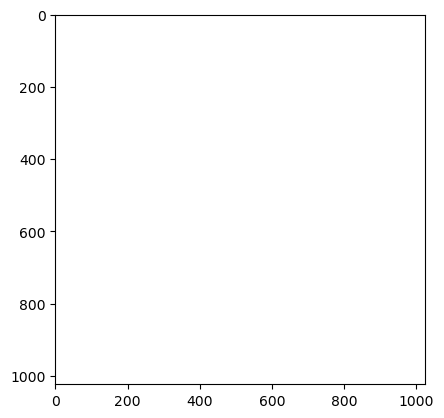

In [11]:
import matplotlib.pyplot as plt
plt.imshow(arr, cmap="gray", vmin=0, vmax=1)  # arr is 0/1
plt.show()


In [12]:
from pathlib import Path
from PIL import Image
import numpy as np

masks_dir = Path("/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks")

n_all0 = n_all1 = n_mixed = 0
examples = {"all0": None, "all1": None, "mixed": None}

for p in sorted(masks_dir.glob("*-mask.png")):
    a = np.array(Image.open(p))
    vals = np.unique(a)
    if len(vals) == 1 and vals[0] == 0:
        n_all0 += 1
        examples["all0"] = examples["all0"] or p
    elif len(vals) == 1 and vals[0] > 0:
        n_all1 += 1
        examples["all1"] = examples["all1"] or p
    else:
        n_mixed += 1
        examples["mixed"] = examples["mixed"] or p

print(f"all-black(0): {n_all0}  |  all-white(>0): {n_all1}  |  mixed: {n_mixed}")
print("examples:", examples)

all-black(0): 2  |  all-white(>0): 734  |  mixed: 73
examples: {'all0': PosixPath('/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks/001-tile-r005-c027-mask.png'), 'all1': PosixPath('/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks/001-tile-r000-c004-mask.png'), 'mixed': PosixPath('/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/001/masks/001-tile-r000-c003-mask.png')}


In [2]:
import os, math, re, json
import pandas as pd
from tifffile import TiffFile

# ==========
# CONFIG
# ==========
class DatasetConfig:
    def __init__(self,
                 dir_dataset,
                 data_format="qptiff",
                 dataset_name="ImmuCan_IF1",
                 tile_height=512,
                 tile_width=512,
                 conversion_px_micro_meter=(0.5, 0.5),  # fallback if TIFF tags missing
                 mapping_img_name=None):
        self.dir_dataset = dir_dataset
        self.data_format = data_format
        self.dataset_name = dataset_name
        self.tile_height = tile_height
        self.tile_width = tile_width
        self.conversion_px_micro_meter = conversion_px_micro_meter
        self.mapping_img_name = mapping_img_name or []


# ==========
# PANEL DEFINITIONS (from your message)
# ==========
IF1_PANEL = [
    {"idx":0, "marker":"DAPI",  "filter":"DAPI"},
    {"idx":1, "marker":"CD15",  "filter":"OPAL 570"},
    {"idx":2, "marker":"CK",    "filter":"OPAL 690"},
    {"idx":3, "marker":"CD3",   "filter":"OPAL 480"},
    {"idx":4, "marker":"CD11c", "filter":"OPAL 620"},
    {"idx":5, "marker":"CD20",  "filter":"OPAL 780"},
    {"idx":6, "marker":"CD163", "filter":"OPAL 520"},
    {"idx":7, "marker":"AF",    "filter":"AUTOFLUO"},
]

IF1_OLD_PANEL = [
    {"idx":0, "marker":"DAPI",  "filter":"DAPI"},
    {"idx":1, "marker":"CD15",  "filter":"OPAL 570"},
    {"idx":2, "marker":"CK",    "filter":"OPAL 690"},
    {"idx":3, "marker":"CD163", "filter":"OPAL 480"},  # swapped
    {"idx":4, "marker":"CD11c", "filter":"OPAL 620"},
    {"idx":5, "marker":"CD20",  "filter":"OPAL 780"},
    {"idx":6, "marker":"CD3",   "filter":"OPAL 520"},  # swapped
    {"idx":7, "marker":"AF",    "filter":"AUTOFLUO"},
]

# Paste your IF1_old samples here (I included all you provided; you can add/remove as needed)
IF1_OLD_SAMPLE_IDS = {
    "IMMU-NSCLC-0075-FIXT-01-IF1-02","IMMU-NSCLC-0077-FIXT-01-IF1-02","IMMU-RCC-0084-FIXT-01-IF1-02",
    "IMMU-RCC-0085-FIXT-01-IF1-02","IMMU-NSCLC-0080-FIXT-01-IF1-02","IMMU-NSCLC-0092-FIXT-01-IF1-02",
    "IMMU-NSCLC-0091-FIXT-01-IF1-02","IMMU-NSCLC-0079-FIXT-01-IF1-02","IMMU-NSCLC-0095-FIXT-01-IF1-02",
    "IMMU-NSCLC-0076-FIXT-01-IF1-02","IMMU-SCCHN1-0078-FIXT-01-IF1-02","IMMU-NSCLC-0089-FIXT-01-IF1-02",
    "IMMU-NSCLC-0090-FIXT-01-IF1-02","IMMU-NSCLC-0125-FIXT-01-IF1-01","IMMU-NSCLC-0141-FIXT-01-IF1-01",
    "IMMU-NSCLC-0115-FIXT-01-IF1-01","IMMU-NSCLC-0129-FIXT-01-IF1-01","IMMU-NSCLC-0127-FIXT-01-IF1-01",
    "IMMU-NSCLC-0094-FIXT-01-IF1-01","IMMU-NSCLC-0106-FIXT-01-IF1-01","IMMU-NSCLC-0108-FIXT-01-IF1-01",
    "IMMU-NSCLC-0103-FIXT-01-IF1-01","IMMU-NSCLC-0102-FIXT-01-IF1-01","IMMU-NSCLC-0107-FIXT-01-IF1-01",
    "IMMU-NSCLC-0105-FIXT-01-IF1-01","IMMU-NSCLC-0097-FIXT-02-IF1-01","IMMU-NSCLC-0096-FIXT-02-IF1-01",
    "IMMU-NSCLC-0128-FIXT-01-IF1-01","IMMU-BC3-0152-FIXT-01-IF1-01","IMMU-BC2-0183-FIXT-01-IF1-01",
    "IMMU-BC2-0167-FIXT-01-IF1-01","IMMU-NSCLC-0100-FIXT-01-IF1-01","IMMU-BC3-0174-FIXT-01-IF1-01",
    "IMMU-BC3-0154-FIXT-01-IF1-01","IMMU-BC2-0166-FIXT-01-IF1-01","IMMU-BC2-0118-FIXT-01-IF1-01",
    "IMMU-BC3-0098-FIXT-01-IF1-01","IMMU-BC3-0101-FIXT-01-IF1-01","IMMU-BC2-0132-FIXT-01-IF1-01",
    "IMMU-BC3-0119-FIXT-01-IF1-01","IMMU-BC3-0098-FIXT-02-IF1-01","IMMU-BC3-0147-FIXT-01-IF1-01",
    "IMMU-BC3-0165-FIXT-01-IF1-01","IMMU-BC3-0124-FIXT-01-IF1-01","IMMU-BC3-0126-FIXT-01-IF1-01",
    "IMMU-BC3-0109-FIXT-01-IF1-01","IMMU-BC3-0111-FIXT-01-IF1-01","IMMU-BC2-0163-FIXT-01-IF1-01",
    "IMMU-BC3-0114-FIXT-01-IF1-01","IMMU-SCCHN1-0144-FIXT-01-IF1-01","IMMU-SCCHN1-0117-FIXT-01-IF1-01",
    "IMMU-SCCHN1-0112-FIXT-01-IF1-01","IMMU-SCCHN1-0137-FIXT-01-IF1-01","IMMU-BC1-0164-FIXT-01-IF1-01",
    "IMMU-BC2-0159-FIXT-02-IF1-01","IMMU-BC3-0138-FIXT-01-IF1-01","IMMU-BC3-0168-FIXT-01-IF1-01",
    "IMMU-BC2-0151-FIXT-01-IF1-01","IMMU-BC3-0173-FIXT-01-IF1-01","IMMU-BC3-0099-FIXT-01-IF1-01",
    "IMMU-BC2-0172-FIXT-01-IF1-01","IMMU-BC3-0120-FIXT-01-IF1-01","IMMU-BC2-0140-FIXT-01-IF1-01",
    "IMMU-BC3-0171-FIXT-01-IF1-01","IMMU-BC3-0113-FIXT-02-IF1-01","IMMU-NSCLC-0153-FIXT-01-IF1-01",
    "IMMU-NSCLC-0162-FIXT-01-IF1-01","IMMU-NSCLC-0136-FIXT-01-IF1-01","IMMU-NSCLC-0170-FIXT-01-IF1-01",
    "IMMU-NSCLC-0146-FIXT-01-IF1-01",
    # You can add the remaining IDs if needed
}

# ==========
# HELPERS
# ==========
def _extract_from_description(desc):
    """Parse marker name and filter (Opal) from ImageDescription text."""
    if not desc:
        return (None, None)
    s = str(desc)

    # Marker name candidates
    marker_guess = None
    for pat in [
        r'Channel(?:\s*Name)?\s*[:=]\s*([^\r\n;|]+)',
        r'PIM_CName\s*=\s*([^\r\n;|]+)',
        r'ChannelName\s*=\s*([^\r\n;|]+)',
        r'Stain\s*[:=]\s*([^\r\n;|]+)',
    ]:
        m = re.search(pat, s, flags=re.IGNORECASE)
        if m:
            marker_guess = m.group(1).strip()
            break
    if not marker_guess:
        m = re.search(r'(DAPI|Autofluo|Autofluorescence|AF)', s, flags=re.IGNORECASE)
        marker_guess = m.group(0).strip() if m else None

    # Filter (Opal)
    filter_guess = None
    for pat in [r'(OPAL\s*\d{3})', r'(OPAL\d{3})', r'(AUTOFLUO)', r'(DAPI)']:
        m = re.search(pat, s, flags=re.IGNORECASE)
        if m:
            filter_guess = m.group(1).upper().replace("  ", " ")
            filter_guess = re.sub(r'OPAL\s*(\d{3})', r'OPAL \1', filter_guess)
            break

    # Normalize markers to your set
    if marker_guess:
        mg = marker_guess.upper().replace(" ", "")
        if "DAPI" in mg: marker_guess = "DAPI"
        elif "CD15" in mg: marker_guess = "CD15"
        elif mg == "CK" or "CYTOKERATIN" in mg: marker_guess = "CK"
        elif "CD3" in mg: marker_guess = "CD3"
        elif "CD11C" in mg: marker_guess = "CD11c"
        elif "CD20" in mg: marker_guess = "CD20"
        elif "CD163" in mg: marker_guess = "CD163"
        elif "AUTO" in mg or mg == "AF": marker_guess = "AF"

    return (marker_guess, filter_guess)

def get_qptiff_channels_meta(path, min_area=1_000_000, max_series=24):
    """
    Lightweight scan of QPTIFF to collect per-channel meta (no pixel reads).
    Returns:
      channels_meta: list of dicts with marker/filter guesses and geometry
      base: dict(height, width, tile_h, tile_w)
    """
    channels_meta = []
    base = dict(height=None, width=None, tile_h=None, tile_w=None)

    with TiffFile(path) as tf:
        candidates = []
        for s_idx, s in enumerate(tf.series):
            lvl0 = s.levels[0] if getattr(s, "levels", None) else s
            shp = getattr(lvl0, "shape", None)
            if not shp or len(shp) < 2:
                continue
            h, w = int(shp[0]), int(shp[1])
            area = h * w
            page0 = lvl0.pages[0]

            # SamplesPerPixel (spp==1 -> grayscale channel planes)
            spp = getattr(page0, "samplesperpixel", None)
            if spp is None and 'SamplesPerPixel' in page0.tags:
                spp = page0.tags['SamplesPerPixel'].value

            if spp == 1 and area >= min_area:
                candidates.append((s_idx, lvl0, page0, area))

        # Fallback: take largest series if none matched
        if not candidates and tf.series:
            tmp = []
            for s_idx, s in enumerate(tf.series):
                lvl0 = s.levels[0] if getattr(s, "levels", None) else s
                shp = getattr(lvl0, "shape", None)
                if shp and len(shp) >= 2:
                    h, w = int(shp[0]), int(shp[1])
                    tmp.append((s_idx, lvl0, lvl0.pages[0], h*w))
            tmp.sort(key=lambda t: t[3], reverse=True)
            candidates = tmp[:max_series]

        # Sort largest-first
        candidates.sort(key=lambda t: t[3], reverse=True)

        # Base geometry from largest candidate
        if candidates:
            s_idx0, lvl0, page0, _ = candidates[0]
            h0, w0 = int(lvl0.shape[0]), int(lvl0.shape[1])
            tile_h = getattr(page0, 'tilelength', None) or page0.tags.get('TileLength', None)
            tile_w = getattr(page0, 'tilewidth', None)  or page0.tags.get('TileWidth', None)
            tile_h = int(tile_h.value if hasattr(tile_h, 'value') else tile_h) if tile_h else h0
            tile_w = int(tile_w.value if hasattr(tile_w, 'value') else tile_w) if tile_w else w0
            base.update(height=h0, width=w0, tile_h=tile_h, tile_w=tile_w)

        # Collect channel metadata
        for s_idx, lvl0, page0, _ in candidates:
            desc = getattr(page0, 'description', None)
            if desc is None and 'ImageDescription' in page0.tags:
                desc = page0.tags['ImageDescription'].value
            marker_guess, filter_guess = _extract_from_description(desc)
            channels_meta.append(dict(
                series_index=s_idx,
                height=int(lvl0.shape[0]),
                width=int(lvl0.shape[1]),
                marker_guess=marker_guess,
                filter_guess=filter_guess,
                description_preview=str(desc)[:400] if desc else None
            ))

    return channels_meta, base

def decide_panel_version(sample_id, channels_meta):
    """Use your provided list first; else infer by OPAL 480 mapping."""
    if sample_id and sample_id in IF1_OLD_SAMPLE_IDS:
        return "IF1_old"
    opal480_markers = {c['marker_guess'] for c in channels_meta if (c['filter_guess'] or '').upper() == 'OPAL 480'}
    if 'CD163' in opal480_markers and 'CD3' not in opal480_markers:
        return "IF1_old"
    return "IF1"

def build_marker_channel_map(channels_meta, panel_version):
    """
    Return:
      - canonical_markers: list[str] in canonical order
      - marker_to_series: dict marker -> series_index
      - missing: list[str] markers not found
    """
    panel = IF1_PANEL if panel_version == "IF1" else IF1_OLD_PANEL
    canonical_markers = [p["marker"] for p in panel]

    by_filter = {}
    by_marker = {}
    for c in channels_meta:
        if c['filter_guess']:
            by_filter[c['filter_guess'].upper()] = c['series_index']
        if c['marker_guess']:
            by_marker[c['marker_guess']] = c['series_index']

    expected_filter = {p["marker"]: p["filter"].upper() for p in panel}

    marker_to_series = {}
    missing = []
    for m in canonical_markers:
        f = expected_filter[m]
        if f in by_filter:
            marker_to_series[m] = by_filter[f]
        elif m in by_marker:
            marker_to_series[m] = by_marker[m]
        else:
            missing.append(m)

    return canonical_markers, marker_to_series, missing


# ==========
# MAIN FUNCTION (compatible with your notebook5 schema)
# ==========
def get_info_data(dataset_config, image_list=None, from_image=None, to_image=None):
    """
    QPTIFF-aware info builder. Produces info_data.csv in dir_dataset with columns:
      dataset_name, slide_num, slide_name, slide_path, slide_type,
      slide_shape, slide_height, slide_width, area_slide,
      row_tile_size, col_tile_size,
      n_tiles_row_slide, n_tiles_col_slide, slide_shape_in_tile, n_tiles_slide,
      pixel_resolution, channels, slide_size, slide_dtype, slide_min, slide_max

    NOTE: 'channels' is a Python list in the DataFrame (will be stringified in CSV).
    """
    if image_list is None:
        if from_image is None or to_image is None:
            raise ValueError("Provide image_list or from_image/to_image")
        image_list = list(range(from_image, to_image + 1))

    rows = []

    for item in image_list:
        # Resolve filename & slide name
        if isinstance(item, int):
            padded = str(item).zfill(3)
            filename = f"{padded}.{dataset_config.data_format}"
            slide_name = (dataset_config.mapping_img_name[item - 1]
                          if dataset_config.mapping_img_name and len(dataset_config.mapping_img_name) >= item
                          else padded)
            slide_num = int(padded)
        else:
            filename = str(item)
            slide_name = os.path.splitext(os.path.basename(filename))[0]
            slide_num = None

        slide_path = os.path.join(dataset_config.dir_dataset, filename)
        if not os.path.exists(slide_path):
            # Try alternate extensions for QPTIFF
            base = os.path.splitext(slide_path)[0]
            tried = []
            found = None
            for ext in [".qptiff", ".qptif", ".tif", ".tiff", f".{dataset_config.data_format}"]:
                cand = base + ext
                tried.append(cand)
                if os.path.exists(cand):
                    found = cand
                    break
            if not found:
                raise FileNotFoundError(f"Slide not found. Tried: {tried}")
            slide_path = found
            filename = os.path.basename(found)
            slide_name = os.path.splitext(filename)[0]

        # Only need QPTIFF branch for your case
        fmt = dataset_config.data_format.lower()
        if fmt not in {"qptiff", "qptif", "tif", "tiff"}:
            raise ValueError("This script is prepared for QPTIFF/TIFF. Set data_format accordingly.")

        # --- QPTIFF metadata-only scan ---
        channels_meta, base = get_qptiff_channels_meta(slide_path)
        if base["height"] is None or base["width"] is None:
            raise RuntimeError(f"Could not determine dimensions for {slide_path}")

        h, w = int(base["height"]), int(base["width"])
        tile_h = int(base["tile_h"]) if base["tile_h"] else dataset_config.tile_height
        tile_w = int(base["tile_w"]) if base["tile_w"] else dataset_config.tile_width

        # Decide panel and build canonical channel mapping
        sample_id = slide_name  # your files use sampleId as filename stem
        panel_version = decide_panel_version(sample_id, channels_meta)
        canonical_markers, marker_to_series, missing = build_marker_channel_map(channels_meta, panel_version)

        # Build row (match your notebook5 schema)
        row = dict()
        row["dataset_name"] = dataset_config.dataset_name
        row["slide_num"] = slide_num
        row["slide_name"] = slide_name
        row["slide_path"] = slide_path
        row["slide_type"] = dataset_config.data_format
        row["slide_shape"] = (h, w)                   # tuple (H, W)
        row["slide_height"] = h
        row["slide_width"] = w
        row["area_slide"] = h * w
        row["row_tile_size"] = tile_h
        row["col_tile_size"] = tile_w
        row["n_tiles_row_slide"] = math.ceil(h / tile_h)
        row["n_tiles_col_slide"] = math.ceil(w / tile_w)
        row["slide_shape_in_tile"] = (row["n_tiles_row_slide"], row["n_tiles_col_slide"])
        row["n_tiles_slide"] = row["n_tiles_row_slide"] * row["n_tiles_col_slide"]

        # Resolution: keep your config fallback (can be refined to read X/YResolution tags)
        row["pixel_resolution"] = dataset_config.conversion_px_micro_meter

        # Channels: canonical order list (DAPI, CD15, CK, CD3, CD11c, CD20, CD163, AF)
        row["channels"] = canonical_markers

        # Size & dtype
        row["slide_size"] = os.path.getsize(slide_path)  # bytes
        row["slide_dtype"] = "uint16"                    # typical for QPTIFF
        row["slide_min"] = None                          # not scanning image
        row["slide_max"] = None

        # (Optional, but not required by notebook5): keep useful extras for later
        row["panel_version"] = panel_version
        row["marker_to_series_json"] = json.dumps(marker_to_series)
        row["channels_meta_json"] = json.dumps(channels_meta)
        row["missing_channels"] = ",".join(missing) if missing else ""

        rows.append(row)

    df = pd.DataFrame(rows)

    # Append/merge with existing CSV (exactly like your original code)
    out_csv = os.path.join(dataset_config.dir_dataset, "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/data/NewDataset3/info_data.csv")
    if os.path.exists(out_csv):
        try:
            df_old = pd.read_csv(out_csv, sep=";")
            df = pd.concat([df_old, df], ignore_index=True)
        except Exception:
            pass
    df.to_csv(out_csv, sep=";", index=False)
    print(f"Saved: {out_csv}")
    return df


# ==========
# EXAMPLE RUN
# ==========
if __name__ == "__main__":
# 1) Point to your actual folder
    DIR_DATASET = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/data/NewDataset3"

    cfg = DatasetConfig(
        dir_dataset=DIR_DATASET,
        data_format="qptiff",
        dataset_name="NewDataset3",
        tile_height=512,
        tile_width=512,
        conversion_px_micro_meter=(0.5, 0.5)  # fallback if TIFF tags missing
    )

    # 2A) Using the exact filename:
    df = get_info_data(cfg, image_list=["001.qptiff"])

    # 2B) Or if your files follow 001.qptiff, 002.qptiff, ... you can pass integers:
    # df = get_info_data(cfg, image_list=[1])  # -> will look for 001.qptiff

    print(df.head(2))
    print("Saved CSV at:", os.path.join(DIR_DATASET, "info_data.csv"))


Saved: /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/data/NewDataset3/info_data.csv
  dataset_name slide_num slide_name  \
0  NewDataset3      None        001   

                                          slide_path slide_type   slide_shape  \
0  /root/cloud-data/eu-ngs/U1086086/Test2/DeepCel...     qptiff  (4016, 2080)   

   slide_height  slide_width  area_slide  row_tile_size  ...  \
0          4016         2080     8353280           4016  ...   

   pixel_resolution                                       channels  \
0        (0.5, 0.5)  [DAPI, CD15, CK, CD3, CD11c, CD20, CD163, AF]   

   slide_size slide_dtype  slide_min slide_max panel_version  \
0  6633562027      uint16       None      None           IF1   

    marker_to_series_json                                 channels_meta_json  \
0  {"DAPI": 0, "CD15": 0}  [{"series_index": 2, "height": 4016, "width": ...   

             missing_channels  
0  CK,CD3,CD11c,CD20,CD163,AF  

[1 rows x 25 columns]
Saved CSV at: /root/cl

In [6]:
import pandas as pd

csv_path = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/data/NewDataset3/info_data_1.csv"  # <-- replace with your CSV path

# Load the CSV
df = pd.read_csv(csv_path)

# Compute rows and cols (robust even if tiles don't start at 0)
n_rows = int(df["tile_row"].max() - df["tile_row"].min() + 1)
n_cols = int(df["tile_col"].max() - df["tile_col"].min() + 1)

# Fill the column
df["slide_shape_in_tile"] = f"({n_rows}, {n_cols})"

# Save back
df.to_csv(csv_path, index=False)
print(f"Updated slide_shape_in_tile with ({n_rows}, {n_cols}) in {csv_path}")

ParserError: Error tokenizing data. C error: Expected 1 fields in line 8, saw 2


## Concatenating 2 excels : one with cell type you had generated before and another one the new excel with pixel values from the concersium

In [17]:
import pandas as pd

data1 = pd.read_csv('/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv')
import pandas as pd

# Load TSV files
df2 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv", sep="\t")
df1 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz", sep="\t" , compression="gzip")

# Concatenate
combined = pd.concat([df1, df2], ignore_index=True)

# Save back to TSV
combined.to_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/combined.tsv", sep="\t", index=False)

In [8]:
import os
print(os.getcwd())  # shows the current working directory

/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension


In [10]:
df2.head()

,cell.ID,nucleus.x,nucleus.y,CD15.score,CK.score,CD3.score,CD11c.score,CD20.score,CD163.score,CD15.score.normalized,...,CD3.score.normalized,CD11c.score.normalized,CD20.score.normalized,CD163.score.normalized,tissue.type,phenotype,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,phenotype_norm,cell_type
0,29,7384.2,35592.2,0.539248,0.552555,4.641662,0.219289,0.145625,1.320323,0.1257,...,0.7310,0.0877,0.0725,0.2780,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other
1,30,7451.2,35336.1,0.353247,2.370034,3.194412,0.286839,0.408582,1.256250,0.0823,...,0.5031,0.1147,0.2033,0.2645,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,False,True,CD15--CK+-CD3--CD11C--CD20--CD163-,Tumor
2,31,7753.8,35234.9,3.872318,1.262634,2.450958,1.230235,0.259747,79.320935,0.9026,...,0.3860,0.4921,0.1292,16.6991,stroma,CD15-CK-CD3-CD11c-CD20-CD163+,False,True,CD15--CK--CD3--CD11C--CD20--CD163+,MacCD163
3,32,7504.7,35511.8,0.891661,0.468967,2.158099,0.508292,0.204084,2.232118,0.2078,...,0.3399,0.2033,0.1015,0.4699,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other
4,33,7628.8,35738.5,0.378430,0.394962,3.288753,0.196775,0.161664,0.886713,0.0882,...,0.5179,0.0787,0.0804,0.1867,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other


In [13]:
df3 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/combined.tsv" , sep="\t")
df3.head()

/tmp/ipykernel_16203/332561723.py:1: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/combined.tsv" , sep="\t")


,cell.ID,nucleus.x,nucleus.y,CD15.score,CK.score,CD3.score,CD11c.score,CD20.score,CD163.score,CD15.score.normalized,...,CD163.score.normalized,tissue.type,phenotype,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,phenotype_norm,cell_type,nucleus.x.px,nucleus.y.px,cell.area.px
0,29,7384.2,35592.2,0.539248,0.552555,4.641662,0.219289,0.145625,1.320323,0.1257,...,0.2780,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other,NaN,NaN,NaN
1,30,7451.2,35336.1,0.353247,2.370034,3.194412,0.286839,0.408582,1.256250,0.0823,...,0.2645,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,False,True,CD15--CK+-CD3--CD11C--CD20--CD163-,Tumor,NaN,NaN,NaN
2,31,7753.8,35234.9,3.872318,1.262634,2.450958,1.230235,0.259747,79.320935,0.9026,...,16.6991,stroma,CD15-CK-CD3-CD11c-CD20-CD163+,False,True,CD15--CK--CD3--CD11C--CD20--CD163+,MacCD163,NaN,NaN,NaN
3,32,7504.7,35511.8,0.891661,0.468967,2.158099,0.508292,0.204084,2.232118,0.2078,...,0.4699,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other,NaN,NaN,NaN
4,33,7628.8,35738.5,0.378430,0.394962,3.288753,0.196775,0.161664,0.886713,0.0882,...,0.1867,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other,NaN,NaN,NaN


In [16]:
import pandas as pd

file1 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv"
file2 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz"

df1 = pd.read_csv(file1, sep="\t")
df2 = pd.read_csv(file2, sep="\t", compression="gzip")  # or compression="gzip"

print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("columns equal (order & names)?", list(df1.columns) == list(df2.columns))
print("df1 cols:", df1.columns.tolist())
print("df2 cols:", df2.columns.tolist())

# Peek some rows
print(df1.head(2))
print(df2.head(2))


df1 shape: (670453, 6)
df2 shape: (670453, 21)
columns equal (order & names)? False
df1 cols: ['cell.ID', 'nucleus.x', 'nucleus.y', 'nucleus.x.px', 'nucleus.y.px', 'cell.area.px']
df2 cols: ['cell.ID', 'nucleus.x', 'nucleus.y', 'CD15.score', 'CK.score', 'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score', 'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized', 'CD11c.score.normalized', 'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type', 'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue', 'phenotype_norm', 'cell_type']
   cell.ID  nucleus.x  nucleus.y  nucleus.x.px  nucleus.y.px  cell.area.px
0       29     7384.2    35592.2         11023         11827         725.0
1       30     7451.2    35336.1         11158         11311         681.9
   cell.ID  nucleus.x  nucleus.y  CD15.score  CK.score  CD3.score  \
0       29     7384.2    35592.2    0.539248  0.552555   4.641662   
1       30     7451.2    35336.1    0.353247  2.370034   3.19441

In [22]:
import pandas as pd
import os
file1 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv"
file2 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz"

df1 = pd.read_csv(file1, sep="\t")
df2 = pd.read_csv(file2, sep="\t", compression="gzip")  # or compression="gzip"

# Keys present in both frames
keys = ['cell.ID', 'nucleus.x', 'nucleus.y']

# (Optional) coerce to numeric to avoid dtype mismatches
df1 = df1.copy()
df2 = df2.copy()
df1['cell.ID'] = pd.to_numeric(df1['cell.ID'], errors='coerce').astype('Int64')
df2['cell.ID'] = pd.to_numeric(df2['cell.ID'], errors='coerce').astype('Int64')
for k in ['nucleus.x', 'nucleus.y']:
    df1[k] = pd.to_numeric(df1[k], errors='coerce')
    df2[k] = pd.to_numeric(df2[k], errors='coerce')

# If df2 might have duplicates on the keys, deduplicate it first
df2_dedup = df2.drop_duplicates(subset=keys)

# Merge: keys won’t be duplicated in the result
combined = df1.merge(
    df2_dedup,
    on=keys,            # same keys on both sides
    how='left',
    validate='one_to_one'  # will raise if keys are not unique on either side
)

out_path = os.path.abspath("combined.tsv")
combined.to_csv(out_path, sep="\t", index=False)
print("Saved:", out_path, "| rows:", len(combined), "cols:", combined.shape[1])

Saved: /cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/combined.tsv | rows: 670453 cols: 24


In [3]:
import pandas as pd
file1 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv"
file2 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz"

# Read both files; dtype=str avoids type conflicts when columns differ
df1 = pd.read_csv(file1, sep="\t", dtype=str)
df2 = pd.read_csv(file2, sep="\t", dtype=str, compression="gzip")

# Optional: normalize column names to align matches
def normalize(cols):
    return [c.strip().lower().replace(" ", "_") for c in cols]
df1.columns = normalize(df1.columns)
df2.columns = normalize(df2.columns)

# Union of columns, row-wise concat; missing cells become NaN
out = pd.concat([df1, df2], ignore_index=True, sort=True)

# Write (plain TSV)
out.to_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/concatenated2.tsv", sep="\t", index=False)

# Or write gzipped TSV


In [4]:
out.head()

,cd11c.score,cd11c.score.normalized,cd15.score,cd15.score.normalized,cd163.score,cd163.score.normalized,cd20.score,cd20.score.normalized,cd3.score,cd3.score.normalized,...,ck.score.normalized,in.roi.next_to_tumor_tissue,in.roi.tumor_tissue,nucleus.x,nucleus.x.px,nucleus.y,nucleus.y.px,phenotype,phenotype_norm,tissue.type
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7384.2,11023,35592.2,11827,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7451.2,11158,35336.1,11311,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7753.8,11768,35234.9,11107,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7504.7,11266,35511.8,11665,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7628.8,11516,35738.5,12122,NaN,NaN,NaN


In [5]:
print("Rows:", len(out), "Cols:", len(out.columns))
print("Common columns:", set(df1.columns) & set(df2.columns))
print("Only in df1:", set(df1.columns) - set(df2.columns))
print("Only in df2:", set(df2.columns) - set(df1.columns))

Rows: 1340906 Cols: 24
Common columns: {'nucleus.y', 'cell.id', 'nucleus.x'}
Only in df1: {'cell.area.px', 'nucleus.x.px', 'nucleus.y.px'}
Only in df2: {'ck.score.normalized', 'phenotype', 'cd11c.score', 'cd3.score', 'in.roi.next_to_tumor_tissue', 'cd163.score', 'cd3.score.normalized', 'cd15.score', 'cd20.score', 'cd11c.score.normalized', 'cd20.score.normalized', 'cd15.score.normalized', 'cd163.score.normalized', 'ck.score', 'tissue.type', 'cell_type', 'phenotype_norm', 'in.roi.tumor_tissue'}


In [6]:
import pandas as pd
import unicodedata

# --- Robust reads (TSV + gz TSV) ---
df1 = pd.read_csv(file1, sep="\t", header=0, dtype=str, na_filter=True, encoding="utf-8")
df2 = pd.read_csv(file2, sep="\t", header=0, dtype=str, na_filter=True, compression="gzip", encoding="utf-8")

print("Shapes:", df1.shape, df2.shape)

# Show raw headers with repr() to reveal hidden characters, BOM, spaces, etc.
print("DF1 headers:", [repr(c) for c in df1.columns])
print("DF2 headers:", [repr(c) for c in df2.columns])

# How much structural overlap do we actually have?
common = set(df1.columns) & set(df2.columns)
print("Common columns (raw):", len(common), sorted(list(common))[:20])

# NaN share per column (to verify 'mostly NaNs')
nan_ratio_df1 = df1.isna().mean().sort_values(ascending=False)
nan_ratio_df2 = df2.isna().mean().sort_values(ascending=False)
print("Top NaN columns in DF1:\n", nan_ratio_df1.head(10))
print("Top NaN columns in DF2:\n", nan_ratio_df2.head(10))


Shapes: (670453, 6) (670453, 21)
DF1 headers: ["'cell.ID'", "'nucleus.x'", "'nucleus.y'", "'nucleus.x.px'", "'nucleus.y.px'", "'cell.area.px'"]
DF2 headers: ["'cell.ID'", "'nucleus.x'", "'nucleus.y'", "'CD15.score'", "'CK.score'", "'CD3.score'", "'CD11c.score'", "'CD20.score'", "'CD163.score'", "'CD15.score.normalized'", "'CK.score.normalized'", "'CD3.score.normalized'", "'CD11c.score.normalized'", "'CD20.score.normalized'", "'CD163.score.normalized'", "'tissue.type'", "'phenotype'", "'in.ROI.next_to_tumor_tissue'", "'in.ROI.tumor_tissue'", "'phenotype_norm'", "'cell_type'"]
Common columns (raw): 3 ['cell.ID', 'nucleus.x', 'nucleus.y']
Top NaN columns in DF1:
 cell.ID         0.0
nucleus.x       0.0
nucleus.y       0.0
nucleus.x.px    0.0
nucleus.y.px    0.0
cell.area.px    0.0
dtype: float64
Top NaN columns in DF2:
 cell.ID                        0.0
CD3.score.normalized           0.0
phenotype_norm                 0.0
in.ROI.tumor_tissue            0.0
in.ROI.next_to_tumor_tissue    

In [8]:
import pandas as pd

# Read as strings to avoid dtype mismatches on merge key; cast later if needed.
df1 = pd.read_csv(file1, sep="\t", dtype=str)
df2 = pd.read_csv(file2, sep="\t", dtype=str, compression="gzip")

# 1) Check ID health
print("Null IDs:", df1["cell.ID"].isna().sum(), df2["cell.ID"].isna().sum())
print("Duplicate IDs:", df1["cell.ID"].duplicated().sum(), df2["cell.ID"].duplicated().sum())

# 2) How many IDs overlap?
ids1, ids2 = set(df1["cell.ID"]), set(df2["cell.ID"])
print("ID counts:", len(ids1), len(ids2), "Common:", len(ids1 & ids2))
print("Only in df1:", len(ids1 - ids2), "Only in df2:", len(ids2 - ids1))

# 3) Merge side-by-side on cell.ID
merged = df1.merge(df2, on="cell.ID", how="inner", suffixes=("_geom", "_scores"))
print("Merged shape:", merged.shape)

# 4) If both have nucleus coords, check they match
for col in ["nucleus.x", "nucleus.y"]:
    a, b = f"{col}_geom", f"{col}_scores"
    if a in merged.columns and b in merged.columns:
        same = (merged[a] == merged[b]) | (merged[a].isna() & merged[b].isna())
        print(f"{col} identical? {same.all()} (mismatches: {(~same).sum()})")
        # If identical, keep one
        if same.all():
            merged[col] = merged[a]
            merged.drop(columns=[a, b], inplace=True)

# 5) Optional: cast numeric columns (examples)
numeric_cols = [c for c in merged.columns if c.endswith(".score") or c.endswith(".score.normalized") or c.endswith(".px")]
for c in numeric_cols:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")

# 6) Save
merged.to_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/concatenated3.tsv", sep="\t", index=False)                       # plain TSV
print("Merged saved. Shape:", merged.shape)

Null IDs: 0 0
Duplicate IDs: 0 0
ID counts: 670453 670453 Common: 670453
Only in df1: 0 Only in df2: 0
Merged shape: (670453, 26)
nucleus.x identical? False (mismatches: 67165)
nucleus.y identical? False (mismatches: 66920)
Merged saved. Shape: (670453, 26)


In [9]:
merged.head()

,cell.ID,nucleus.x_geom,nucleus.y_geom,nucleus.x.px,nucleus.y.px,cell.area.px,nucleus.x_scores,nucleus.y_scores,CD15.score,CK.score,...,CD3.score.normalized,CD11c.score.normalized,CD20.score.normalized,CD163.score.normalized,tissue.type,phenotype,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,phenotype_norm,cell_type
0,29,7384.2,35592.2,11023,11827,725.0,7384.2,35592.2,0.539248,0.552555,...,0.7310,0.0877,0.0725,0.2780,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other
1,30,7451.2,35336.1,11158,11311,681.9,7451.2,35336.1,0.353247,2.370034,...,0.5031,0.1147,0.2033,0.2645,tumor,CD15-CK+CD3-CD11c-CD20-CD163-,False,True,CD15--CK+-CD3--CD11C--CD20--CD163-,Tumor
2,31,7753.8,35234.9,11768,11107,1111.4,7753.8,35234.9,3.872318,1.262634,...,0.3860,0.4921,0.1292,16.6991,stroma,CD15-CK-CD3-CD11c-CD20-CD163+,False,True,CD15--CK--CD3--CD11C--CD20--CD163+,MacCD163
3,32,7504.7,35511.8,11266,11665,1345.6,7504.7,35511.8,0.891661,0.468967,...,0.3399,0.2033,0.1015,0.4699,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other
4,33,7628.8,35738.5,11516,12122,435.8,7628.8,35738.5,0.378430,0.394962,...,0.5179,0.0787,0.0804,0.1867,stroma,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,CD15--CK--CD3--CD11C--CD20--CD163-,other


In [ ]:
repr(c)

In [15]:
import pandas as pd
file3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/slide_002_cells.csv"
Df3 = pd.read_csv(file3, sep=";", dtype=str) 
Df3.head()
Df3.to_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/slide_001_cells.csv", sep=",", index=False)

In [17]:
Df3.columns

Index(['id_cell', 'tile_row', 'tile_col', 'tile_cat', 'x_tile', 'y_tile',
       'x_img', 'y_img', 'x_tile_border', 'y_tile_border', 'size',
       'length_max', 'cell_type', 'proba_A', 'proba_B', 'proba_C'],
      dtype='object')

# Modifying excel based on the 2 excels

In [ ]:
import pandas as pd
import numpy as np
import re

# ---- CONFIG ----
file_in   = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/concatenated3.tsv"
file_out  = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"


# Image & tiles
IMG_W, IMG_H = 51840, 46080
TILE_W, TILE_H = 1024, 1024

# Coordinate scale (set True only if nucleus.*.px are stored at 1/8 resolution)
COORDS_ARE_DOWNSAMPLED = False
SCALE_FACTOR = 8

# ---------- READ (keep everything as-is) ----------
df = pd.read_csv(file_in, sep="\t", dtype=str)

# ---------- NEW: id_cell (keep original cell.ID too) ----------
# Use nullable Int64 to keep NA where parsing fails
if "cell.ID" in df.columns:
    df["id_cell"] = pd.to_numeric(df["cell.ID"], errors="coerce").astype("Int64")
else:
    raise KeyError("Column 'cell.ID' not found in input")

# ---------- NEW: x_img / y_img (from nucleus.*.px; keep originals) ----------
for src, dst in [("nucleus.x.px", "x_img"), ("nucleus.y.px", "y_img")]:
    if src not in df.columns:
        raise KeyError(f"Column '{src}' not found in input")
    vals = pd.to_numeric(df[src], errors="coerce")
    if COORDS_ARE_DOWNSAMPLED:
        vals = (vals * SCALE_FACTOR)
    df[dst] = vals.round().clip(lower=0)  # clip lower at 0; we'll upper-clip below
df["x_img"] = df["x_img"].clip(upper=IMG_W - 1).astype("Int64")
df["y_img"] = df["y_img"].clip(upper=IMG_H - 1).astype("Int64")

# ---------- NEW: tile indices & local coordinates ----------
df["tile_col"] = (df["x_img"] // TILE_W).clip(0, (IMG_W - 1)//TILE_W).astype("Int64")
df["tile_row"] = (df["y_img"] // TILE_H).clip(0, (IMG_H - 1)//TILE_H).astype("Int64")
df["tile_cat"] = "row_" + df["tile_row"].astype(str) + "_col_" + df["tile_col"].astype(str)

df["x_tile"] = (df["x_img"] % TILE_W).astype("Int64")
df["y_tile"] = (df["y_img"] % TILE_H).astype("Int64")

# Border = global +1 px (clipped to image bounds). If you prefer "inside tile", change to x_tile/y_tile + 1.
df["x_tile_border"] = np.minimum(df["x_img"] + 1, IMG_W - 1).astype("Int64")
df["y_tile_border"] = np.minimum(df["y_img"] + 1, IMG_H - 1).astype("Int64")

# ---------- NEW: length_max placeholder ----------
if "length_max" not in df.columns:
    df["length_max"] = pd.NA  # compute later from segmentation if available

# ---------- NEW: one-hot probabilities per cell_type ----------
# We keep the original 'cell_type' column and create proba_* columns from it.
ct = df.get("cell_type", pd.Series(index=df.index, dtype="object")).astype(str).str.strip()

# Count and print distinct labels (helps you see what proba_* columns you'll get)
counts = ct.value_counts(dropna=False)
print("\nDistinct cell_type counts:\n", counts.to_string(), "\n")

# Helper to sanitize class names into safe column suffixes
def safe_name(s: str) -> str:
    s = s.strip().lower()
    s = s.replace("+", "pos").replace("-", "neg").replace("/", "_")
    s = re.sub(r"[^\w]+", "_", s)     # non-alnum -> _
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "unknown"

# Build dummies then sanitize their column names
dummies = pd.get_dummies(ct, prefix="proba", prefix_sep="_").astype("int8")
dummies.columns = [
    "proba_" + safe_name(col.split("_", 1)[1]) if "_" in col else "proba_" + safe_name(col)
    for col in dummies.columns
]

# Attach to main df (this keeps all original columns)
df = pd.concat([df, dummies], axis=1)

print("Created probability columns:", [c for c in df.columns if c.startswith("proba_")])


df.rename(columns={"proba_b": "B"}, inplace=True)
df.rename(columns={"proba_bnt": "BnT"}, inplace=True)
df.rename(columns={"proba_dc": "DC"}, inplace=True)
df.rename(columns={"proba_maccd163": "MacCD163"}, inplace=True)
df.rename(columns={"proba_neutrophil": "Neutrophil"}, inplace=True)
df.rename(columns={"proba_t": "T"}, inplace=True)
df.rename(columns={"proba_tumor": "Tumor"}, inplace=True)
df.rename(columns={"proba_tumor_cd15": "Tumor_CD15"}, inplace=True)
df.rename(columns={"proba_other": "other"}, inplace=True)


# ---------- SAVE: keep ALL original columns + ALL new columns ----------
df.to_csv(file_out, index=False)
print(f"\nSaved: {file_out}\nRows: {len(df)}  Cols: {df.shape[1]}")


Distinct cell_type counts:
 other         279057
Tumor         261540
MacCD163       58508
T              43382
Tumor_CD15     14797
Neutrophil      7601
DC              4118
B               1113
BnT              337 

Created probability columns: ['proba_b', 'proba_bnt', 'proba_dc', 'proba_maccd163', 'proba_neutrophil', 'proba_t', 'proba_tumor', 'proba_tumor_cd15', 'proba_other']

Saved: /root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv
Rows: 670453  Cols: 46


# creating Cell Masks

In [11]:
import pandas as pd
import numpy as np
info_data = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv" 
file_out = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
df = pd.read_csv(info_data)     
df.head()

df.rename(columns={"proba_b": "B"}, inplace=True)
df.rename(columns={"proba_bnt": "BnT"}, inplace=True)
df.rename(columns={"proba_dc": "DC"}, inplace=True)
df.rename(columns={"proba_maccd163": "MacCD163"}, inplace=True)
df.rename(columns={"proba_neutrophil": "Neutrophil"}, inplace=True)
df.rename(columns={"proba_t": "T"}, inplace=True)
df.rename(columns={"proba_tumor": "Tumor"}, inplace=True)
df.rename(columns={"proba_tumor_cd15": "Tumor_CD15"}, inplace=True)
df.rename(columns={"proba_other": "other"}, inplace=True)

df.head()

df.to_csv(file_out, index=False)
print(f"\nSaved: {file_out}\nRows: {len(df)}  Cols: {df.shape[1]}") 
import pandas as pd
df = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv")
df.columns


Saved: /root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv
Rows: 670453  Cols: 46


Index(['cell.ID', 'nucleus.x_geom', 'nucleus.y_geom', 'nucleus.x.px',
       'nucleus.y.px', 'cell.area.px', 'nucleus.x_scores', 'nucleus.y_scores',
       'CD15.score', 'CK.score', 'CD3.score', 'CD11c.score', 'CD20.score',
       'CD163.score', 'CD15.score.normalized', 'CK.score.normalized',
       'CD3.score.normalized', 'CD11c.score.normalized',
       'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type',
       'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue',
       'phenotype_norm', 'cell_type', 'id_cell', 'x_img', 'y_img', 'tile_col',
       'tile_row', 'tile_cat', 'x_tile', 'y_tile', 'x_tile_border',
       'y_tile_border', 'length_max', 'B', 'BnT', 'DC', 'MacCD163',
       'Neutrophil', 'T', 'Tumor', 'Tumor_CD15', 'other'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import tifffile

qptiff_path3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.qptiff"
# tif
#mask = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/slide_mask.tif"
#png
mask = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98_mask.png"
info_data = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv" 

#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path3) as tif:
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    a= image.shape
    print("image shape:",a)
 


image shape: (51840, 46080)


,cell.ID,nucleus.x_geom,nucleus.y_geom,nucleus.x.px,nucleus.y.px,cell.area.px,nucleus.x_scores,nucleus.y_scores,CD15.score,CK.score,...,length_max,B,BnT,DC,MacCD163,Neutrophil,T,Tumor,Tumor_CD15,other
0,29,7384.2,35592.2,11023,11827,725.0,7384.2,35592.2,0.539248,0.552555,...,NaN,0,0,0,0,0,0,0,0,1
1,30,7451.2,35336.1,11158,11311,681.9,7451.2,35336.1,0.353247,2.370034,...,NaN,0,0,0,0,0,0,1,0,0
2,31,7753.8,35234.9,11768,11107,1111.4,7753.8,35234.9,3.872318,1.262634,...,NaN,0,0,0,1,0,0,0,0,0
3,32,7504.7,35511.8,11266,11665,1345.6,7504.7,35511.8,0.891661,0.468967,...,NaN,0,0,0,0,0,0,0,0,1
4,33,7628.8,35738.5,11516,12122,435.8,7628.8,35738.5,0.378430,0.394962,...,NaN,0,0,0,0,0,0,0,0,1


In [ ]:
def rownd(c):
    for j in range(int(x-r), int(x+r)):
       for k in range(int(y-r), int(y+r)):
           if math.sqrt((x-j)**2 + (y-k)**2) <= r:
               if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                   s[k,j]=c
s = np.zeros((a[0], a[1]), dtype=np.uint16)
print (a[0], a[1])
df = pd.read_csv(info_data)     
df.head()


for i in range(len(df)):
    
    x = df.iloc[i]['nucleus.x.px']
    y = df.iloc[i]['nucleus.y.px']
    area= df.iloc[i]['cell.area.px']
    r = math.sqrt(area/math.pi)	 

    if df.iloc[i]['B'] == 1:
        rownd(1)
    elif df.iloc[i]['BnT'] == 1:
        rownd(2)
    elif df.iloc[i]['DC'] == 1:
        rownd(3)
    elif df.iloc[i]['MacCD163'] == 1:
        rownd(4) 
    elif df.iloc[i]['Neutrophil'] == 1:
        rownd(5) 
    elif df.iloc[i]['T'] == 1:
        rownd(6) 
    elif df.iloc[i]['Tumor'] == 1:
        rownd(7) 
    elif df.iloc[i]['Tumor_CD15'] == 1:
        rownd(8) 
    elif df.iloc[i]['other'] == 1:
        rownd(9)       
            
        
        

            

51840 46080


In [ ]:
import numpy as np

# Map numbers to cell-type names
LABEL_NAMES = {
    1: "B",
    2: "BnT",
    3: "DC",
    4: "MacCD163",
    5: "Neutrophil",
    6: "T",
    7: "Tumor",
    8: "Tumor_CD15",
    9: "other"
}

def make_masks(arr):
    """
    Create a dictionary where:
    - key = cell-type name
    - value = boolean array (True where arr == that cell type)
    """
    result = {}
    for num, name in LABEL_NAMES.items():
        result[name] = (arr == num)
    return result


In [ ]:

    def Calculate_mask_cell_qptiff(self):
        
            import pandas as pd
            import numpy as np
            import tifffile
            import math

            qptiff_path3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.qptiff"
            mask = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98_mask.png"
            info_data = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv" 
            # Map numbers to cell-type names
            LABEL_NAMES = {
                1: "B",
                2: "BnT",
                3: "DC",
                4: "MacCD163",
                5: "Neutrophil",
                6: "T",
                7: "Tumor",
                8: "Tumor_CD15",
                9: "other"
            }
            #Displaying the downsampled version of the image
            with tifffile.TiffFile(qptiff_path3) as tif:
                image = tif.pages[0].asarray(out='memmap')[::1,::1]
                a= image.shape
                print("image shape:",a)
                s = np.zeros((a[0], a[1]), dtype=np.uint16)
                df = pd.read_csv(info_data)     
                for i in range(len(df)):
                    
                    x = df.iloc[i]['nucleus.x.px']
                    y = df.iloc[i]['nucleus.y.px']
                    area= df.iloc[i]['cell.area.px']
                    r = math.sqrt(area/math.pi)	 

                    if df.iloc[i]['B'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=1
                    elif df.iloc[i]['BnT'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=2
                    elif df.iloc[i]['DC'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=3
                    elif df.iloc[i]['MacCD163'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=4 
                    elif df.iloc[i]['Neutrophil'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=5
                    elif df.iloc[i]['T'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=6 
                    elif df.iloc[i]['Tumor'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=7 
                    elif df.iloc[i]['Tumor_CD15'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=8 
                    elif df.iloc[i]['other'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=9       
            result = {}
            for num, name in LABEL_NAMES.items():
                result[name] = (s == num)
            return result

# Cop version

In [ ]:
 def Calculate_mask_cell_qptiff():
        import math
        import numpy as np
        import pandas as pd
        import tifffile

        # --- Paths (edit if needed) ---
        qptiff_path3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.qptiff"
        info_data    = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"

        # --- Map numbers to cell-type names (NO background) ---
        LABEL_NAMES = {
            1: "B",
            2: "BnT",
            3: "DC",
            4: "MacCD163",
            5: "Neutrophil",
            6: "T",
            7: "Tumor",
            8: "Tumor_CD15",
            9: "other",
        }

        # --- Get image size from the QPTIFF first page ---
        with tifffile.TiffFile(qptiff_path3) as tif:
            H, W = tif.pages[0].shape

        # Label image (0 = background)
        s = np.zeros((H, W), dtype=np.uint16)

        # --- Load cells table ---
        df = pd.read_csv(info_data)

        # --- Paint each cell as a filled disk with its label ---
        for _, row in df.iterrows():
            x = float(row['nucleus.x.px'])     # column index
            y = float(row['nucleus.y.px'])     # row index
            area = float(row['cell.area.px'])
            r = math.sqrt(area / math.pi)

            # Decide label (1..9). Skip if none.
            if row.get('B', 0) == 1:
                label = 1
            elif row.get('BnT', 0) == 1:
                label = 2
            elif row.get('DC', 0) == 1:
                label = 3
            elif row.get('MacCD163', 0) == 1:
                label = 4
            elif row.get('Neutrophil', 0) == 1:
                label = 5
            elif row.get('T', 0) == 1:
                label = 6
            elif row.get('Tumor', 0) == 1:
                label = 7
            elif row.get('Tumor_CD15', 0) == 1:
                label = 8
            elif row.get('other', 0) == 1:
                label = 9
            else:
                continue

            # Draw a filled disk centered at (y, x) with radius r
            xmin = max(int(x - r), 0)
            xmax = min(int(x + r) + 1, W)
            ymin = max(int(y - r), 0)
            ymax = min(int(y + r) + 1, H)
            r2 = r * r
            for j in range(xmin, xmax):      # column
                dx2 = (x - j) * (x - j)
                for k in range(ymin, ymax):  # row
                    if dx2 + (y - k) * (y - k) <= r2:
                        s[k, j] = label

        # --- Build the dictionary of boolean masks (NO background) ---
        result = {name: (s == num) for num, name in LABEL_NAMES.items()}
        return result


In [ ]:
import os
import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# ----------------------------
# REQUIRED INPUTS — EDIT THESE
# ----------------------------
csv_path  = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
slide_num = 1  # <-- set the slide number used by your pipeline (int)

# DeepCellMap dataset config values — must match your environment
tile_height = 1024  # you said 1024
tile_width  = 1024  # you said 1024

# EXACT path you set in dataset_config.dir_classified_img
dir_classified_img = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/classified_images"

# Target directory for this slide
dir_cells = os.path.join(dir_classified_img, f"slide_{slide_num:03d}")
os.makedirs(dir_cells, exist_ok=True)

# If CSV coordinates are not full‑res, scale them up (multiply) to full‑res here
coord_scale_x = 1.0
coord_scale_y = 1.0

# Map one-hot columns -> channel numbers (1-based).
# Ensure dataset_config.cell_class_names[channel_number-1] follows the same order.
CHANNEL_NUMBER_MAP = {
    "B": 1,
    "BnT": 2,
    "DC": 3,
    "MacCD163": 4,
    "Neutrophil": 5,
    "T": 6,
    "Tumor": 7,
    "Tumor_CD15": 8,
    "other": 9
}

MIN_PATCH = 256  # DeepCellMap enforces >= 256 in _add_mask_cell_in_roi_mask

# ----------------------------
# HELPERS
# ----------------------------
def build_centered_disk_mask(L, r_px):
    """
    Create an LxL uint8 image with a filled disk of radius r_px centered.
    Foreground=255, background=0.
    """
    img = Image.new("L", (L, L), 0)
    draw = ImageDraw.Draw(img)
    cx, cy = L // 2, L // 2
    draw.ellipse((cx - r_px, cy - r_px, cx + r_px, cy + r_px), fill=255)
    return img

def choose_channel_number(row):
    """Return the first active class channel number, or None."""
    for cname, ch in CHANNEL_NUMBER_MAP.items():
        if cname in row and int(row[cname]) == 1:
            return ch
    return None

# ----------------------------
# MAIN
# ----------------------------
df = pd.read_csv(csv_path)

rows_out = []

for i, row in df.iterrows():
    x = row.get('nucleus.x.px', None)  # column (width)
    y = row.get('nucleus.y.px', None)  # row (height)
    area = row.get('cell.area.px', None)

    if x is None or y is None or area is None:
        continue
    if not np.isfinite(x) or not np.isfinite(y) or not np.isfinite(area):
        continue
    if area <= 0:
        continue

    # Scale to full-res if needed
    x_full = float(x) * coord_scale_x
    y_full = float(y) * coord_scale_y

    # Class mapping -> channel_number (1-based)
    channel_number = choose_channel_number(row)
    if channel_number is None:
        continue

    # Radius from area (scale area by scale_x * scale_y if coordinates are scaled)
    r_float = math.sqrt(float(area) * coord_scale_x * coord_scale_y / math.pi)
    r_px = max(1, int(round(r_float)))

    # Patch size (length_max) - add a small margin
    L = max(MIN_PATCH, int(2 * r_px + 5))

    # Tile math
    # ⚠️ DeepCellMap uses:
    #   x_tile -> vertical offset (row offset) -> derived from y_full
    #   y_tile -> horizontal offset (col offset) -> derived from x_full
    tile_row = int(y_full // tile_height)
    tile_col = int(x_full // tile_width)
    x_tile   = int(y_full %  tile_height)  # vertical (row) offset inside tile
    y_tile   = int(x_full %  tile_width)   # horizontal (col) offset inside tile

    # Create per-cell mask (centered disk)
    img = build_centered_disk_mask(L, r_px)

    # Save with the exact filename the DeepCellMap code will look for
    filename = f"C_{channel_number}_r_{tile_row}_c_{tile_col}_x_{x_tile}_y_{y_tile}_cell_mask.png"
    path_png = os.path.join(dir_cells, filename)
    img.save(path_png)

    # Append the row for roi.table_cells_w_borders
    rows_out.append({
        "channel_number": channel_number,
        "tile_row": tile_row,
        "tile_col": tile_col,
        "x_tile": x_tile,
        "y_tile": y_tile,
        "length_max": L
    })

# Save the table (path is up to you; you'll load it into roi)
table_path = os.path.join(dir_classified_img, f"slide_{slide_num:03d}_table_cells_w_borders.csv")
pd.DataFrame(rows_out).to_csv(table_path, index=False)

print(f"✅ Wrote per-cell masks to: {dir_cells}")
print(f"✅ Wrote table to: {table_path}")
print("Rows in table:", len(rows_out))

In [ ]:
# =========================
# build_cells_from_csv_lenmax.py
# =========================
import os
import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# ---------- CONFIG ----------
csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
slide_num = 1

# Must match your DeepCellMap dataset_config
tile_height = 1024
tile_width  = 1024
dir_classified_img = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/classified_images"
dir_cells = os.path.join(dir_classified_img, f"slide_{slide_num:03d}")
os.makedirs(dir_cells, exist_ok=True)

# CSV coords are already full-res => keep scales at 1.0.
coord_scale_x = 1.0
coord_scale_y = 1.0

# Map one-hot flags to channel numbers (1-based).
CHANNEL_NUMBER_MAP = {
    "B": 1, "BnT": 2, "DC": 3, "MacCD163": 4,
    "Neutrophil": 5, "T": 6, "Tumor": 7, "Tumor_CD15": 8, "other": 9
}

MIN_PATCH = 256     # DeepCellMap minimum
MARGIN    = 10      # extra pixels so the disk fits comfortably inside the patch

# ---------- HELPERS ----------
def build_centered_disk_mask(L, r_px):
    """
    Create an LxL 8-bit (grayscale) image with a centered filled disk of radius r_px.
    Saving in 'L' mode (no alpha) -> plt.imread will typically return 2D.
    """
    img = Image.new("L", (L, L), 0)   # 'L' = 8-bit grayscale
    draw = ImageDraw.Draw(img)
    cx, cy = L // 2, L // 2
    draw.ellipse((cx - r_px, cy - r_px, cx + r_px, cy + r_px), fill=255)
    return img

def choose_channel_number(row):
    for cname, ch in CHANNEL_NUMBER_MAP.items():
        if cname in row and int(row[cname]) == 1:
            return ch
    return None

def compute_length_max_from_area(area, margin=MARGIN, min_patch=MIN_PATCH, scale_x=1.0, scale_y=1.0):
    """
    Compute a safe, even length_max from area (px^2).
    Ensures L >= min_patch and L is even so that L == 2*pad in DCMap paste.
    """
    # scale area if coords were scaled (not needed here, both 1.0)
    area_scaled = float(area) * scale_x * scale_y
    r = math.sqrt(max(1.0, area_scaled) / math.pi)     # px
    L_raw = 2 * math.ceil(r) + 2 * margin
    L = int(max(min_patch, L_raw))
    if L % 2 == 1:
        L += 1  # make even
    return L, int(r)

# ---------- MAIN ----------
df = pd.read_csv(csv_path)
rows_out = []

for i, row in df.iterrows():
    # Required CSV fields
    if not np.isfinite(row.get('cell.area.px', np.nan)):
        continue
    if not np.isfinite(row.get('tile_row', np.nan)) or not np.isfinite(row.get('tile_col', np.nan)):
        continue
    if not np.isfinite(row.get('x_tile', np.nan)) or not np.isfinite(row.get('y_tile', np.nan)):
        continue

    tile_row = int(row['tile_row'])
    tile_col = int(row['tile_col'])
    x_tile   = int(row['x_tile'])   # vertical offset in tile
    y_tile   = int(row['y_tile'])   # horizontal offset in tile
    area     = float(row['cell.area.px'])

    # Compute channel number from one-hot
    channel_number = choose_channel_number(row)
    if channel_number is None:
        continue

    # length_max: use CSV if present & valid; otherwise compute from area
    L_csv = row.get('length_max', np.nan)
    if np.isfinite(L_csv) and int(L_csv) >= MIN_PATCH:
        L = int(L_csv)
        if L % 2 == 1:
            L += 1  # enforce even
        r_est = int(round(math.sqrt(max(1.0, area) / math.pi)))
    else:
        L, r_est = compute_length_max_from_area(area, margin=MARGIN, min_patch=MIN_PATCH,
                                                scale_x=coord_scale_x, scale_y=coord_scale_y)

    # Clip disk radius to fit inside patch with margin
    r_px = int(max(1, min(r_est, (L // 2) - MARGIN)))

    # Build centered mask and save with DeepCellMap filename format
    img = build_centered_disk_mask(L, r_px)
    filename = f"C_{channel_number}_r_{tile_row}_c_{tile_col}_x_{x_tile}_y_{y_tile}_cell_mask.png"
    path_png = os.path.join(dir_cells, filename)
    img.save(path_png)   # grayscale 'L' PNG (2D when read by plt.imread on most setups)

    # Collect the row for the table DCMap uses
    rows_out.append({
        "channel_number": channel_number,
        "tile_row": tile_row,
        "tile_col": tile_col,
        "x_tile": x_tile,     # vertical (row) offset
        "y_tile": y_tile,     # horizontal (col) offset
        "length_max": L
    })

# Save table for this slide
table_path = os.path.join(dir_classified_img, f"slide_{slide_num:03d}_table_cells_w_borders.csv")
pd.DataFrame(rows_out).to_csv(table_path, index=False)

print(f"✅ Wrote per-cell PNGs to: {dir_cells}")
print(f"✅ Wrote table to: {table_path}")
print("Rows in table:", len(rows_out))


In [ ]:
import pandas as pd

def compute_paste_window(row, tile_height=1024, tile_width=1024,
                         origin_row=0, origin_col=0, roi_border_size=0):
    L = int(row["length_max"])
    pad = L // 2
    center_y = roi_border_size + (int(row["tile_row"]) - origin_row) * tile_height + int(row["x_tile"])  # vertical
    center_x = roi_border_size + (int(row["tile_col"]) - origin_col) * tile_width  + int(row["y_tile"])  # horizontal
    r0, r1 = center_y - pad, center_y + pad
    c0, c1 = center_x - pad, center_x + pad
    return center_y, center_x, (r0, r1, c0, c1)

# Example: check row 0 from the table we just saved
table_path = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/classified_images/slide_001_table_cells_w_borders.csv"
df_tab = pd.read_csv(table_path)
cy, cx, (r0, r1, c0, c1) = compute_paste_window(df_tab.iloc[0])
print("Cell center (ROI): (row, col) =", cy, cx)
print("Patch slice rows [r0:r1], cols [c0:c1] =", (r0, r1, c0, c1))


# Parallel

In [ ]:
# ============================================
# Build per‑cell PNGs + table (parallel + skip existing)
# ============================================

import os
import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from joblib import Parallel, delayed

csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
slide_num = 1


tile_height = 1024
tile_width  = 1024


dir_classified_img = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/classified_images"
dir_cells = os.path.join(dir_classified_img, f"slide_{slide_num:03d}")
os.makedirs(dir_cells, exist_ok=True)

# CSV coords are full-res pixels -> keep scale at 1.0
coord_scale_x = 1.0
coord_scale_y = 1.0

# Map one-hot flags to channel numbers (1-based). Order must match dataset_config.cell_class_names.
CHANNEL_NUMBER_MAP = {
    "B": 1, "BnT": 2, "DC": 3, "MacCD163": 4,
    "Neutrophil": 5, "T": 6, "Tumor": 7, "Tumor_CD15": 8, "other": 9
}

MIN_PATCH = 256   # DeepCellMap minimum
MARGIN    = 10    # margin so the disk fits comfortably inside the patch
N_JOBS    = -1    # use all cores of the stronger CPU

# -------- HELPERS --------
def build_centered_disk_mask(L, r_px):
    """LxL grayscale image ('L') with a centered filled disk of radius r_px."""
    img = Image.new("L", (L, L), 0)
    draw = ImageDraw.Draw(img)
    cx, cy = L // 2, L // 2
    draw.ellipse((cx - r_px, cy - r_px, cx + r_px, cy + r_px), fill=255)
    return img

def choose_channel_number(rec):
    """Return channel_number (1..9) based on one-hot columns, or None."""
    for cname, ch in CHANNEL_NUMBER_MAP.items():
        if cname in rec and int(rec[cname]) == 1:
            return ch
    return None

def compute_length_max_from_area(area):
    """
    Compute an even length_max from area (px^2). Ensures:
      - L >= MIN_PATCH
      - L is even so that L == 2*(L//2)
    Returns (L, r_est_int).
    """
    area_scaled = float(area) * coord_scale_x * coord_scale_y
    r = math.sqrt(max(1.0, area_scaled) / math.pi)
    L_raw = 2 * math.ceil(r) + 2 * MARGIN
    L = int(max(MIN_PATCH, L_raw))
    if L % 2 == 1:
        L += 1
    return L, int(round(r))

def filename_parts(channel_number, tile_row, tile_col, x_tile, y_tile):
    return f"C_{channel_number}_r_{tile_row}_c_{tile_col}_x_{x_tile}_y_{y_tile}_cell_mask.png"

def process_record(rec):
    """
    Processes one CSV record:
      - determines channel_number
      - computes (or reads) length_max
      - skips writing PNG if it already exists
      - returns the table row dict (or None if row should be skipped)
    """
    # Validate required fields
    for key in ("cell.area.px", "tile_row", "tile_col", "x_tile", "y_tile"):
        if key not in rec or rec[key] is None:
            return None
        if not np.isfinite(rec[key]):
            return None

    channel_number = choose_channel_number(rec)
    if channel_number is None:
        return None

    tile_row = int(rec["tile_row"])
    tile_col = int(rec["tile_col"])
    x_tile   = int(rec["x_tile"])   # vertical offset within tile
    y_tile   = int(rec["y_tile"])   # horizontal offset within tile
    area     = float(rec["cell.area.px"])

    
    filename = filename_parts(channel_number, tile_row, tile_col, x_tile, y_tile)
    path_png = os.path.join(dir_cells, filename)

    if os.path.exists(path_png):
        # Read actual size to stay consistent with the existing file
        try:
            with Image.open(path_png) as im:
                w, h = im.size
            L = min(w, h)
        except Exception:
            # Fallback: compute from area if we can't read the file
            L, _ = compute_length_max_from_area(area)
    else:
        # Decide L
        L_csv = rec.get("length_max", np.nan)
        if np.isfinite(L_csv) >= int(L_csv) >= MIN_PATCH:
            L = int(L_csv)
            if L % 2 == 1:
                L += 1
            r_est = int(round(math.sqrt(max(1.0, area) / math.pi)))
        else:
            L, r_est = compute_length_max_from_area(area)

        # Keep disk inside patch
        r_px = int(max(1, min(r_est, (L // 2) - MARGIN)))

        # Build and save centered mask
        img = build_centered_disk_mask(L, r_px)
        img.save(path_png)

    # Return row for DeepCellMap's table
    return {
        "channel_number": channel_number,
        "tile_row": tile_row,
        "tile_col": tile_col,
        "x_tile": x_tile,
        "y_tile": y_tile,
        "length_max": int(L)
    }

# Main
df = pd.read_csv(csv_path)
records = df.to_dict("records")

rows_out = Parallel(n_jobs=N_JOBS, prefer="threads")(delayed(process_record)(rec) for rec in records)
rows_out = [r for r in rows_out if r is not None]

# Merge with existing table if present (dedupe by the filename key)
table_path = os.path.join(dir_classified_img, f"slide_{slide_num:03d}_table_cells_w_borders.csv")

def make_key(r):
    return (int(r["channel_number"]), int(r["tile_row"]), int(r["tile_col"]), int(r["x_tile"]), int(r["y_tile"]))

existing = {}
if os.path.exists(table_path):
    try:
        df_old = pd.read_csv(table_path)
        for _, r in df_old.iterrows():
            existing[make_key(r)] = {
                "channel_number": int(r["channel_number"]),
                "tile_row": int(r["tile_row"]),
                "tile_col": int(r["tile_col"]),
                "x_tile": int(r["x_tile"]),
                "y_tile": int(r["y_tile"]),
                "length_max": int(r["length_max"]),
            }
    except Exception as e:
        print("Warning: could not read existing table, will overwrite. Error:", e)


for r in rows_out:
    existing[make_key(r)] = r

# Write merged table
final_rows = list(existing.values()) if existing else rows_outp
pd.DataFrame(final_rows).to_csv(table_path, index=False)

print(f" PNG dir:   {dir_cells}")
print(f" Table CSV: {table_path}")
print(f"Rows in table: {len(final_rows)} (added {len(rows_out)} from this run; merged with existing if present)")

In [ ]:
def Calculate_mask_cell_qptiff():
        
            import pandas as pd
            import numpy as np
            import tifffile
            import math
            import pprint
            import plotly.express as px
            import plotly.graph_objects as go

            qptiff_path3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.qptiff"
            mask = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98_mask.png"
            info_data = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv" 
            # Map numbers to cell-type names
            LABEL_NAMES = {
                1: "B",
                2: "BnT",
                3: "DC",
                4: "MacCD163",
                5: "Neutrophil",
                6: "T",
                7: "Tumor",
                8: "Tumor_CD15",
                9: "other"
            }
            #Displaying the downsampled version of the image
            with tifffile.TiffFile(qptiff_path3) as tif:
                image = tif.pages[0].asarray(out='memmap')[::1,::1]
                a= image.shape
                print("image shape:",a)
                s = np.zeros((a[0], a[1]), dtype=np.uint16)
                df = pd.read_csv(info_data)     
                for i in range(100):
                    
                    x = df.iloc[i]['nucleus.x.px']
                    y = df.iloc[i]['nucleus.y.px']
                    area= df.iloc[i]['cell.area.px']
                    r = math.sqrt(area/math.pi)	 

                    if df.iloc[i]['B'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=1
                    elif df.iloc[i]['BnT'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=2
                    elif df.iloc[i]['DC'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=3
                    elif df.iloc[i]['MacCD163'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=4 
                    elif df.iloc[i]['Neutrophil'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=5
                    elif df.iloc[i]['T'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=6 
                    elif df.iloc[i]['Tumor'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=7 
                    elif df.iloc[i]['Tumor_CD15'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=8 
                    elif df.iloc[i]['other'] == 1:
                                for j in range(int(x-r), int(x+r)):
                                    for k in range(int(y-r), int(y+r)):
                                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                                s[k,j]=9       
            print(s)
            count_non_zero = np.count_nonzero(s)
            print("Number of non-zero cells:", count_non_zero)

            fig_image = px.imshow(s, text_auto=True, title="2D NumPy Array as Image")
            fig_image.show()

            result = {}
            for num, name in LABEL_NAMES.items():
                result[name] = (s == num)
                mask2 = result[name]
            print("\nDictionary Analysis:")
            pprint(result)    
            for key, arr in result.items():
                analysis = {
                    'length': mask.size,
                    'non_zero_elements': np.count_nonzero(mask),
                    'non_nan_elements': np.count_nonzero(~np.isnan(mask))
                }
                print(f"{key}: {analysis}")

            return result
        
        
Calculate_mask_cell_qptiff()        

image shape: (51840, 46080)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Number of non-zero cells: 93974


In [ ]:
import pandas as pd
import numpy as np
import tifffile
import math
import pprint
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


info_data = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv" 
# Map numbers to cell-type names
LABEL_NAMES = {
    1: "B",
    2: "BnT",
    3: "DC",
    4: "MacCD163",
    5: "Neutrophil",
    6: "T",
    7: "Tumor",
    8: "Tumor_CD15",
    9: "other"
}
a = [0,0]
a[0] = 100 
a[1] = 100
s = np.zeros((100, 100), dtype=np.uint16)
df = pd.read_csv(info_data)     
for i in range(100):
    
    x = df.iloc[i]['nucleus.x.px']
    y = df.iloc[i]['nucleus.y.px']
    area= df.iloc[i]['cell.area.px']
    r = math.sqrt(area/math.pi)	 

    if df.iloc[i]['B'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=1
    elif df.iloc[i]['BnT'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=2
    elif df.iloc[i]['DC'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=3
    elif df.iloc[i]['MacCD163'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=4 
    elif df.iloc[i]['Neutrophil'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=5
    elif df.iloc[i]['T'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=6 
    elif df.iloc[i]['Tumor'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=7 
    elif df.iloc[i]['Tumor_CD15'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=8 
    elif df.iloc[i]['other'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=9       
print(s)
count_non_zero = np.count_nonzero(s)
print("Number of non-zero cells:", count_non_zero)

fig_image = px.imshow(s, text_auto=True, title="2D NumPy Array as Image")
fig_image.show()

result = {}
for num, name in LABEL_NAMES.items():
    result[name] = (s == num)
    mask2 = result[name]
print("\nDictionary Analysis:")
pprint.pprint(result)    
for key, arr in result.items():
    analysis = {
        'length': mask2.size,
        'non_zero_elements': np.count_nonzero(mask2),
        'non_nan_elements': np.count_nonzero(~np.isnan(mask2))
    }
    print(f"{key}: {analysis}")



# Per-array and overall counts
per_counts = {}
total_true = 0
total_false = 0
clean = result
for k, arr in clean.items():
    t = int(np.count_nonzero(arr))
    f = int(arr.size - t)
    per_counts[k] = {"true": t, "false": f, "shape": arr.shape}
    total_true += t
    total_false += f

# ---- Print a simple summary ----
print("Per-array counts:")
for k, c in per_counts.items():
    print(f"  {k}: True={c['true']:,}, False={c['false']:,}, shape={c['shape']}")
print(f"\nTOTAL: True={total_true:,}, False={total_false:,}\n")

# ---- Plotting ----
n = len(clean)
if n == 0:
    print("Nothing to plot: dictionary is empty.")
    per_counts, {"total_true": total_true, "total_false": total_false}
max_cols = 2
cols = min(max_cols, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
cmap = ListedColormap(["black", "white"])  # 0->black, 1->white

for i, (k, arr) in enumerate(clean.items()):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.imshow(arr.astype(int), cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    cts = per_counts[k]
    ax.set_title(f"{k}\nTrue={cts['true']:,} | False={cts['false']:,} | {arr.shape}")
    ax.axis("off")



IndentationError: unindent does not match any outer indentation level (<tokenize>, line 111)

In [ ]:
import pandas as pd
import numpy as np
import tifffile
import math
import pprint
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

qptiff_path3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/data/Immucan_F/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.qptiff"
mask = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98_mask.png"
info_data = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv" 

#Displaying the downsampled version of the image
with tifffile.TiffFile(qptiff_path3) as tif:
    image = tif.pages[0].asarray(out='memmap')[::1,::1]
    a= image.shape
    print("image shape:",a)
info_data = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv" 
# Map numbers to cell-type names
LABEL_NAMES = {
    1: "B",
    2: "BnT",
    3: "DC",
    4: "MacCD163",
    5: "Neutrophil",
    6: "T",
    7: "Tumor",
    8: "Tumor_CD15",
    9: "other"
}

s = np.zeros((a[0], a[1]), dtype=np.uint16)
df = pd.read_csv(info_data)     
for i in range(100):
    
    x = df.iloc[i]['nucleus.x.px']
    y = df.iloc[i]['nucleus.y.px']
    area= df.iloc[i]['cell.area.px']
    r = math.sqrt(area/math.pi)	 
    print("x:",x,"y:",y,"r:",r)
    if df.iloc[i]['B'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=1
    elif df.iloc[i]['BnT'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=2
    elif df.iloc[i]['DC'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=3
    elif df.iloc[i]['MacCD163'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=4 
    elif df.iloc[i]['Neutrophil'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=5
    elif df.iloc[i]['T'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=6 
    elif df.iloc[i]['Tumor'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=7 
    elif df.iloc[i]['Tumor_CD15'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=8 
    elif df.iloc[i]['other'] == 1:
                for j in range(int(x-r), int(x+r)):
                    for k in range(int(y-r), int(y+r)):
                        if math.sqrt((x-j)**2 + (y-k)**2) <= r:
                            if (k<a[0]) and (j<a[1]) and (k>=0) and (j>=0):
                                s[k,j]=9       
print(s)
count_non_zero = np.count_nonzero(s)
print("Number of non-zero cells:", count_non_zero)

fig_image = px.imshow(s, text_auto=True, title="2D NumPy Array as Image")
fig_image.show()

result = {}
for num, name in LABEL_NAMES.items():
    result[name] = (s == num)
    mask2 = result[name]
print("\nDictionary Analysis:")
pprint.pprint(result)    
for key, arr in result.items():
    analysis = {
        'length': mask2.size,
        'non_zero_elements': np.count_nonzero(mask2),
        'non_nan_elements': np.count_nonzero(~np.isnan(mask2))
    }
    print(f"{key}: {analysis}")



# Per-array and overall counts
per_counts = {}
total_true = 0
total_false = 0
clean = result
for k, arr in clean.items():
    t = int(np.count_nonzero(arr))
    f = int(arr.size - t)
    per_counts[k] = {"true": t, "false": f, "shape": arr.shape}
    total_true += t
    total_false += f

# ---- Print a simple summary ----
print("Per-array counts:")
for k, c in per_counts.items():
    print(f"  {k}: True={c['true']:,}, False={c['false']:,}, shape={c['shape']}")
print(f"\nTOTAL: True={total_true:,}, False={total_false:,}\n")


###
"""
# ---- Plotting ----
n = len(clean)
if n == 0:
    print("Nothing to plot: dictionary is empty.")
    per_counts, {"total_true": total_true, "total_false": total_false}
max_cols = 2
cols = min(max_cols, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
cmap = ListedColormap(["black", "white"])  # 0->black, 1->white

for i, (k, arr) in enumerate(clean.items()):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.imshow(arr.astype(int), cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    cts = per_counts[k]
    ax.set_title(f"{k}\nTrue={cts['true']:,} | False={cts['false']:,} | {arr.shape}")
    ax.axis("off")
###
"""

image shape: (51840, 46080)
x: 11023 y: 11827 r: 15.191269449366246
x: 11158 y: 11311 r: 14.732803921478316
x: 11768 y: 11107 r: 18.80876411422784
x: 11266 y: 11665 r: 20.695839747372144
x: 11516 y: 12122 r: 11.777922074750537
x: 11499 y: 11126 r: 13.663409100469519
x: 12016 y: 11804 r: 21.886629427986087
x: 11552 y: 11035 r: 13.131201976428489
x: 11952 y: 11143 r: 14.684111035432135
x: 11128 y: 12123 r: 16.164794634274628
x: 11745 y: 11043 r: 19.346027090203847
x: 12171 y: 11254 r: 20.570881427219675
x: 11086 y: 12057 r: 19.28752871632331
x: 11820 y: 11002 r: 15.147203238924218
x: 12038 y: 11415 r: 20.761103460111915
x: 11428 y: 11606 r: 23.109056580711936
x: 11605 y: 11772 r: 11.462910669488304
x: 11525 y: 11006 r: 17.100622574545305
x: 11684 y: 11172 r: 11.877497276642753
x: 11871 y: 11588 r: 10.772919033512231
x: 11583 y: 12012 r: 13.792098751946105
x: 11787 y: 12124 r: 20.387472854152225
x: 11527 y: 11357 r: 14.333080636870026
x: 12169 y: 11558 r: 14.554560428103375
x: 11774 y: 11

## change the name of the downscaled image

In [ ]:
import os

dir_down = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/out_qptiff/filtered/001"
old = os.path.join(dir_down, "001_rgb_downscaled.png")
new = os.path.join(dir_down, "001_channel_all_rgb_downscaled.png")
os.rename(old, new)
print("Renamed:", old, "->", new)

# quick check
padded = str(slide_num).zfill(3)
print("matches:", [f for f in os.listdir(dir_down) if f.startswith(padded) and "channel_all" in f])


dir_down = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/out_qptiff/filtered/001"
print(sorted(os.listdir(dir_down))[:50])


print(dataset_config.preprocessing_config.preprocessing_path["dir_downscaled_img"])
import shutil

src = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/out_qptiff/filtered/001/001-channel_all_rgb_downscaled.png"
dst = "/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/outputs/NewDataset3/1_image_pre_processing/downscaled_images/original/001-channel_all_rgb_downscaled.png"

shutil.copy(src, dst)
print("File moved to:", dst)

from PIL import Image
src = "/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/outputs/NewDataset3/1_image_pre_processing/downscaled_images/original/001-channel_all_rgb_downscaled.png"
small_w, small_h = Image.open(src).size
print(small_w, small_h)


factor = 8  # <- change to your actual downscale factor
large_w, large_h = small_w * factor, small_h * factor

import os, shutil

target_dir = "/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/outputs/NewDataset3/1_image_pre_processing/downscaled_images/original"
new_name = f"001-channel_all_rgb-{large_w}x{large_h}-{small_w}x{small_h}.png"
dst = os.path.join(target_dir, new_name)

shutil.move(src, dst)
print("Renamed to:", dst)
import os, shutil

src = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98_mask.png"
dst_dir = "/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/outputs/NewDataset3/1_image_pre_processing/downscaled_images/filtered_original"
os.makedirs(dst_dir, exist_ok=True)

new_name = "001-C-all-1x-46080x51840-5760x6480_binary.png"
dst = os.path.join(dst_dir, new_name)

shutil.copy(src, dst)
print("Mask moved and renamed to:", dst)
import os, glob
d = dataset_config.preprocessing_config.preprocessing_path["dir_downscaled_img"]
print("dir_downscaled_img:", d)
for f in sorted(glob.glob(os.path.join(d, "001-*channel_all*"))):
    print(os.path.basename(f))
import os, shutil
from PIL import Image

# 1) Use the CHANNEL_ALL RGB image as source (not the mask)
src = "/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/outputs/NewDataset3/1_image_pre_processing/downscaled_images/original
001-channel_all_rgb-11520x12960-1440x1620.png"

# 2) Destination folder (where the pipeline expects channel_all)
dst_dir = "/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/outputs/NewDataset3/1_image_pre_processing/downscaled_images/original"
os.makedirs(dst_dir, exist_ok=True)

# 3) Original (full-res) slide dimensions
large_w, large_h = 46080, 51840  # width x height

# 4) Read the downscaled (small) dims from the image
#w, h = Image.open(src).size  # should be 5760x6480 if scale factor is 8
w = 5760
h = 6480
# 5) Build the expected filename and copy
dst = os.path.join(dst_dir, f"001-channel_all_rgb-{large_w}x{large_h}-{w}x{h}.png")
shutil.copy(src, dst)
print("channel_all image moved and renamed to:", dst)









# Generate 

In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# CONFIG (EDIT THESE)
# =========================
slide_num = 1
tile_height = 1024
tile_width  = 1024

csv_path = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
mask_path = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98_mask.png"

# Known image size (from your QPTIFF): (H, W)
image_height = 51840
image_width  = 46080
# Where to write statistics_images.csv and PNGs
dir_output_dataset = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3"
os.makedirs(dir_output_dataset, exist_ok=True)

# Toggle visual outputs
MAKE_HEATMAPS = True          # per-tile cell counts (overall and per class)
MAKE_INTENSITY_MAPS = True    # per-tile mean of normalized marker scores

# Candidate classes from your CSV (will be filtered by availability)
candidate_classes = ["B", "BnT", "DC", "MacCD163", "Neutrophil", "T", "Tumor", "Tumor_CD15", "other"]

# =========================
# HELPERS
# =========================
def compute_area_tissue(mask_path, prefer="pyvips"):
    """
    Returns (area_tissue_slide:int or np.nan, mask_shape:tuple or None, method:str).
    Counts non-zero pixels in the mask without crashing memory if possible.
    """
    if not os.path.exists(mask_path):
        print(f"[WARN] Mask not found: {mask_path}")
        return np.nan, None, "missing"

    # 1) Try pyvips (streaming, low memory)
    if prefer == "pyvips":
        try:
            import pyvips
            img = pyvips.Image.new_from_file(mask_path, access="sequential")
            # Count non-zero efficiently:
            # (img != 0) returns a mask; sum() returns total non-zero pixels
            nz = (img != 0).sum()  # returns a 1x1 image with the sum; extract with .getpoint(0,0) or .avg*area trick
            # pyvips .sum() returns an image; get its pixel value
            # Safer approach:
            hist = img.hist_find()  # histogram; bin 0 is zero, others are >0
            # sum of counts of bins >0
            counts = np.array(hist(0).crop(0, 0, hist.width(), 1))  # leave as is; alternative extraction differs by pyvips version
            # The above might be too involved; simpler:
            # Use .avg and area to estimate non-zero fraction for binary mask (assuming mask is truly binary 0/255):
            # If binary 0/255 mask:
            mean_val = img.avg()
            # infer nonzero fraction ~ mean/255
            # BUT safer: threshold first to ensure binary
            binmask = img > 0
            area_nz = int(binmask.sum())  # pyvips lazy reduces memory
            return area_nz, (img.height, img.width), "pyvips"
        except Exception as e:
            print(f"[INFO] pyvips unavailable or failed ({e}); falling back to Pillow.")

    # 2) Pillow with decompression bomb disabled (may use lots of RAM)
    try:
        from PIL import Image, ImageFile
        Image.MAX_IMAGE_PIXELS = None  # disable DOS safeguard
        ImageFile.LOAD_TRUNCATED_IMAGES = True
        with Image.open(mask_path) as im:
            # Convert to 8-bit grayscale to save memory if not already
            if im.mode != "L":
                im = im.convert("L")
            arr = np.asarray(im)  # WARNING: may allocate ~H*W bytes
            area_nz = int((arr > 0).sum())
            return area_nz, arr.shape[:2], "pillow"
    except MemoryError:
        print("[ERROR] MemoryError while loading mask with Pillow.")
    except Exception as e:
        print(f"[ERROR] Pillow failed to load mask: {e}")

    # 3) Give up gracefully
    return np.nan, None, "failed"

def infer_tile_grid(dframe):
    if "tile_row" in dframe.columns and "tile_col" in dframe.columns and len(dframe):
        rmin, rmax = int(dframe["tile_row"].min()), int(dframe["tile_row"].max())
        cmin, cmax = int(dframe["tile_col"].min()), int(dframe["tile_col"].max())
        return (rmax - rmin + 1), (cmax - cmin + 1)
    return None, None
def save_or_update(df_new_row: pd.DataFrame, out_path: str, key_col: str = "slide_num", sep: str = ";"):
    if os.path.exists(out_path):
        df_old = pd.read_csv(out_path, sep=sep)
        df_old = df_old[df_old[key_col] != df_new_row.iloc[0][key_col]]
        df_merged = pd.concat([df_old, df_new_row], ignore_index=True)
        df_merged.to_csv(out_path, sep=sep, index=False)
        print(f"[INFO] Updated: {out_path}")
    else:
        df_new_row.to_csv(out_path, sep=sep, index=False)
        print(f"[INFO] Created: {out_path}")

def make_heatmap_from_table(pivot_table, title, out_png):
    plt.figure(figsize=(8, 6))
    plt.imshow(pivot_table.values, cmap="viridis", origin="lower", aspect="auto")
    plt.title(title)
    plt.colorbar(label="value")
    plt.xlabel("tile_col")
    plt.ylabel("tile_row")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print(f"[PLOT] {out_png}")

def counts_per_tile(dframe):
    if "tile_row" not in dframe.columns or "tile_col" not in dframe.columns:
        print("[WARN] No tile_row/tile_col; skipping heatmaps.")
        return None
    pivot = (dframe.groupby(["tile_row", "tile_col"])["size"]
                  .count()
                  .unstack(fill_value=0)
                  .sort_index(axis=0)
                  .sort_index(axis=1))
    return pivot

def mean_marker_per_tile(dframe, marker_col):
    if "tile_row" not in dframe.columns or "tile_col" not in dframe.columns:
        return None
    valid = dframe[[marker_col, "tile_row", "tile_col"]].dropna()
    if not len(valid):
        return None
    pivot = (valid.groupby(["tile_row", "tile_col"])[marker_col]
                  .mean()
                  .unstack(fill_value=np.nan)
                  .sort_index(axis=0)
                  .sort_index(axis=1))
    return pivot

# =========================
# LOAD CELLS CSV
# =========================
df = pd.read_csv(csv_path)   # sep=',' by default

# Ensure within_roi flag exists
if "within_roi" not in df.columns:
    a = df["in.ROI.tumor_tissue"].astype(bool) if "in.ROI.tumor_tissue" in df.columns else False
    b = df["in.ROI.next_to_tumor_tissue"].astype(bool) if "in.ROI.next_to_tumor_tissue" in df.columns else False
    df["within_roi"] = a | b

# Harmonize "size"
df["size"] = df["cell.area.px"] if "cell.area.px" in df.columns else np.nan

# Build probability columns proba_{class} if raw columns exist
available_classes = [c for c in candidate_classes if c in df.columns and np.issubdtype(df[c].dtype, np.number)]
for cls in available_classes:
    df[f"proba_{cls}"] = df[cls].astype(float)

# Map hard labels (cell_type → cell_type_name) if present
mapping = {i+1: cls for i, cls in enumerate(candidate_classes)}
if "cell_type" in df.columns:
    df["cell_type_name"] = df["cell_type"].map(mapping)

# =========================
# IMAGE + MASK
# =========================
area_tissue_slide, mask_shape, mask_method = compute_area_tissue(mask_path, prefer="pyvips")
if mask_shape is not None and (image_height is None or image_width is None):
    image_height, image_width = mask_shape
print(f"[INFO] Tissue area method: {mask_method}; area_tissue_slide={area_tissue_slide}")

# =========================
# TILE GRID
# =========================
n_tiles_row, n_tiles_col = infer_tile_grid(df)

# =========================
# SLIDE-LEVEL STATS
# =========================
n_cells_slide = int(len(df))

# Hard counts by class
hard_counts = {}
if "cell_type_name" in df.columns:
    hard_counts = df["cell_type_name"].value_counts().to_dict()

# Soft counts (sum of probabilities / one-hot)
soft_counts = {cls: float(df[cls].sum()) for cls in available_classes}

# Cell size stats
mean_cell_size_slide = float(df["size"].mean()) if "size" in df.columns else np.nan
std_cell_size_slide  = float(df["size"].std())  if "size" in df.columns else np.nan

# Marker intensity stats (prefer normalized)
marker_norm_cols = [c for c in df.columns if c.endswith(".score.normalized")]
marker_stats = {}
for col in marker_norm_cols:
    s = df[col].dropna()
    if len(s):
        marker_stats[f"mean_{col}"] = float(s.mean())
        marker_stats[f"median_{col}"] = float(s.median())
        marker_stats[f"p95_{col}"] = float(s.quantile(0.95))

coverage_ratio = (float(area_tissue_slide) / float(image_height * image_width)
                  if (not np.isnan(area_tissue_slide) and image_height and image_width) else np.nan)

row = {
    "slide_num": slide_num,
    "image_height": image_height,
    "image_width": image_width,
    "tile_height": tile_height,
    "tile_width": tile_width,
    "n_tiles_row": n_tiles_row,
    "n_tiles_col": n_tiles_col,
    "n_cells_slide": n_cells_slide,
    "area_tissue_slide": area_tissue_slide,
    "coverage_ratio": coverage_ratio,
    "mean_cell_size_slide": mean_cell_size_slide,
    "std_cell_size_slide": std_cell_size_slide,
    **{f"n_cells_{k}_slide": int(v) for k, v in hard_counts.items()},
    **{f"n_cells_{k}_proba_slide": float(v) for k, v in soft_counts.items()},
    **marker_stats,
}

statistics_images = pd.DataFrame([row])

# =========================
# SAVE / UPDATE statistics_images.csv
# =========================
out_csv = os.path.join(dir_output_dataset, "statistics_images.csv")
save_or_update(statistics_images, out_csv, key_col="slide_num", sep=";")

# =========================
# OPTIONAL: HEATMAPS
# =========================
if MAKE_HEATMAPS:
    pivot_counts = counts_per_tile(df)
    if pivot_counts is not None:
        out_png = os.path.join(dir_output_dataset, f"heatmap_cells_per_tile_slide{slide_num}.png")
        make_heatmap_from_table(pivot_counts, f"Cells per tile (slide {slide_num})", out_png)

    if "cell_type_name" in df.columns:
        for cls in sorted(df["cell_type_name"].dropna().unique()):
            sub = df[df["cell_type_name"] == cls]
            pivot = counts_per_tile(sub)
            if pivot is not None:
                out_png = os.path.join(dir_output_dataset, f"heatmap_cells_per_tile_{cls}_slide{slide_num}.png")
                make_heatmap_from_table(pivot, f"{cls}: cells per tile (slide {slide_num})", out_png)
    else:
        proba_cols = [c for c in df.columns if c.startswith("proba_")]
        for pc in proba_cols:
            cls = pc.replace("proba_", "")
            sub = df[df[pc] > 0.5]
            if len(sub):
                pivot = counts_per_tile(sub)
                if pivot is not None:
                    out_png = os.path.join(dir_output_dataset, f"heatmap_cells_per_tile_{cls}_slide{slide_num}.png")
                    make_heatmap_from_table(pivot, f"{cls} (>0.5): cells per tile (slide {slide_num})", out_png)

# =========================
# OPTIONAL: PER-TILE MARKER INTENSITY MAPS
# =========================
if MAKE_INTENSITY_MAPS:
    for col in marker_norm_cols:
        pivot = mean_marker_per_tile(df, col)
        if pivot is not None:
            out_png = os.path.join(dir_output_dataset, f"heatmap_mean_{col}_slide{slide_num}.png")
            make_heatmap_from_table(pivot, f"Mean {col} per tile (slide {slide_num})", out_png)

print("[DONE] Slide statistics computed and saved. Optional plots generated if enabled.")





[INFO] pyvips unavailable or failed (No module named 'pyvips'); falling back to Pillow.
[INFO] Tissue area method: pillow; area_tissue_slide=1343708160
[INFO] Created: /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images.csv
[PLOT] /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/heatmap_cells_per_tile_slide1.png
[PLOT] /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/heatmap_mean_CD15.score.normalized_slide1.png
[PLOT] /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/heatmap_mean_CK.score.normalized_slide1.png
[PLOT] /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/heatmap_mean_CD3.score.normalized_slide1.png
[PLOT] /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/heatmap_mean_CD11c.score.normalized_slide1.png
[PLOT] /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/heatmap_mean_CD20.score.normalized_slide1.png
[PLOT] /root/clo

# regenerate per‑class columns and update statistics_images.csv

In [5]:

import os
import numpy as np
import pandas as pd

# ----------------------------
# CONFIG (edit these as needed)
# ----------------------------
slide_num = 1
csv_path  = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
stats_csv = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images.csv"

# Class names (align this order with your dataset_config.cell_class_names)
# From your CSV you mentioned: B, BnT, DC, MacCD163, Neutrophil, T, Tumor, Tumor_CD15, other
class_names = ["B", "BnT", "DC", "MacCD163", "Neutrophil", "T", "Tumor", "Tumor_CD15", "other"]

# ----------------------------
# LOAD CELL CSV
# ----------------------------
df = pd.read_csv(csv_path)

# Total cell count for slide
n_cells_slide = int(len(df))

# Try to build hard labels (preferred): use 'cell_type' -> class_names order
hard_counts = {cls: 0 for cls in class_names}
if "cell_type" in df.columns:
    # Map 1..K -> class_names
    mapping = {i + 1: cls for i, cls in enumerate(class_names)}
    df["cell_type_name"] = df["cell_type"].map(mapping)
    vc = df["cell_type_name"].value_counts()
    for cls, cnt in vc.items():
        if cls in hard_counts:
            hard_counts[cls] = int(cnt)
else:
    # No 'cell_type' column; derive "hard" labels via argmax across class columns if available
    # Use only numeric per-class columns that actually exist
    avail_cols = [c for c in class_names if c in df.columns and np.issubdtype(df[c].dtype, np.number)]
    if len(avail_cols) >= 1:
        # Argmax row-wise to assign the most likely class
        vals = df[avail_cols].to_numpy(dtype=float, copy=True)
        # Handle rows with all NaNs or all zeros -> skip
        with np.errstate(invalid="ignore"):
            argmax_idx = np.nanargmax(vals, axis=1)
        derived_labels = pd.Series([avail_cols[i] if len(avail_cols) else None for i in argmax_idx], index=df.index)
        vc = derived_labels.value_counts()
        for cls, cnt in vc.items():
            if cls in hard_counts:
                hard_counts[cls] = int(cnt)
    # else: keep zeros if we can't derive

# Soft counts: sum numeric per-class columns (works for probabilities or one-hot)
soft_counts = {cls: 0.0 for cls in class_names}
for cls in class_names:
    if cls in df.columns and np.issubdtype(df[cls].dtype, np.number):
        soft_counts[cls] = float(pd.to_numeric(df[cls], errors="coerce").fillna(0).sum())

# ----------------------------
# LOAD / UPDATE statistics_images.csv
# ----------------------------
if os.path.exists(stats_csv):
    stats_df = pd.read_csv(stats_csv, sep=";")
else:
    stats_df = pd.DataFrame(columns=["slide_num"])

# Ensure a row exists for this slide
if (stats_df.get("slide_num") == slide_num).any() if "slide_num" in stats_df.columns else False:
    row_idx = stats_df.index[stats_df["slide_num"] == slide_num][0]
else:
    # Append an empty row with slide_num
    new_row = pd.Series(dtype=object)
    new_row["slide_num"] = slide_num
    stats_df = pd.concat([stats_df, new_row.to_frame().T], ignore_index=True)
    row_idx = stats_df.index[-1]

# Ensure global total exists and update
stats_df.loc[row_idx, "n_cells_slide"] = n_cells_slide

# Ensure all required per-class columns exist
for cls in class_names:
    hard_col = f"n_cells_{cls}_slide"
    soft_col = f"n_cells_{cls}_proba_slide"
    if hard_col not in stats_df.columns:
        stats_df[hard_col] = 0
    if soft_col not in stats_df.columns:
        stats_df[soft_col] = 0.0

# Update per-class values
for cls in class_names:
    stats_df.loc[row_idx, f"n_cells_{cls}_slide"] = int(hard_counts.get(cls, 0))
    stats_df.loc[row_idx, f"n_cells_{cls}_proba_slide"] = float(soft_counts.get(cls, 0.0))

# Optional: keep numeric dtypes tidy
numeric_cols = [c for c in stats_df.columns if c != "slide_num"]
for c in numeric_cols:
    stats_df[c] = pd.to_numeric(stats_df[c], errors="coerce")

# Save back (semicolon-separated to match your pipeline)
stats_df.to_csv(stats_csv, sep=";", index=False)

# Small summary print
print(f"[UPDATED] {stats_csv}")
print("  slide_num:", slide_num)
print("  n_cells_slide:", n_cells_slide)
print("  hard counts:", {k: v for k, v in hard_counts.items() if v})
print("  soft counts:", {k: round(v, 2) for k, v in soft_counts.items() if v})

[UPDATED] /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images.csv
  slide_num: 1
  n_cells_slide: 670453
  hard counts: {}
  soft counts: {'B': 1113.0, 'BnT': 337.0, 'DC': 4118.0, 'MacCD163': 58508.0, 'Neutrophil': 7601.0, 'T': 43382.0, 'Tumor': 261540.0, 'Tumor_CD15': 14797.0, 'other': 279057.0}


# Generating Stastic_csv 

In [ ]:
def get_statistics_images(dataset_config,from_image=None, to_image=None,image_list=None):
    list_dictionnaries_images = []
    if image_list is None : 
        image_list = range(from_image, to_image+1)
    path_df = os.path.join(dataset_config.dir_output_dataset, "statistics_images.csv")
    if os.path.exists(path_df):
        df_old = pd.read_csv(path_df, sep = ";")
    for image_number in image_list:
        if os.path.exists(path_df):
            if image_number in list(df_old["slide_num"].unique()): 
                continue
        basic_info_image = pd.read_csv(os.path.join(dataset_config.dir_dataset, "info_data.csv"), sep = ";")
        
        dict_statistics_images = basic_info_image[basic_info_image["slide_num"] == image_number].iloc[0].to_dict()

        dict_statistics_images = _get_cells_statistics(dict_statistics_images, dataset_config, image_number)
        dict_statistics_images = _get_nuclei_statistics(dict_statistics_images, dataset_config, image_number)
        dict_statistics_images = _get_tissue_statistics(dict_statistics_images, dataset_config,image_number)

        dict_statistics_images = _get_dataset_specific_statistics(dict_statistics_images, dataset_config,image_number)

        list_dictionnaries_images.append(dict_statistics_images)
    df = pd.DataFrame(list_dictionnaries_images)
    path_df = os.path.join(dataset_config.dir_output_dataset, "statistics_images.csv")
    if os.path.exists(path_df):
        df_old = pd.read_csv(path_df, sep = ";")
        df = pd.concat([df_old, df],ignore_index=True)
        # df = df.append(df_old, ignore_index=True)
    os.makedirs(dataset_config.dir_output_dataset, exist_ok=True)
    df.to_csv(path_df, sep = ";", index = False)
    blue(f"Df savd at {path_df}")
    return df

In [ ]:
def _get_cells_statistics(dict_statistics_images, dataset_config, image_number):
    """
    Create the dictionnary with all the stats from table_cells 
    """
    path_table_cells = util.get_path_table_cells(image_number,dataset_config)
    if os.path.exists(path_table_cells):
        table_cells_slide = pd.read_csv(path_table_cells, sep = ";")
    else :
        raise Exception("Table cells not found -> all tiles hasn't been segmented and classified")

    dict_statistics_images["n_cells_slide"] = len(table_cells_slide)
    dict_statistics_images["mean_n_cells_per_tile_slide"] = table_cells_slide.groupby(['tile_row', 'tile_col'])['id_cell'].count().mean()
    dict_statistics_images["std_n_cells_per_tile_slide"] = table_cells_slide.groupby(['tile_row', 'tile_col'])['id_cell'].count().std()
    dict_statistics_images["mean_cell_size_slide"] = table_cells_slide['size'].mean()
    dict_statistics_images["std_cell_size_slide"] = table_cells_slide['size'].std()

    for idx_decision, cell_type_name in enumerate(dataset_config.cell_class_names,1):
        dict_statistics_images["n_cells_{}_slide".format(cell_type_name)] = table_cells_slide[table_cells_slide["cell_type"] == idx_decision].shape[0]
        dict_statistics_images["fraction_{}_slide".format(cell_type_name)] = table_cells_slide[table_cells_slide["cell_type"] == idx_decision].shape[0]/dict_statistics_images["n_cells_slide"]
        dict_statistics_images["mean_size_{}_slide".format(cell_type_name)] = table_cells_slide[table_cells_slide['cell_type'] == idx_decision]['size'].mean()
        dict_statistics_images["std_size_{}_slide".format(cell_type_name)] = table_cells_slide[table_cells_slide['cell_type'] == idx_decision]['size'].std()
        if dataset_config.statistics_with_proba:
            dict_statistics_images["n_cells_{}_proba_slide".format(cell_type_name)] = table_cells_slide["proba_{}".format(cell_type_name)].sum()
            dict_statistics_images["fraction_{}_proba_slide".format(cell_type_name)] = table_cells_slide["proba_{}".format(cell_type_name)].sum()/dict_statistics_images["n_cells_slide"]
    # if dataset_config.data_type == "fluorescence":
    #     pass
    # elif dataset_config.data_type == "wsi": 
    #     pass
    # else : 
    #     raise Exception("Data type not found")
    return dict_statistics_images

In [ ]:
def _get_nuclei_statistics(dict_statistics_images, dataset_config, image_number):
    """Create the dictionnary with all the stats about nuclei
    """

    table_nuclei_slide = None #TODO
    dict_statistics_images["n_nuclei_in_slide"] = None
    dict_statistics_images["mean_nuclei_density_slide"] = None
    dict_statistics_images["std_nuclei_density_slide"] = None

    if dataset_config.data_type == "fluorescence":
        pass
    elif dataset_config.data_type == "wsi": 
        pass
    else : 
        pass
        # raise Exception("Data type not found")

    return dict_statistics_images

In [ ]:
def _get_tissue_statistics(dict_statistics_images, dataset_config,image_number): 

    tiles_and_tissue_percentage = pd.read_csv(os.path.join(dataset_config.dir_classified_img, "slide_{}".format(str(image_number).zfill(3)),"tiles_and_tissue_percentage.csv"),sep = ";")
    tiles_and_tissue_percentage["area_tissue_in_tile"] = tiles_and_tissue_percentage["tissue_percentage"]*dataset_config.tile_width*dataset_config.tile_height
    dict_statistics_images["area_tissue_slide"] = tiles_and_tissue_percentage["area_tissue_in_tile"].sum()
    dict_statistics_images["fraction_tissue_slide"] = dict_statistics_images["area_tissue_slide"]/dict_statistics_images["area_slide"]
    if dataset_config.data_type == "fluorescence":
        pass
    elif dataset_config.data_type == "wsi": 
        pass
    else : 
        pass
        # raise Exception("Data type not found")
    
    return dict_statistics_images


In [ ]:
def _get_dataset_specific_statistics(dict_statistics_images,dataset_config, image_number):
    """ Each dataset can have its proper features. Here, the function get the value to each features depending on the name of the feature"""
    #All 
    for feature_name in dataset_config.colnames_df_image:
        if feature_name in dict_statistics_images.keys():
            continue 
        else : 
            #WSI 
            if feature_name == "age": #MODIFIED_CODE_HERE_FOR_SIMULATION
                dict_statistics_images[feature_name] =  1#dataset_config.mapping_img_age[image_number-1]
            elif feature_name == "gender":
                dict_statistics_images[feature_name] =  1#dataset_config.mapping_img_gender[image_number-1]
            elif feature_name == "model_segmentation_slide":
                dict_statistics_images[feature_name] =  dataset_config.model_segmentation_name
            elif feature_name == "model_classification_slide":
                dict_statistics_images[feature_name] =  dataset_config.classification_param["model_name"]
            else : 
                print("feature_name",feature_name)
                raise Exception("Feature name not found")
    return dict_statistics_images

# Replacing function of get_tissue_percentage_tiles in classification file Generating tiles_and_tissue_percentage.csv

In [18]:
import os
import numpy as np
import pandas as pd
from PIL import Image

def generate_tissue_percentage_from_mask(mask_path, tile_size=224, output_csv="/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_and_tissue_percentage.csv"):
    """
    Compute tissue percentage per tile based on a binary mask image.
    1 = tissue pixel, 0 = background pixel
    """
    Image.MAX_IMAGE_PIXELS = None
    # --- 1. Load mask image ---
    mask = np.array(Image.open(mask_path))
    mask = np.where(mask > 0, 1, 0)  # convert to binary (1 tissue, 0 background)
    
    n_rows = mask.shape[0] // tile_size + 1
    n_cols = mask.shape[1] // tile_size + 1
    
    data = []
    
    # --- 2. Loop over tiles and compute tissue fraction ---
    for r in range(n_rows):
        for c in range(n_cols):
            tile = mask[r*tile_size:(r+1)*tile_size, c*tile_size:(c+1)*tile_size]
            if tile.size == 0:
                continue
            tissue_percentage = np.sum(tile) * 100.0 / tile.size
            
            # classify the tile location
            if r == 0:
                if c == 0:
                    cat = "top-left"
                elif c == n_cols - 1:
                    cat = "top-right"
                else:
                    cat = "top"
            elif r == n_rows - 1:
                if c == 0:
                    cat = "bottom-left"
                elif c == n_cols - 1:
                    cat = "bottom-right"
                else:
                    cat = "bottom"
            elif c == 0:
                cat = "left"
            elif c == n_cols - 1:
                cat = "right"
            else:
                cat = "center"
            
            data.append([r + 1, c + 1, cat, tissue_percentage])
    
    df = pd.DataFrame(data, columns=["tile_row", "tile_col", "categorie", "tissue_percentage"])
    df.to_csv(output_csv, sep=";", index=False)
    print("✅ Saved:", output_csv)
    return df


In [19]:
generate_tissue_percentage_from_mask(
    mask_path="/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/masks/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98_mask.png",
    tile_size=1024,
    #output_csv="/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_and_tissue_percentage.csv"
    output_csv= "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/classified_images/slide_001/tiles_and_tissue_percentage.csv"
)


✅ Saved: /root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/classified_images/slide_001/tiles_and_tissue_percentage.csv


,tile_row,tile_col,categorie,tissue_percentage
0,1,1,top-left,0.0
1,1,2,top,0.0
2,1,3,top,0.0
3,1,4,top,50.0
4,1,5,top,100.0
...,...,...,...,...
2290,51,41,bottom,0.0
2291,51,42,bottom,0.0
2292,51,43,bottom,0.0
2293,51,44,bottom,0.0


In [9]:
output_csv="/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_and_tissue_percentage.csv"
output_csv2 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_and_tissue_percentage_show.csv"
df = pd.read_csv(output_csv, sep=";")
df.to_csv(output_csv2 , sep=",", index=False)

# Adding one colulns of size to the Full_Csv1.csv

In [17]:
output_csv3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
df = pd.read_csv(output_csv3, sep=",")
df["size"] = df["cell.area.px"]
print(df.columns    )
df.to_csv(output_csv3 , sep=";", index=False)

Index(['cell.ID', 'nucleus.x_geom', 'nucleus.y_geom', 'nucleus.x.px',
       'nucleus.y.px', 'cell.area.px', 'nucleus.x_scores', 'nucleus.y_scores',
       'CD15.score', 'CK.score', 'CD3.score', 'CD11c.score', 'CD20.score',
       'CD163.score', 'CD15.score.normalized', 'CK.score.normalized',
       'CD3.score.normalized', 'CD11c.score.normalized',
       'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type',
       'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue',
       'phenotype_norm', 'cell_type', 'id_cell', 'x_img', 'y_img', 'tile_col',
       'tile_row', 'tile_cat', 'x_tile', 'y_tile', 'x_tile_border',
       'y_tile_border', 'length_max', 'B', 'BnT', 'DC', 'MacCD163',
       'Neutrophil', 'T', 'Tumor', 'Tumor_CD15', 'other', 'size'],
      dtype='object')


In [33]:
import pandas as pd
output_csv3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
output_csv4 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1_show.csv"
df = pd.read_csv(output_csv3, sep=";")
df.to_csv(output_csv4 , sep=",", index=False)


In [3]:
import pandas as pd
output_csv3 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images.csv"
output_csv4 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images_show.csv"
df = pd.read_csv(output_csv3, sep=";")
df.to_csv(output_csv4 , sep=",", index=False)

In [6]:
print(df.columns)
df["B"] = df["proba_b"].astype(float)
df["BnT"] = df["proba_bnt"].astype(float)
df["DC"] = df["proba_dc"].astype(float)     
df["MacCD163"] = df["proba_maccd163"].astype(float)
df["Neutrophil"] = df["proba_neutrophil"].astype(float)
df["T"] = df["proba_t"].astype(float)
df["Tumor"] = df["proba_tumor"].astype(float)
df["Tumor_CD15"] = df["proba_tumor_cd15"].astype(float)
df["other"] = df["proba_other"].astype(float)
df.to_csv(output_csv3 , sep=";", index=False)

Index(['Unnamed: 0', 'cell.ID', 'nucleus.x_geom', 'nucleus.y_geom',
       'nucleus.x.px', 'nucleus.y.px', 'cell.area.px', 'nucleus.x_scores',
       'nucleus.y_scores', 'CD15.score', 'CK.score', 'CD3.score',
       'CD11c.score', 'CD20.score', 'CD163.score', 'CD15.score.normalized',
       'CK.score.normalized', 'CD3.score.normalized', 'CD11c.score.normalized',
       'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type',
       'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue',
       'phenotype_norm', 'cell_type', 'id_cell', 'x_img', 'y_img', 'tile_col',
       'tile_row', 'tile_cat', 'x_tile', 'y_tile', 'x_tile_border',
       'y_tile_border', 'length_max', 'proba_b', 'proba_bnt', 'proba_dc',
       'proba_maccd163', 'proba_neutrophil', 'proba_t', 'proba_tumor',
       'proba_tumor_cd15', 'proba_other', 'within_roi', 'x_roi_w_borders',
       'y_roi_w_borders', 'size', 'cell_type_name', 'B'],
      dtype='object')


In [10]:
output_csv4 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images.csv"
output_csv5 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images_show.csv"

df = pd.read_csv(output_csv4, sep=";")
df.to_csv(output_csv5 , sep=",", index=False)

In [13]:
import pandas as pd

# Load your CSV
output_csv3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"

df = pd.read_csv(output_csv3,sep=";")

# Define the mapping from integer to cell type name
cell_type_map = {
    1: "B",
    2: "BnT",
    3: "DC",
    4: "MacCD163",
    5: "Neutrophil",
    6: "T",
    7: "Tumor",
    8: "Tumor_CD15",
    9: "other"
}



# Map the integers to names
df["cell_type_name"] = df["cell_type_name"].map(cell_type_map)

# Save back to CSV (optional)
df.to_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv",sep=";", index=False)

print(df.head())


   Unnamed: 0  cell.ID  nucleus.x_geom  nucleus.y_geom  nucleus.x.px  \
0           0    89305         10304.6         37352.1         16909   
1           1    89307         10140.4         37439.4         16578   
2           2    89313         10263.9         37445.3         16827   
3           3    89324         10336.4         37462.2         16973   
4           4    89327         10331.4         37369.9         16963   

   nucleus.y.px  cell.area.px  nucleus.x_scores  nucleus.y_scores  CD15.score  \
0         15374        1696.5           10304.6           37352.1    2.200165   
1         15550         765.6           10140.4           37439.4    0.373088   
2         15562         956.2           10263.9           37445.3    0.378316   
3         15596         767.0           10336.4           37462.2    0.580470   
4         15410        1237.6           10331.4           37369.9   23.888997   

   ...  cell_type_name    B  BnT   DC  MacCD163  Neutrophil    T  Tumor  \
0  ..

In [3]:
import pandas as pd
csv4 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
df = pd.read_csv(csv4, sep=";")
print(df.columns)
print("delete some columns")
cols_to_delete = ['proba_b', 'proba_bnt', 'proba_dc',
       'proba_maccd163', 'proba_neutrophil', 'proba_t', 'proba_tumor',
       'proba_tumor_cd15', 'proba_other',]
df = df.drop(columns=cols_to_delete)
df.to_csv(csv4, sep=";", index=False)

Index(['Unnamed: 0', 'cell.ID', 'nucleus.x_geom', 'nucleus.y_geom',
       'nucleus.x.px', 'nucleus.y.px', 'cell.area.px', 'nucleus.x_scores',
       'nucleus.y_scores', 'CD15.score', 'CK.score', 'CD3.score',
       'CD11c.score', 'CD20.score', 'CD163.score', 'CD15.score.normalized',
       'CK.score.normalized', 'CD3.score.normalized', 'CD11c.score.normalized',
       'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type',
       'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue',
       'phenotype_norm', 'cell_type', 'id_cell', 'x_img', 'y_img', 'tile_col',
       'tile_row', 'tile_cat', 'x_tile', 'y_tile', 'x_tile_border',
       'y_tile_border', 'length_max', 'proba_b', 'proba_bnt', 'proba_dc',
       'proba_maccd163', 'proba_neutrophil', 'proba_t', 'proba_tumor',
       'proba_tumor_cd15', 'proba_other', 'within_roi', 'x_roi_w_borders',
       'y_roi_w_borders', 'size', 'cell_type_name', 'B', 'BnT', 'DC',
       'MacCD163', 'Neutrophil', 'T', 'Tumor', 'Tum

In [5]:
print(df.columns)

Index(['Unnamed: 0', 'cell.ID', 'nucleus.x_geom', 'nucleus.y_geom',
       'nucleus.x.px', 'nucleus.y.px', 'cell.area.px', 'nucleus.x_scores',
       'nucleus.y_scores', 'CD15.score', 'CK.score', 'CD3.score',
       'CD11c.score', 'CD20.score', 'CD163.score', 'CD15.score.normalized',
       'CK.score.normalized', 'CD3.score.normalized', 'CD11c.score.normalized',
       'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type',
       'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue',
       'phenotype_norm', 'cell_type', 'id_cell', 'x_img', 'y_img', 'tile_col',
       'tile_row', 'tile_cat', 'x_tile', 'y_tile', 'x_tile_border',
       'y_tile_border', 'length_max', 'within_roi', 'x_roi_w_borders',
       'y_roi_w_borders', 'size', 'cell_type_name', 'B', 'BnT', 'DC',
       'MacCD163', 'Neutrophil', 'T', 'Tumor', 'Tumor_CD15', 'other'],
      dtype='object')


In [6]:
df.head()

,Unnamed: 0,cell.ID,nucleus.x_geom,nucleus.y_geom,nucleus.x.px,nucleus.y.px,cell.area.px,nucleus.x_scores,nucleus.y_scores,CD15.score,...,cell_type_name,B,BnT,DC,MacCD163,Neutrophil,T,Tumor,Tumor_CD15,other
0,0,89305,10304.6,37352.1,16909,15374,1696.5,10304.6,37352.1,2.200165,...,Tumor,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,89307,10140.4,37439.4,16578,15550,765.6,10140.4,37439.4,0.373088,...,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,89313,10263.9,37445.3,16827,15562,956.2,10263.9,37445.3,0.378316,...,other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,89324,10336.4,37462.2,16973,15596,767.0,10336.4,37462.2,0.580470,...,Tumor,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,89327,10331.4,37369.9,16963,15410,1237.6,10331.4,37369.9,23.888997,...,Tumor_CD15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [18]:
import pandas as pd
tsv_path4 = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv"
tsv_path5 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
tsv_path6 ="/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/combined.tsv"
#Reading the tv file
df = pd.read_csv(tsv_path4, sep="\t")
df2 = pd.read_csv(tsv_path5,sep=";")
df3 = pd.read_csv(tsv_path6, sep="\t")
#print(df.head())
# print(df.columns)
# print(df2.columns)
print(df3.columns)
#print(df.shape)
#print (df['cell.area.px'].max)
# print (df['cell.area.px'].min)
# print (df['nucleus.x.px'].max)
# print (df['nucleus.x.px'].min)
# print (df['nucleus.y.px'].max)
# print (df['nucleus.y.px'].min)
print(df[['nucleus.x.px', 'nucleus.y.px','cell.area.px']].agg(['min', 'max']))
print(df2[['nucleus.x.px', 'nucleus.y.px','cell.area.px']].agg(['min', 'max']))
print(df3[['nucleus.x.px', 'nucleus.y.px','cell.area.px']].agg(['min', 'max']))

/tmp/ipykernel_21518/796048106.py:8: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv(tsv_path6, sep="\t")


Index(['cell.ID', 'nucleus.x', 'nucleus.y', 'CD15.score', 'CK.score',
       'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score',
       'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized',
       'CD11c.score.normalized', 'CD20.score.normalized',
       'CD163.score.normalized', 'tissue.type', 'phenotype',
       'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue', 'phenotype_norm',
       'cell_type', 'nucleus.x.px', 'nucleus.y.px', 'cell.area.px'],
      dtype='object')
     nucleus.x.px  nucleus.y.px  cell.area.px
min          3862          1411          64.0
max         41655         50414        2782.3
     nucleus.x.px  nucleus.y.px  cell.area.px
min         16128         15104          64.0
max         30975         30975        2779.9
     nucleus.x.px  nucleus.y.px  cell.area.px
min        3862.0        1411.0          64.0
max       41655.0       50414.0        2782.3


In [5]:
path_cell_type1140 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype_updated/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz"
df = pd.read_csv(path_cell_type1140, sep="\t" , compression="gzip")
df2 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv", sep="\t")
df3 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz", sep="\t" , compression="gzip")

print("df3 columns:",df3.columns)
print("df2 columns:",df2.columns)
print("df1 columns:",df.columns)

df3 columns: Index(['cell.ID', 'nucleus.x', 'nucleus.y', 'CD15.score', 'CK.score',
       'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score',
       'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized',
       'CD11c.score.normalized', 'CD20.score.normalized',
       'CD163.score.normalized', 'tissue.type', 'phenotype',
       'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue', 'phenotype_norm',
       'cell_type'],
      dtype='object')
df2 columns: Index(['cell.ID', 'nucleus.x', 'nucleus.y', 'nucleus.x.px', 'nucleus.y.px',
       'cell.area.px'],
      dtype='object')
df1 columns: Index(['cell.ID', 'nucleus.x', 'nucleus.y', 'CD15.score', 'CK.score',
       'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score',
       'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized',
       'CD11c.score.normalized', 'CD20.score.normalized',
       'CD163.score.normalized', 'tissue.type', 'phenotype',
       'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_t

# location of the tsv with cell types

In [29]:
# location of the tsv with cell types
import pandas as pd

label_names = {
    1: "B",
    2: "BnT",
    3: "DC",
    4: "MacCD163",
    5: "Neutrophil",
    6: "T",
    7: "Tumor",
    8: "Tumor_CD15",
    9: "other",
}

# Load TSV files            
path_cell_type1140 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype_updated/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz"
df = pd.read_csv(path_cell_type1140, sep="\t" , compression="gzip")
df2 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv", sep="\t")
#df3 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz", sep="\t" , compression="gzip")

# print ("df2 columns:",df2.columns)
# print("df columns:",df.columns)

print (df.head())
print (df2.head())

# Copy to a new column with a different name
df['cell_type_name'] = df['cell_type']




# build a two-way dict
both = {**label_names, **{v:k for k, v in label_names.items()}}

# # map a column that may contain keys *or* values
df['cell_type'] = df['cell_type_name'].replace(both)   
 
cats = list(label_names.values())

# Ensure the column has names (map IDs → names; keep names as-is)
df['cell_type_name'] = df['cell_type_name'].map(label_names).fillna(df['cell_type_name'])

# One-hot columns named exactly as in label_names.values()
onehot = pd.get_dummies(df['cell_type_name']).reindex(columns=cats, fill_value=0).astype('int8')
df = df.join(onehot)


# Concatenate
df4 = pd.merge(
    df,
    df2,
    on="cell.ID",
    how="outer",                # keep all cells from both
    suffixes=("_from_df1", "_from_df2")  # differentiate overlapping columns
)

print(df4.columns)
print(df4.head())
print(df4[['nucleus.x.px', 'nucleus.y.px','cell.area.px']].agg(['min', 'max']))

df4.to_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv", sep=";", index=False)




   cell.ID  nucleus.x  nucleus.y  CD15.score  CK.score  CD3.score  \
0       29     7384.2    35592.2    0.539248  0.552555   4.641662   
1       30     7451.2    35336.1    0.353247  2.370034   3.194412   
2       31     7753.8    35234.9    3.872318  1.262634   2.450958   
3       32     7504.7    35511.8    0.891661  0.468967   2.158099   
4       33     7628.8    35738.5    0.378430  0.394962   3.288753   

   CD11c.score  CD20.score  CD163.score  CD15.score.normalized  ...  \
0     0.219289    0.145625     1.320323                 0.1257  ...   
1     0.286839    0.408582     1.256250                 0.0823  ...   
2     1.230235    0.259747    79.320935                 0.9026  ...   
3     0.508292    0.204084     2.232118                 0.2078  ...   
4     0.196775    0.161664     0.886713                 0.0882  ...   

   CD3.score.normalized  CD11c.score.normalized  CD20.score.normalized  \
0                0.7310                  0.0877                 0.0725   
1         

In [8]:
print(df.head())
print(df['cell_type'].unique())
print(df['cell_type_name'].unique())
df.to_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv", sep=";", index=False)


   cell.ID  nucleus.x  nucleus.y  CD15.score  CK.score  CD3.score  \
0       29     7384.2    35592.2    0.539248  0.552555   4.641662   
1       30     7451.2    35336.1    0.353247  2.370034   3.194412   
2       31     7753.8    35234.9    3.872318  1.262634   2.450958   
3       32     7504.7    35511.8    0.891661  0.468967   2.158099   
4       33     7628.8    35738.5    0.378430  0.394962   3.288753   

   CD11c.score  CD20.score  CD163.score  CD15.score.normalized  ...  \
0     0.219289    0.145625     1.320323                 0.1257  ...   
1     0.286839    0.408582     1.256250                 0.0823  ...   
2     1.230235    0.259747    79.320935                 0.9026  ...   
3     0.508292    0.204084     2.232118                 0.2078  ...   
4     0.196775    0.161664     0.886713                 0.0882  ...   

   cell_type_name  B  BnT  DC  MacCD163 Neutrophil  T Tumor Tumor_CD15 other  
0           other  0    0   0         0          0  0     0          0     1  


In [10]:
print(df["cell_type_name"].value_counts())
print(df["cell_type"].value_counts())

other         279057
Tumor         261540
MacCD163       58508
T              43382
Tumor_CD15     14797
Neutrophil      7601
DC              4118
B               1113
BnT              337
Name: cell_type_name, dtype: int64
9.0    279057
7.0    261540
4.0     58508
6.0     43382
8.0     14797
5.0      7601
3.0      4118
1.0      1113
2.0       337
Name: cell_type, dtype: int64


In [11]:
print(df[['nucleus.x.px', 'nucleus.y.px','cell.area.px']].agg(['min', 'max']))
# print(df2[['nucleus.x.px', 'nucleus.y.px','cell.area.px']].agg(['min', 'max']))
# print(df3[['nucleus.x.px', 'nucleus.y.px','cell.area.px']].agg(['min', 'max']))

     nucleus.x.px  nucleus.y.px  cell.area.px
min        3862.0        1411.0          64.0
max       41655.0       50414.0        2782.3


In [12]:
df.isna().sum()


cell.ID                             0
nucleus.x                           0
nucleus.y                           0
CD15.score                     670453
CK.score                       670453
CD3.score                      670453
CD11c.score                    670453
CD20.score                     670453
CD163.score                    670453
CD15.score.normalized          670453
CK.score.normalized            670453
CD3.score.normalized           670453
CD11c.score.normalized         670453
CD20.score.normalized          670453
CD163.score.normalized         670453
tissue.type                    670453
phenotype                      670453
in.ROI.next_to_tumor_tissue    670453
in.ROI.tumor_tissue            670453
phenotype_norm                 670453
cell_type                      670453
nucleus.x.px                   670453
nucleus.y.px                   670453
cell.area.px                   670453
cell_type_name                 670453
B                                   0
BnT         

In [3]:

import pandas as pd

df5 = pd.DataFrame({'label_id': [1, 2, 7, 4, 9]})
# Mapping dictionary
label_names = {
    1: "B",
    2: "BnT",
    3: "DC",
    4: "MacCD163",
    5: "Neutrophil",
    6: "T",
    7: "Tumor",
    8: "Tumor_CD15",
    9: "other",
}

print(df5.columns)

# build a two-way dict
both = {**label_names, **{v:k for k, v in label_names.items()}}

# # map a column that may contain keys *or* values
df5['mapped'] = df5['label_id'].replace(both)   
#df5['new_one'] = df5['mapped'].replace(both)     



cats = list(label_names.values())

# Ensure the column has names (map IDs → names; keep names as-is)
df5['mapped'] = df5['mapped'].map(label_names).fillna(df5['mapped'])

# One-hot columns named exactly as in label_names.values()
onehot = pd.get_dummies(df5['mapped']).reindex(columns=cats, fill_value=0).astype('int8')
df5 = df5.join(onehot)
print(df5.head())

Index(['label_id'], dtype='object')
   label_id    mapped  B  BnT  DC  MacCD163  Neutrophil  T  Tumor  Tumor_CD15  \
0         1         B  1    0   0         0           0  0      0           0   
1         2       BnT  0    1   0         0           0  0      0           0   
2         7     Tumor  0    0   0         0           0  0      1           0   
3         4  MacCD163  0    0   0         1           0  0      0           0   
4         9     other  0    0   0         0           0  0      0           0   

   other  
0      0  
1      0  
2      0  
3      0  
4      1  


In [34]:
import pandas as pd
import numpy as np
import re

# ---- CONFIG ----
file_in   = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
file_out  = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"


# Image & tiles
IMG_W, IMG_H = 51840, 46080
TILE_W, TILE_H = 1024, 1024

# Coordinate scale (set True only if nucleus.*.px are stored at 1/8 resolution)
COORDS_ARE_DOWNSAMPLED = False
SCALE_FACTOR = 8

# ---------- READ (keep everything as-is) ----------
df = pd.read_csv(file_in, sep=";")

# ---------- NEW: id_cell (keep original cell.ID too) ----------
# Use nullable Int64 to keep NA where parsing fails
if "cell.ID" in df.columns:
    df["id_cell"] = pd.to_numeric(df["cell.ID"], errors="coerce").astype("Int64")
else:
    raise KeyError("Column 'cell.ID' not found in input")

# ---------- NEW: x_img / y_img (from nucleus.*.px; keep originals) ----------
for src, dst in [("nucleus.x.px", "x_img"), ("nucleus.y.px", "y_img")]:
    if src not in df.columns:
        raise KeyError(f"Column '{src}' not found in input")
    vals = pd.to_numeric(df[src], errors="coerce")
    if COORDS_ARE_DOWNSAMPLED:
        vals = (vals * SCALE_FACTOR)
    df[dst] = vals.round().clip(lower=0)  # clip lower at 0; we'll upper-clip below
df["x_img"] = df["x_img"].clip(upper=IMG_W - 1).astype("Int64")
df["y_img"] = df["y_img"].clip(upper=IMG_H - 1).astype("Int64")

# ---------- NEW: tile indices & local coordinates ----------
df["tile_col"] = (df["x_img"] // TILE_W).clip(0, (IMG_W - 1)//TILE_W).astype("Int64")
df["tile_row"] = (df["y_img"] // TILE_H).clip(0, (IMG_H - 1)//TILE_H).astype("Int64")
df["tile_cat"] = "row_" + df["tile_row"].astype(str) + "_col_" + df["tile_col"].astype(str)

df["x_tile"] = (df["x_img"] % TILE_W).astype("Int64")
df["y_tile"] = (df["y_img"] % TILE_H).astype("Int64")

# Border = global +1 px (clipped to image bounds). If you prefer "inside tile", change to x_tile/y_tile + 1.
df["x_tile_border"] = np.minimum(df["x_img"] + 1, IMG_W - 1).astype("Int64")
df["y_tile_border"] = np.minimum(df["y_img"] + 1, IMG_H - 1).astype("Int64")

# ---------- NEW: length_max placeholder ----------
if "length_max" not in df.columns:
    df["length_max"] = pd.NA  # compute later from segmentation if available

# ---------- NEW: one-hot probabilities per cell_type ----------
# # We keep the original 'cell_type' column and create proba_* columns from it.
# ct = df.get("cell_type", pd.Series(index=df.index, dtype="object")).astype(str).str.strip()

# # Count and print distinct labels (helps you see what proba_* columns you'll get)
# counts = ct.value_counts(dropna=False)
# print("\nDistinct cell_type counts:\n", counts.to_string(), "\n")

# Helper to sanitize class names into safe column suffixes
def safe_name(s: str) -> str:
    s = s.strip().lower()
    s = s.replace("+", "pos").replace("-", "neg").replace("/", "_")
    s = re.sub(r"[^\w]+", "_", s)     # non-alnum -> _
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "unknown"

# # Build dummies then sanitize their column names
# dummies = pd.get_dummies(ct, prefix="proba", prefix_sep="_").astype("int8")
# dummies.columns = [
#     "proba_" + safe_name(col.split("_", 1)[1]) if "_" in col else "proba_" + safe_name(col)
#     for col in dummies.columns
# ]

# # Attach to main df (this keeps all original columns)
# df = pd.concat([df, dummies], axis=1)

# print("Created probability columns:", [c for c in df.columns if c.startswith("proba_")])


# df.rename(columns={"proba_b": "B"}, inplace=True)
# df.rename(columns={"proba_bnt": "BnT"}, inplace=True)
# df.rename(columns={"proba_dc": "DC"}, inplace=True)
# df.rename(columns={"proba_maccd163": "MacCD163"}, inplace=True)
# df.rename(columns={"proba_neutrophil": "Neutrophil"}, inplace=True)
# df.rename(columns={"proba_t": "T"}, inplace=True)
# df.rename(columns={"proba_tumor": "Tumor"}, inplace=True)
# df.rename(columns={"proba_tumor_cd15": "Tumor_CD15"}, inplace=True)
# df.rename(columns={"proba_other": "other"}, inplace=True)


# ---------- SAVE: keep ALL original columns + ALL new columns ----------
df.to_csv(file_out, index=False)
print(f"\nSaved: {file_out}\nRows: {len(df)}  Cols: {df.shape[1]}")
print(df.columns.tolist())


Saved: /root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv
Rows: 670453  Cols: 47
['cell.ID', 'nucleus.x_from_df1', 'nucleus.y_from_df1', 'CD15.score', 'CK.score', 'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score', 'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized', 'CD11c.score.normalized', 'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type', 'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue', 'phenotype_norm', 'cell_type', 'cell_type_name', 'B', 'BnT', 'DC', 'MacCD163', 'Neutrophil', 'T', 'Tumor', 'Tumor_CD15', 'other', 'nucleus.x_from_df2', 'nucleus.y_from_df2', 'nucleus.x.px', 'nucleus.y.px', 'cell.area.px', 'id_cell', 'x_img', 'y_img', 'tile_col', 'tile_row', 'tile_cat', 'x_tile', 'y_tile', 'x_tile_border', 'y_tile_border', 'length_max']


In [36]:
print(df.columns.tolist())
print(df.head())
print(df[["nucleus.x.px", "nucleus.y.px"]].head())


['cell.ID', 'nucleus.x_from_df1', 'nucleus.y_from_df1', 'CD15.score', 'CK.score', 'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score', 'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized', 'CD11c.score.normalized', 'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type', 'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue', 'phenotype_norm', 'cell_type', 'cell_type_name', 'B', 'BnT', 'DC', 'MacCD163', 'Neutrophil', 'T', 'Tumor', 'Tumor_CD15', 'other', 'nucleus.x_from_df2', 'nucleus.y_from_df2', 'nucleus.x.px', 'nucleus.y.px', 'cell.area.px', 'id_cell', 'x_img', 'y_img', 'tile_col', 'tile_row', 'tile_cat', 'x_tile', 'y_tile', 'x_tile_border', 'y_tile_border', 'length_max']
   cell.ID  nucleus.x_from_df1  nucleus.y_from_df1  CD15.score  CK.score  \
0       29              7384.2             35592.2    0.539248  0.552555   
1       30              7451.2             35336.1    0.353247  2.370034   
2       31              7753.8             3523

In [ ]:
output_csv4 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images.csv"
output_csv5 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/statistics_images_show.csv"

df = pd.read_csv(output_csv4, sep=";")
df.to_csv(output_csv5 , sep=",", index=False)

In [21]:

df2 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties3_#_e4d3e6088a0eb667209e68aa05ff1068.tsv", sep="\t")





print("_____")
df2.isna().sum()



_____


cell.ID         0
nucleus.x       0
nucleus.y       0
nucleus.x.px    0
nucleus.y.px    0
cell.area.px    0
dtype: int64

In [19]:
path_cell_type1140 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/DeepCellMap/Extension/tsv_files/tsv_files_with_names/BC1_IF1_celltype_updated/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz"
df4 = pd.read_csv(path_cell_type1140, sep="\t" , compression="gzip")
df4.isna().sum()


cell.ID                        0
nucleus.x                      0
nucleus.y                      0
CD15.score                     0
CK.score                       0
CD3.score                      0
CD11c.score                    0
CD20.score                     0
CD163.score                    0
CD15.score.normalized          0
CK.score.normalized            0
CD3.score.normalized           0
CD11c.score.normalized         0
CD20.score.normalized          0
CD163.score.normalized         0
tissue.type                    0
phenotype                      0
in.ROI.next_to_tumor_tissue    0
in.ROI.tumor_tissue            0
phenotype_norm                 0
cell_type                      0
dtype: int64

In [20]:

df3 = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/IMMU-BC1-1140-FIXT-01-IF1-01_#_cells_properties_#_5668e16b0454f7c408b2b42f0fb8274a.tsv.gz", sep="\t" , compression="gzip")


print("________")
df3.isna().sum()

________


cell.ID                        0
nucleus.x                      0
nucleus.y                      0
CD15.score                     0
CK.score                       0
CD3.score                      0
CD11c.score                    0
CD20.score                     0
CD163.score                    0
CD15.score.normalized          0
CK.score.normalized            0
CD3.score.normalized           0
CD11c.score.normalized         0
CD20.score.normalized          0
CD163.score.normalized         0
tissue.type                    0
phenotype                      0
in.ROI.next_to_tumor_tissue    0
in.ROI.tumor_tissue            0
phenotype_norm                 0
cell_type                      0
dtype: int64

In [ ]:
import pandas as pd
output_csv3 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
output_csv4 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1_show.csv"
df = pd.read_csv(output_csv3, sep=",")
df.to_csv(output_csv3 , sep=";", index=False)


In [ ]:
import pandas as pd
file = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
df = pd.read_csv(file, sep=";")
df.head()
df.columns()

TypeError: 'Index' object is not callable

In [41]:
print(df.columns)
file = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
df.drop(columns=['nucleus.x_from_df2','nucleus.y_from_df2'], inplace=True)
df.to_csv(file, sep=";", index=False)
print(df.columns)
print(df.head())

Index(['cell.ID,nucleus.x_from_df1,nucleus.y_from_df1,CD15.score,CK.score,CD3.score,CD11c.score,CD20.score,CD163.score,CD15.score.normalized,CK.score.normalized,CD3.score.normalized,CD11c.score.normalized,CD20.score.normalized,CD163.score.normalized,tissue.type,phenotype,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,phenotype_norm,cell_type,cell_type_name,B,BnT,DC,MacCD163,Neutrophil,T,Tumor,Tumor_CD15,other,nucleus.x_from_df2,nucleus.y_from_df2,nucleus.x.px,nucleus.y.px,cell.area.px,id_cell,x_img,y_img,tile_col,tile_row,tile_cat,x_tile,y_tile,x_tile_border,y_tile_border,length_max'], dtype='object')


KeyError: "['nucleus.x_from_df2', 'nucleus.y_from_df2'] not found in axis"

In [46]:
file = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv"
df['size'] = df['cell.area.px']
df.to_csv(file, sep=";", index=False)

In [3]:
import pandas as pd
file1 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/1140/masks/slide_001/ro017-co016-re025-ce025/2_cell_cell_colocalisation/levelsets_0_50_100_150_200_250_300_400_500_600_700_800_900_1000_1100_1200/colocalisation.csv"
file2 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/1140/masks/slide_001/ro017-co016-re025-ce025/2_cell_cell_colocalisation/levelsets_0_50_100_150_200_250_300_400_500_600_700_800_900_1000_1100_1200/colocalisation_levelsets_scale.csv"
file3= "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/1140/masks/slide_001/ro017-co016-re025-ce025/2_cell_cell_colocalisation/levelsets_0_50_100_150_200_250_300_400_500_600_700_800_900_1000_1100_1200/colocalisation_show.csv"
file4 = "/root/cloud-data/eu-ngs/U1086086/Test2/DeepCellMap/output/NewDataset3/tiles_filtered/1140/masks/slide_001/ro017-co016-re025-ce025/2_cell_cell_colocalisation/levelsets_0_50_100_150_200_250_300_400_500_600_700_800_900_1000_1100_1200/colocalisation_levelsets_scale_show.csv"



df1 = pd.read_csv(file1, sep=";")
df2 = pd.read_csv(file2, sep=";")
print(df1.columns)
print(df2.columns)
df1.to_csv(file3, sep=",", index=False)
df2.to_csv(file4, sep=",", index=False)

Index(['type_A', 'type_B', 'accumulation', 'significant_accumulation',
       'association_score', 'distance_association', 'p_value', 'proba'],
      dtype='object')
Index(['Unnamed: 0', 'type_A', 'type_B', 'min_levelset', 'max_levelset',
       'w_number', 'm_a', 'eta_t', 'k', 'mt_a', 'sigma_a', 'threshold',
       'eta_s', 'eta_a', 'z_score', 'p_value', 'distance_association',
       'proba'],
      dtype='object')


In [1]:
import pandas as pd
df = pd.read_csv("/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv1.csv", sep=";")
df.columns

Index(['cell.ID', 'nucleus.x_from_df1', 'nucleus.y_from_df1', 'CD15.score',
       'CK.score', 'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score',
       'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized',
       'CD11c.score.normalized', 'CD20.score.normalized',
       'CD163.score.normalized', 'tissue.type', 'phenotype',
       'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue', 'phenotype_norm',
       'cell_type', 'cell_type_name', 'B', 'BnT', 'DC', 'MacCD163',
       'Neutrophil', 'T', 'Tumor', 'Tumor_CD15', 'other', 'nucleus.x_from_df2',
       'nucleus.y_from_df2', 'nucleus.x.px', 'nucleus.y.px', 'cell.area.px',
       'id_cell', 'x_img', 'y_img', 'tile_col', 'tile_row', 'tile_cat',
       'x_tile', 'y_tile', 'x_tile_border', 'y_tile_border', 'length_max',
       'size', 'channel_number'],
      dtype='object')

In [7]:
print(df.iloc[0].to_list())

[29, 7384.2, 35592.2, 0.539248200245906, 0.552554851372081, 4.64166207403361, 0.219289123282272, 0.145625005650925, 1.32032298268653, 0.1257, 0.2705, 0.731, 0.0877, 0.0725, 0.278, 'stroma', 'CD15-CK-CD3-CD11c-CD20-CD163-', False, True, 'CD15--CK--CD3--CD11C--CD20--CD163-', 9, 'other', 0, 0, 0, 0, 0, 0, 0, 0, 1, 7384.2, 35592.2, 11023, 11827, 725.0, 29, 11023, 11827, 10, 11, 'row_11_col_10', 783, 563, 11024, 11828, 725.0, 725.0, 9]


In [8]:

for col, val in df.iloc[0].items():
    print(f"{col}: {val}")


cell.ID: 29
nucleus.x_from_df1: 7384.2
nucleus.y_from_df1: 35592.2
CD15.score: 0.539248200245906
CK.score: 0.552554851372081
CD3.score: 4.64166207403361
CD11c.score: 0.219289123282272
CD20.score: 0.145625005650925
CD163.score: 1.32032298268653
CD15.score.normalized: 0.1257
CK.score.normalized: 0.2705
CD3.score.normalized: 0.731
CD11c.score.normalized: 0.0877
CD20.score.normalized: 0.0725
CD163.score.normalized: 0.278
tissue.type: stroma
phenotype: CD15-CK-CD3-CD11c-CD20-CD163-
in.ROI.next_to_tumor_tissue: False
in.ROI.tumor_tissue: True
phenotype_norm: CD15--CK--CD3--CD11C--CD20--CD163-
cell_type: 9
cell_type_name: other
B: 0
BnT: 0
DC: 0
MacCD163: 0
Neutrophil: 0
T: 0
Tumor: 0
Tumor_CD15: 0
other: 1
nucleus.x_from_df2: 7384.2
nucleus.y_from_df2: 35592.2
nucleus.x.px: 11023
nucleus.y.px: 11827
cell.area.px: 725.0
id_cell: 29
x_img: 11023
y_img: 11827
tile_col: 10
tile_row: 11
tile_cat: row_11_col_10
x_tile: 783
y_tile: 563
x_tile_border: 11024
y_tile_border: 11828
length_max: 725.0
siz

In [2]:
import pandas as pd
file_original="/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv_original.csv"
df = pd.read_csv(file_original, sep=";")
df["tile_row"] = (df["y_img"] // 1024) + 1
df["tile_col"] = (df["x_img"] // 1024) + 1

df.to_csv(file_original, sep=";", index=False)

In [1]:
import pandas as pd 
file = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv_original.csv"
df = pd.read_csv(file,sep=";")
file_2 = "/root/cloud-data/eu-ngs/U1086086/Ali_A/CSV_concate/Full_Csv_original_show.csv"
df.to_csv(file_2,sep = ",", index = False) 

In [ ]:
import os
import gzip
import pandas as pd

def scan_dataset(dataset_root):
    """
    Scans the entire dataset and returns a dictionary mapping:
       (bc_code, if_code, slide_id) → file paths
    """
    results = {}   # dictionary to fill
    print(f"Scanning dataset at: {dataset_root}")

    # Loop over BC folders (BC1, BC2, BC3)
    for bc_code in ["BC1", "BC2", "BC3"]:
        bc_path = os.path.join(dataset_root, bc_code)
        if not os.path.isdir(bc_path):
            continue

        # Loop over IF folders (IF1, IF2, IF3)
        for if_code in ["IF1", "IF2", "IF3"]:
            if_path = os.path.join(bc_path, if_code)
            qptiff_path = os.path.join(if_path, "qptiff")
            tsv_path = os.path.join(if_path, "tsv")

            if not os.path.isdir(qptiff_path) or not os.path.isdir(tsv_path):
                continue

            # List QPTIFF files inside qptiff/
            qptiff_files = [f for f in os.listdir(qptiff_path)
                            if f.lower().endswith(".qptiff")]

            for qf in qptiff_files:
                # Extract slide ID from filename: IMMU-BC1-0213-FIXT...
                parts = qf.split("-")
                slide_id = parts[2]

                full_qptiff = os.path.join(qptiff_path, qf)

                # Find matching TSV files
                related_tsvs = [t for t in os.listdir(tsv_path)
                                if slide_id in t and bc_code in t and if_code in t]

                tsv_old = None
                tsv_nucleus = None

                # Find phenotype_norm and nucleus TSV
                for tsv in related_tsvs:
                    full_tsv = os.path.join(tsv_path, tsv)

                    # Open small head to detect columns
                    if tsv.endswith(".gz"):
                        reader = gzip.open(full_tsv, "rt")
                    else:
                        reader = open(full_tsv, "r")

                    try:
                        df_head = pd.read_csv(reader, sep="\t", nrows=5)
                    except:
                        df_head = pd.DataFrame()
                    finally:
                        reader.close()

                    cols = df_head.columns

                    if "phenotype_norm" in cols:
                        tsv_old = full_tsv
                    if "nucleus.x.px" in cols:
                        tsv_nucleus = full_tsv

                # Save result if both TSVs are found
                if tsv_old and tsv_nucleus:
                    results[(bc_code, if_code, slide_id)] = {
                        "qptiff": full_qptiff,
                        "tsv_old": tsv_old,
                        "tsv_nucleus": tsv_nucleus
                    }

    return results

dataset_root = "/root/cloud-data/cloud-pipeline-immucan-storage/IF"
all_links = scan_dataset(dataset_root)
print(all_links)

In [ ]:
def load_slide(self, bc_code, if_code, slide_id, dataset_dict):
    """
    Given the dataset dictionary and keys bc_code, if_code, slide_id,
    set the self.qptiff_path, self.tsv_path_old, and self.tsv_path_nucleus
    """

    key = (bc_code, if_code, slide_id)
    if key not in dataset_dict:
        raise ValueError(f"No entry found for: {bc_code} - {if_code} - {slide_id}")

    entry = dataset_dict[key]

    self.qptiff_path = entry["qptiff"]
    self.tsv_path_old = entry["tsv_old"]
    self.tsv_path_nucleus = entry["tsv_nucleus"]

    return self.qptiff_path, self.tsv_path_old, self.tsv_path_nucleus


In [ ]:
dataset_root = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/"
all_links = scan_dataset(dataset_root)
self.load_slide("BC1", "IF1", "0213", all_links)


In [2]:
import os
import gzip
import pandas as pd

def scan_dataset(dataset_root):
    """
    Scans the entire dataset and returns a dictionary mapping:
       (bc_code, if_code, slide_id) → file paths
    """
    results = {}   # dictionary to fill

    # Loop over BC folders (BC1, BC2, BC3)
    for bc_code in ["BC1", "BC2", "BC3"]:
        bc_path = os.path.join(dataset_root, bc_code)
        if not os.path.isdir(bc_path):
            continue

        # Loop over IF folders (IF1, IF2, IF3)
        for if_code in ["IF1", "IF2", "IF3"]:
            if_path = os.path.join(bc_path, if_code)
            qptiff_path = os.path.join(if_path, "qptiff")
            tsv_path = os.path.join(if_path, "tsv")

            if not os.path.isdir(qptiff_path) or not os.path.isdir(tsv_path):
                continue

            # List QPTIFF files inside qptiff/
            qptiff_files = [f for f in os.listdir(qptiff_path)
                            if f.lower().endswith(".qptiff")]

            for qf in qptiff_files:
                # Extract slide ID from filename: IMMU-BC1-0213-FIXT...
                parts = qf.split("-")
                slide_id = parts[2]

                full_qptiff = os.path.join(qptiff_path, qf)

                # Find matching TSV files
                related_tsvs = [t for t in os.listdir(tsv_path)
                                if slide_id in t and bc_code in t and if_code in t]

                tsv_old = None
                tsv_nucleus = None

                # Find phenotype_norm and nucleus TSV
                for tsv in related_tsvs:
                    full_tsv = os.path.join(tsv_path, tsv)

                    # Open small head to detect columns
                    if tsv.endswith(".gz"):
                        reader = gzip.open(full_tsv, "rt")
                    else:
                        reader = open(full_tsv, "r")

                    try:
                        df_head = pd.read_csv(reader, sep="\t", nrows=5)
                    except:
                        df_head = pd.DataFrame()
                    finally:
                        reader.close()

                    cols = df_head.columns

                    if "phenotype_norm" in cols:
                        tsv_old = full_tsv
                    if "nucleus.x.px" in cols:
                        tsv_nucleus = full_tsv

                # Save result if both TSVs are found
                if tsv_old and tsv_nucleus:
                    results[(bc_code, if_code, slide_id)] = {
                        "qptiff": full_qptiff,
                        "tsv_old": tsv_old,
                        "tsv_nucleus": tsv_nucleus
                    }

    return results


def load_slide(bc_code, if_code, slide_id, dataset_dict):
    """
    Given the dataset dictionary and keys bc_code, if_code, slide_id,
    set the self.qptiff_path, self.tsv_path_old, and self.tsv_path_nucleus
    """

    key = (bc_code, if_code, slide_id)
    if key not in dataset_dict:
        raise ValueError(f"No entry found for: {bc_code} - {if_code} - {slide_id}")

    entry = dataset_dict[key]

    qptiff_path = entry["qptiff"]
    tsv_path_old = entry["tsv_old"]
    tsv_path_nucleus = entry["tsv_nucleus"]

    return qptiff_path, tsv_path_old, tsv_path_nucleus



dataset_root = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/"
all_links = scan_dataset(dataset_root)

load_slide("BC1", "IF1", "0213", all_links)


ValueError: No entry found for: BC1 - IF1 - 0213

In [3]:
load_slide("BC1", "IF1", "1140", all_links)
#"/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/qptiff/IMMU-BC1-1140-FIXT-01-IF1-01_#_0296bfe21068affb025b0bea8706cc98.qptiff"

ValueError: No entry found for: BC1 - IF1 - 1140

In [4]:
all_links

{}

In [13]:
def scan_dataset_auto(dataset_root):
    results = {}
    print(f"🔍 Scanning dataset at: {dataset_root}")

    # Loop all BC-like folders
    for bc in os.listdir(dataset_root):
        bc_path = os.path.join(dataset_root, bc)
        if not os.path.isdir(bc_path):
            continue

        if not bc.startswith("BC"):
            continue  # skip CRC, RCC, NSCLC, etc. unless you want them

        print(f"\n=== Found BC folder: {bc}")

        # Loop IF folders
        for if_code in ["IF1", "IF2", "IF3"]:
            if_path = os.path.join(bc_path, if_code)
            if not os.path.isdir(if_path):
                continue

            print(f"   → Checking {if_code}")

            qptiff_dir = os.path.join(if_path, "qptiff")
            tsv_dir = os.path.join(if_path, "tsv")

            if not os.path.isdir(qptiff_dir):
                print("      qptiff missing")
                continue
            if not os.path.isdir(tsv_dir):
                print("      tsv missing")
                continue

            qptiff_files = [f for f in os.listdir(qptiff_dir) if f.endswith(".qptiff")]
            print(f"      {len(qptiff_files)} qptiff images")

            # Process each qptiff image
            for qf in qptiff_files:
                parts = qf.split("-")
                if len(parts) < 3:
                    print("      malformed filename:", qf)
                    continue

                slide_id = parts[2]
                qptiff_path = os.path.join(qptiff_dir, qf)

                # Find TSV files matching bc, if, slide_id
                candidate_tsvs = [
                    t for t in os.listdir(tsv_dir)
                    if slide_id in t and bc in t and if_code in t
                ]

                tsv_old = None
                tsv_nucleus = None

                for tsv in candidate_tsvs:
                    full_tsv = os.path.join(tsv_dir, tsv)

                    try:
                        df_head = pd.read_csv(
                            gzip.open(full_tsv, "rt") if tsv.endswith(".gz") else full_tsv,
                            sep="\t",
                            nrows=10
                        )
                    except Exception as e:
                        print("      failed reading tsv:", tsv, e)
                        continue

                    cols = df_head.columns
                    if "phenotype" in cols:
                        tsv_old = full_tsv
                    if "nucleus.x.px" in cols:
                        tsv_nucleus = full_tsv

                if tsv_old and tsv_nucleus:
                    key = (bc, if_code, slide_id)
                    results[key] = {
                        "qptiff": qptiff_path,
                        "tsv_old": tsv_old,
                        "tsv_nucleus": tsv_nucleus
                    }
                    print(f"      Added {key}")
                else:
                    print(f"      Missing TSV for slide {slide_id}")

    print("\n Scan complete. Total entries:", len(results))
    return results


In [ ]:
dataset_root = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/"
all_links = scan_dataset_auto(dataset_root)
load_slide("BC1", "IF1", "0213", all_links)

🔍 Scanning dataset at: /root/cloud-data/cloud-pipeline-immucan-storage/IF/

=== Found BC folder: BC
   → Checking IF1
      tsv missing
   → Checking IF2
      tsv missing
   → Checking IF3
      tsv missing

=== Found BC folder: BC1
   → Checking IF1
      48 qptiff images
      Missing TSV for slide 0149
      Added ('BC1', 'IF1', '2374')
      Missing TSV for slide 0149
      Added ('BC1', 'IF1', '1167')


      Added ('BC1', 'IF1', '0319')
      Missing TSV for slide 0356
      Added ('BC1', 'IF1', '2020')
      Added ('BC1', 'IF1', '0367')
      Added ('BC1', 'IF1', '1010')
      Added ('BC1', 'IF1', '0327')
      Added ('BC1', 'IF1', '0744')
      Added ('BC1', 'IF1', '1363')
      Added ('BC1', 'IF1', '1761')
      Added ('BC1', 'IF1', '0327')
      Added ('BC1', 'IF1', '1326')
      Added ('BC1', 'IF1', '1175')
      Added ('BC1', 'IF1', '1038')
      Added ('BC1', 'IF1', '0422')
      Added ('BC1', 'IF1', '0890')
      Added ('BC1', 'IF1', '0745')
      Missing TSV for slide 1709
      Added ('BC1', 'IF1', '0370')
      Added ('BC1', 'IF1', '2344')
      Added ('BC1', 'IF1', '0822')
      Added ('BC1', 'IF1', '0422')
      Added ('BC1', 'IF1', '1140')
      Added ('BC1', 'IF1', '0422')
      Added ('BC1', 'IF1', '0248')
      Added ('BC1', 'IF1', '0319')
      Added ('BC1', 'IF1', '0213')
      Added ('BC1', 'IF1', '1731')
      Added ('BC1', 'IF1', '0297')
      Added ('BC1', 'IF1

In [23]:
load_slide("BC1", "IF1", "0213", all_links)

qptiff_path: /root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/qptiff/IMMU-BC1-0213-FIXT-01-IF1-01_#_8aa9cfad4f9d685c4694ca5800a3cb8c.qptiff
tsv_path_old /root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties_#_52fdba566550b5e8a231839d9936ecde.tsv.gz
tsv_path_nucleus /root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv


('/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/qptiff/IMMU-BC1-0213-FIXT-01-IF1-01_#_8aa9cfad4f9d685c4694ca5800a3cb8c.qptiff',
 '/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties_#_52fdba566550b5e8a231839d9936ecde.tsv.gz',
 '/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv')

In [15]:
for key in all_links:
    print(key)

('BC1', 'IF1', '2374')
('BC1', 'IF1', '1167')
('BC1', 'IF1', '0319')
('BC1', 'IF1', '2020')
('BC1', 'IF1', '0367')
('BC1', 'IF1', '1010')
('BC1', 'IF1', '0327')
('BC1', 'IF1', '0744')
('BC1', 'IF1', '1363')
('BC1', 'IF1', '1761')
('BC1', 'IF1', '1326')
('BC1', 'IF1', '1175')
('BC1', 'IF1', '1038')
('BC1', 'IF1', '0422')
('BC1', 'IF1', '0890')
('BC1', 'IF1', '0745')
('BC1', 'IF1', '0370')
('BC1', 'IF1', '2344')
('BC1', 'IF1', '0822')
('BC1', 'IF1', '1140')
('BC1', 'IF1', '0248')
('BC1', 'IF1', '0213')
('BC1', 'IF1', '1731')
('BC1', 'IF1', '0297')
('BC1', 'IF1', '2156')
('BC1', 'IF1', '1061')
('BC1', 'IF1', '1732')
('BC1', 'IF1', '2017')
('BC1', 'IF1', '0191')
('BC1', 'IF1', '2212')
('BC1', 'IF1', '2042')
('BC1', 'IF1', '1130')
('BC1', 'IF1', '0329')
('BC1', 'IF1', '0882')
('BC1', 'IF1', '1302')
('BC1', 'IF1', '0164')
('BC1', 'IF2', '2156')
('BC1', 'IF2', '2017')
('BC1', 'IF2', '1363')
('BC1', 'IF2', '1731')
('BC1', 'IF2', '2344')
('BC1', 'IF2', '0882')
('BC1', 'IF2', '0327')
('BC1', 'IF

In [22]:
def load_slide(bc_code, if_code, slide_id, dataset_dict):
    """
    Given the dataset dictionary and keys bc_code, if_code, slide_id,
    set the self.qptiff_path, self.tsv_path_old, and self.tsv_path_nucleus
    """

    key = (bc_code, if_code, slide_id)
    if key not in dataset_dict:
        raise ValueError(f"No entry found for: {bc_code} - {if_code} - {slide_id}")

    entry = dataset_dict[key]

    qptiff_path = entry["qptiff"]
    tsv_path_old = entry["tsv_old"]
    tsv_path_nucleus = entry["tsv_nucleus"]
    print("qptiff_path:",qptiff_path)
    print("tsv_path_old",tsv_path_old)
    print("tsv_path_nucleus",tsv_path_nucleus)

    return qptiff_path, tsv_path_old, tsv_path_nucleus


In [11]:
import pandas as pd
import gzip

path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv"

df = pd.read_csv(path, sep="\t", nrows=5)
print(df.columns)


Index(['cell.ID', 'nucleus.x', 'nucleus.y', 'nucleus.x.px', 'nucleus.y.px',
       'cell.area.px'],
      dtype='object')


In [ ]:
import pandas as pd
import gzip

path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv"

df = pd.read_csv(path, sep="\t", nrows=5)
print(df.columns)


In [ ]:
import pandas as pd
import gzip

path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv"

df = pd.read_csv(path, sep="\t", nrows=5)
print(df.columns)


In [ ]:
import pandas as pd
import gzip

path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv"

df = pd.read_csv(path, sep="\t", nrows=5)
print(df.columns)


In [ ]:
import pandas as pd
import gzip

path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv"

df = pd.read_csv(path, sep="\t", nrows=5)
print(df.columns)


In [ ]:
import pandas as pd
import gzip

path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv"

df = pd.read_csv(path, sep="\t", nrows=5)
print(df.columns)


In [ ]:
import pandas as pd
import gzip

path = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv/IMMU-BC1-0213-FIXT-01-IF1-01_#_cells_properties3_#_5c0d3ee3fb264d1351a4e8c7cb06572c.tsv"

df = pd.read_csv(path, sep="\t", nrows=5)
print(df.columns)


In [12]:
import os
import pandas as pd
import gzip

tsv_dir = "/root/cloud-data/cloud-pipeline-immucan-storage/IF/BC1/IF1/tsv"

# List of files you want to inspect
files_to_check = [
    "IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties2_#_67eece864e64935483809807b6487d09.tsv",
    "IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties2_#_67eece864e64935483809807b6487d09.tsv.gz",
    "IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties3_#_32f2c5f6e3fd1a4b9eaac5b5476aabbe.tsv",
    "IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties_#_3c3e75e941435c1010d98ae21dc070ca.tsv",
    "IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties_#_3c3e75e941435c1010d98ae21dc070ca.tsv.gz",
    "IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties_#_71b247cd8e7826b3f73973b597b72701.tsv.gz",

    "IMMU-BC1-0191-FIXT-03-IF1-02_#_cells_properties2_#_88ed55dd022097a46de25feba3492b41.tsv",
    "IMMU-BC1-0191-FIXT-03-IF1-02_#_cells_properties2_#_88ed55dd022097a46de25feba3492b41.tsv.gz",
    "IMMU-BC1-0191-FIXT-03-IF1-02_#_cells_properties3_#_450bf1189be91c41880f1ef1a6916285.tsv",
    "IMMU-BC1-0191-FIXT-03-IF1-02_#_cells_properties_#_0a4157c8dfa044cde80ec14e67b6b0e6.tsv.gz",
    "IMMU-BC1-0191-FIXT-03-IF1-02_#_cells_properties_#_cad259c6ac787564830ef6a74732104c.tsv",
    "IMMU-BC1-0191-FIXT-03-IF1-02_#_cells_properties_#_cad259c6ac787564830ef6a74732104c.tsv.gz",
]

print("\n========== COLUMN CHECK ==========\n")

for fname in files_to_check:
    full_path = os.path.join(tsv_dir, fname)

    print(f"\n📄 FILE: {fname}")

    if not os.path.exists(full_path):
        print("   ❌ File does not exist.")
        continue

    # Determine reader type
    try:
        if fname.endswith(".gz"):
            reader = gzip.open(full_path, "rt")
        else:
            reader = open(full_path, "r")

        try:
            df = pd.read_csv(reader, sep="\t", nrows=5)
            print("   ✔ Columns:", list(df.columns))
        except Exception as e:
            print("   ❌ Error reading file:", e)
        finally:
            reader.close()

    except Exception as e:
        print("   ❌ Failed to open file:", e)



========== COLUMN CHECK ==========


📄 FILE: IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties2_#_67eece864e64935483809807b6487d09.tsv
   ✔ Columns: ['cell.ID', 'nucleus.x', 'nucleus.y', 'cell.area', 'TLS.ID']

📄 FILE: IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties2_#_67eece864e64935483809807b6487d09.tsv.gz
   ✔ Columns: ['cell.ID', 'nucleus.x', 'nucleus.y', 'cell.area', 'TLS.ID']

📄 FILE: IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties3_#_32f2c5f6e3fd1a4b9eaac5b5476aabbe.tsv
   ✔ Columns: ['cell.ID', 'nucleus.x', 'nucleus.y', 'nucleus.x.px', 'nucleus.y.px', 'cell.area.px']

📄 FILE: IMMU-BC1-0191-FIXT-03-IF1-01_#_cells_properties_#_3c3e75e941435c1010d98ae21dc070ca.tsv
   ✔ Columns: ['cell.ID', 'nucleus.x', 'nucleus.y', 'CD15.score', 'CK.score', 'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score', 'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized', 'CD11c.score.normalized', 'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type', 'phenotype', 'in.ROI.tum